# Classificação ninária

# Criando o dataset

Biblioteca TA-Lib não encontrada. Usando implementações alternativas.

--- ETAPA 1: CARREGANDO E JUNTANDO DADOS DE ÍNDICE E DÓLAR ---
Dados de Índice e Dólar carregados e juntados. Total de candles sincronizados: 98894

--- ETAPA 2: CALCULANDO FEATURES DE CONTEXTO DIÁRIO ---
Features de contexto diário completas calculadas.

--- ETAPA 3: GERANDO LABELS BINÁRIOS (0 ou 1) ---
Distribuição dos Label Binários:
label_binario
1    89
0    86
Name: count, dtype: int64


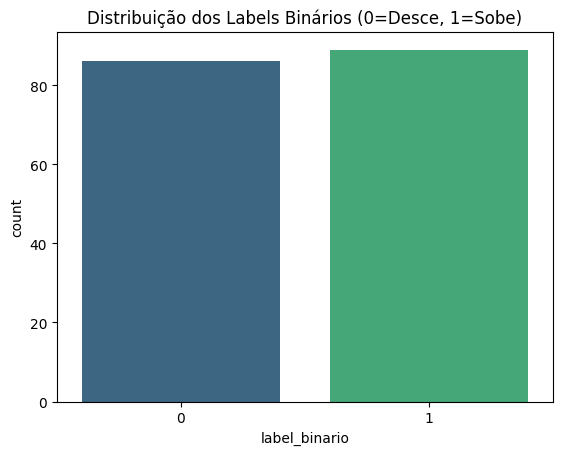


--- ETAPA 4: CALCULANDO TODAS AS FEATURES SEQUENCIAIS ---
Todas as features sequenciais foram calculadas.

--- ETAPA 5: ACHATANDO DADOS NA ORDEM HÍBRIDA ---
Achatamento e reordenação para o formato híbrido concluídos.

--- ETAPA 6: CRIANDO FEATURES CÍCLICAS E JUNTANDO TUDO ---
Junção final de todos os blocos de features e o novo label binário concluída.

--- ETAPA 7: SALVANDO E EXIBINDO O RESULTADO ---
Arquivo salvo como: 'dataset_binario.csv'
Dimensões do DataFrame final (dias, colunas): (96, 2170)
Total de dias válidos no dataset final: 96

Amostra do dataset final (início das colunas de contexto e início das sequenciais):


,range_dia_anterior,posicao_range_d1,distancia_mm20,mes_sin,mes_cos,dia_mes_sin,dia_mes_cos,dia_semana_sin,dia_semana_cos,mov_direcional_c1,...,ratio_vol_WIN_WDO_c172,ratio_vol_WIN_WDO_c173,ratio_vol_WIN_WDO_c174,ratio_vol_WIN_WDO_c175,ratio_vol_WIN_WDO_c176,ratio_vol_WIN_WDO_c177,ratio_vol_WIN_WDO_c178,ratio_vol_WIN_WDO_c179,ratio_vol_WIN_WDO_c180,label_binario
2025-07-09,0.009635,0.549451,0.009361,-0.5,-0.866025,0.968077,-0.250653,0.974928,-0.222521,-1,...,3.089530,2.308104,13.035229,3.965975,4.887721,2.732418,9.686635,7.122779,7.583997,1
2025-07-11,0.015438,0.634434,-0.014073,-0.5,-0.866025,0.790776,-0.612106,-0.433884,-0.900969,-1,...,1.975556,4.449416,4.980563,1.673171,3.031828,0.999290,2.320927,2.942431,4.183220,0
2025-07-14,0.009051,0.292000,-0.019089,-0.5,-0.866025,0.299363,-0.954139,0.000000,1.000000,1,...,13.696248,12.078219,15.490108,8.689551,4.060920,6.317691,4.501095,2.474897,1.774346,1
2025-07-16,0.013771,0.525199,-0.023074,-0.5,-0.866025,-0.101168,-0.994869,0.974928,-0.222521,-1,...,2.745947,4.324419,1.571682,2.245903,2.072679,3.130584,2.081298,5.931121,3.256431,1
2025-07-17,0.012844,0.390313,-0.025296,-0.5,-0.866025,-0.299363,-0.954139,0.433884,-0.900969,1,...,4.900681,7.485397,5.674209,18.713092,9.159676,7.422485,7.501607,3.234341,5.129781,0


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tenta usar a biblioteca TA-Lib se estiver instalada
try:
    import talib
    TALIB_INSTALLED = True
    print("Biblioteca TA-Lib encontrada.")
except ImportError:
    TALIB_INSTALLED = False
    print("Biblioteca TA-Lib não encontrada. Usando implementações alternativas.")

# --- CONFIGURAÇÕES ---
NOME_ARQUIVO_INDICE = 'WIN$N_M1_BRUTO.csv'
NOME_ARQUIVO_DOLAR = 'WDO$N_M1_BRUTO.csv'
NOME_ARQUIVO_SAIDA_FINAL = 'dataset_binario.csv' 

abertura_features = '9:00'
fechamento_features = '11:59'
abertura_labels = '12:00'
fechamento_labels = '12:59'
quantidade_velas = 180

# --- ETAPA 1: CARREGAMENTO E JUNÇÃO DOS DADOS BRUTOS ---
print("\n--- ETAPA 1: CARREGANDO E JUNTANDO DADOS DE ÍNDICE E DÓLAR ---")
def carregar_e_preparar_ativo(nome_arquivo, sufixo=''):
    df = pd.read_csv(nome_arquivo, sep=';', parse_dates=['datetime'], index_col='datetime')
    colunas_numericas = ['Abertura', 'Maxima', 'Minima', 'Fechamento', 'Volume_Real', 'Volume_Tick']
    for col in colunas_numericas:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df.dropna(subset=colunas_numericas, inplace=True)
    if sufixo:
        df = df.add_suffix(sufixo)
    return df

try:
    df_indice = carregar_e_preparar_ativo(NOME_ARQUIVO_INDICE)
    df_dolar = carregar_e_preparar_ativo(NOME_ARQUIVO_DOLAR, sufixo='_dolar')
    df_completo = df_indice.join(df_dolar, how='inner')
    print(f"Dados de Índice e Dólar carregados e juntados. Total de candles sincronizados: {len(df_completo)}")
except Exception as e:
    print(f"ERRO na ETAPA 1: {e}")
    exit()

# --- ETAPA 2: CÁLCULO DAS FEATURES DE CONTEXTO DIÁRIO  ---
print("\n--- ETAPA 2: CALCULANDO FEATURES DE CONTEXTO DIÁRIO ---")
def calcular_contexto_diario_completo(df, sufixo=''):
    cols = {
        'Abertura': f'Abertura{sufixo}', 'Maxima': f'Maxima{sufixo}',
        'Minima': f'Minima{sufixo}', 'Fechamento': f'Fechamento{sufixo}'
    }
    df_diario = df.resample('D').agg(
       Abertura=(cols['Abertura'], 'first'), Maxima=(cols['Maxima'], 'max'),
       Minima=(cols['Minima'], 'min'), Fechamento=(cols['Fechamento'], 'last')
    ).dropna()
    
    if sufixo:
        df_diario = df_diario.rename(columns={k: f"{k}{sufixo}" for k in ['Abertura', 'Maxima', 'Minima', 'Fechamento']})

    # ATR
    high_low = df_diario[f'Maxima{sufixo}'] - df_diario[f'Minima{sufixo}']
    high_close = np.abs(df_diario[f'Maxima{sufixo}'] - df_diario[f'Fechamento{sufixo}'].shift(1))
    low_close = np.abs(df_diario[f'Minima{sufixo}'] - df_diario[f'Fechamento{sufixo}'].shift(1))
    true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    df_diario[f'atr_dia_anterior{sufixo}'] = true_range.rolling(window=14, min_periods=1).mean().shift(1)
    
    # Outras features de contexto
    df_diario[f'range_dia_anterior{sufixo}'] = (df_diario[f'Maxima{sufixo}'].shift(1) - df_diario[f'Minima{sufixo}'].shift(1)) / df_diario[f'Abertura{sufixo}'].shift(1)
    df_diario[f'mm20_diaria{sufixo}'] = df_diario[f'Fechamento{sufixo}'].rolling(window=20).mean()
    df_diario[f'gap{sufixo}'] = (df_diario[f'Abertura{sufixo}'] - df_diario[f'Fechamento{sufixo}'].shift(1)) / df_diario[f'Fechamento{sufixo}'].shift(1)
    df_diario[f'posicao_range_d1{sufixo}'] = (df_diario[f'Abertura{sufixo}'] - df_diario[f'Minima{sufixo}'].shift(1)) / (df_diario[f'Maxima{sufixo}'].shift(1) - df_diario[f'Minima{sufixo}'].shift(1))
    df_diario[f'distancia_mm20{sufixo}'] = (df_diario[f'Abertura{sufixo}'] - df_diario[f'mm20_diaria{sufixo}'].shift(1)) / df_diario[f'mm20_diaria{sufixo}'].shift(1)
    
    df_diario.replace([np.inf, -np.inf], np.nan, inplace=True)
    return df_diario

df_contexto_win = calcular_contexto_diario_completo(df_completo)
df_contexto_dolar = calcular_contexto_diario_completo(df_completo, sufixo='_dolar')
df_contexto_geral = df_contexto_win.join(df_contexto_dolar, how='inner')

'''
features_contexto_diarias = [
    'gap', 'range_dia_anterior', 'atr_dia_anterior', 'posicao_range_d1', 'distancia_mm20',
    'gap_dolar', 'range_dia_anterior_dolar', 'atr_dia_anterior_dolar', 'posicao_range_d1_dolar', 'distancia_mm20_dolar'
]
'''
features_contexto_diarias = [
    'range_dia_anterior', 'posicao_range_d1', 'distancia_mm20'
]
df_contexto_geral.dropna(subset=features_contexto_diarias, inplace=True)
print("Features de contexto diário completas calculadas.")

# ==============================================================================
# --- ETAPA 3: GERAÇÃO DE LABELS (LÓGICA ATUALIZADA PARA CLASSIFICAÇÃO BINÁRIA) ---
# ==============================================================================
print("\n--- ETAPA 3: GERANDO LABELS BINÁRIOS (0 ou 1) ---")
# 1. Agrega os dados da janela de tempo do alvo para cada dia.
df_janela_alvo = df_completo.between_time(abertura_labels, fechamento_labels)
daily_agg_features = df_janela_alvo.resample('D').agg(
    Abertura_11h=('Abertura', 'first'), Fechamento_11h55=('Fechamento', 'last')
).dropna()

# 2. Calcula o retorno total no período.
daily_agg_features['retorno_total'] = daily_agg_features['Fechamento_11h55'] - daily_agg_features['Abertura_11h']

# 3. Cria o label binário usando np.where.
#    - Se retorno_total >= 0, o preço subiu ou ficou estável -> label = 1 (Sobe)
#    - Se retorno_total < 0, o preço desceu -> label = 0 (Desce)
daily_agg_features['label_binario'] = np.where(daily_agg_features['retorno_total'] >= 0, 1, 0)

print("Distribuição dos Label Binários:")
print(daily_agg_features['label_binario'].value_counts())
sns.countplot(data=daily_agg_features, x='label_binario', palette='viridis', hue='label_binario', legend=False).set_title('Distribuição dos Labels Binários (0=Desce, 1=Sobe)')
plt.show()

# --- ETAPA 4: CÁLCULO DAS FEATURES SEQUENCIAIS (COMPLETO) ---
print("\n--- ETAPA 4: CALCULANDO TODAS AS FEATURES SEQUENCIAIS ---")
df_completo.replace(0, 1e-9, inplace=True)
for suffix in ['', '_dolar']:
    df_completo[f'mag_decisao{suffix}'] = abs(df_completo[f'Fechamento{suffix}'] - df_completo[f'Abertura{suffix}']) / df_completo[f'Abertura{suffix}']
    df_completo[f'mov_direcional{suffix}'] = np.sign(df_completo[f'Fechamento{suffix}'] - df_completo[f'Abertura{suffix}'])
    df_completo[f'pavio_superior{suffix}'] = (df_completo[f'Maxima{suffix}'] - df_completo[[f'Abertura{suffix}', f'Fechamento{suffix}']].max(axis=1)) / df_completo[f'Abertura{suffix}']
    df_completo[f'pavio_inferior{suffix}'] = (df_completo[[f'Abertura{suffix}', f'Fechamento{suffix}']].min(axis=1) - df_completo[f'Minima{suffix}']) / df_completo[f'Abertura{suffix}']
    df_completo[f'range_candle{suffix}'] = (df_completo[f'Maxima{suffix}'] - df_completo[f'Minima{suffix}']) / df_completo[f'Abertura{suffix}']
    df_completo[f'volume_real_norm{suffix}'] = df_completo[f'Volume_Real{suffix}'] / df_completo[f'Volume_Real{suffix}'].rolling(window=50, min_periods=1).mean()
    df_completo[f'volume_tick_norm{suffix}'] = df_completo[f'Volume_Tick{suffix}'] / df_completo[f'Volume_Tick{suffix}'].rolling(window=50, min_periods=1).mean()
    df_completo[f'tamanho_medio_ordem{suffix}'] = df_completo[f'Volume_Real{suffix}'] / df_completo[f'Volume_Tick{suffix}']
    ma_3 = df_completo[f'Fechamento{suffix}'].rolling(window=3).mean()
    ma_9 = df_completo[f'Fechamento{suffix}'].rolling(window=9).mean()
    df_completo[f'diferenca_MA{suffix}'] = (ma_3 - ma_9) / df_completo[f'Fechamento{suffix}']
    if TALIB_INSTALLED:
        df_completo[f'RSI{suffix}'] = talib.RSI(df_completo[f'Fechamento{suffix}'], timeperiod=14)
        macd, macdsignal, _ = talib.MACD(df_completo[f'Fechamento{suffix}'], fastperiod=12, slowperiod=26, signalperiod=9)
        df_completo[f'MACD{suffix}'] = macd - macdsignal
    else:
        delta = df_completo[f'Fechamento{suffix}'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        df_completo[f'RSI{suffix}'] = 100 - (100 / (1 + rs))
        ema_fast = df_completo[f'Fechamento{suffix}'].ewm(span=12, adjust=False).mean()
        ema_slow = df_completo[f'Fechamento{suffix}'].ewm(span=26, adjust=False).mean()
        macd_line = ema_fast - ema_slow
        signal_line = macd_line.ewm(span=9, adjust=False).mean()
        df_completo[f'MACD{suffix}'] = macd_line - signal_line
df_completo['correlacao_movel_WIN_WDO'] = df_completo['Fechamento'].rolling(window=24, min_periods=10).corr(df_completo['Fechamento_dolar'])
df_completo['ratio_vol_WIN_WDO'] = df_completo['Volume_Real'] / df_completo['Volume_Real_dolar']
df_completo.dropna(inplace=True)
print("Todas as features sequenciais foram calculadas.")

# --- ETAPA 5: ACHATAMENTO E REORDENAÇÃO HÍBRIDA ---
print("\n--- ETAPA 5: ACHATANDO DADOS NA ORDEM HÍBRIDA ---")
'''
features_sequenciais_nomes = [
    'mag_decisao', 'mov_direcional', 'pavio_superior', 'pavio_inferior', 'range_candle',
    'volume_real_norm', 'volume_tick_norm', 'tamanho_medio_ordem', 'diferenca_MA', 'RSI', 'MACD',
    'mag_decisao_dolar', 'mov_direcional_dolar', 'pavio_superior_dolar', 'pavio_inferior_dolar', 'range_candle_dolar',
    'volume_real_norm_dolar', 'volume_tick_norm_dolar', 'tamanho_medio_ordem_dolar', 'diferenca_MA_dolar', 'RSI_dolar', 'MACD_dolar',
    'correlacao_movel_WIN_WDO', 'ratio_vol_WIN_WDO'
]
'''
features_sequenciais_nomes = [
    'mov_direcional', 'pavio_superior', 'pavio_inferior', 'range_candle', 'tamanho_medio_ordem',
    'pavio_superior_dolar', 'pavio_inferior_dolar', 'range_candle_dolar',
    'volume_real_norm_dolar', 'tamanho_medio_ordem_dolar', 'correlacao_movel_WIN_WDO', 'ratio_vol_WIN_WDO'
]


df_janela_entrada = df_completo.between_time(abertura_features, fechamento_features).copy()
dias_com_24_candles = df_janela_entrada.index.normalize().value_counts()
dias_validos_counts = dias_com_24_candles[dias_com_24_candles == quantidade_velas].index
dias_finais = sorted(list(set(dias_validos_counts) & set(df_contexto_geral.index) & set(daily_agg_features.index)))
df_janela_filtrada = df_janela_entrada[df_janela_entrada.index.normalize().isin(dias_finais)]
grouped_by_day = df_janela_filtrada.groupby(df_janela_filtrada.index.normalize())
colunas_hibridas = [f'{feature}_c{i}' for feature in features_sequenciais_nomes for i in range(1, quantidade_velas+1)]
lista_dfs_achatados = []
dias_ordenados = sorted(grouped_by_day.groups.keys())
for feature in features_sequenciais_nomes:
    dados_feature = [group[feature].values for day, group in grouped_by_day]
    df_feature_achatada = pd.DataFrame(dados_feature, index=dias_ordenados)
    lista_dfs_achatados.append(df_feature_achatada)
df_features_sequenciais = pd.concat(lista_dfs_achatados, axis=1)
df_features_sequenciais.columns = colunas_hibridas
print("Achatamento e reordenação para o formato híbrido concluídos.")

# --- ETAPA 6: FEATURES CÍCLICAS (COMPLETO) E JUNÇÃO FINAL ---
print("\n--- ETAPA 6: CRIANDO FEATURES CÍCLICAS E JUNTANDO TUDO ---")
df_tempo = pd.DataFrame(index=pd.to_datetime(dias_finais))
df_tempo['mes_sin'] = np.sin(2 * np.pi * df_tempo.index.month / 12)
df_tempo['mes_cos'] = np.cos(2 * np.pi * df_tempo.index.month / 12)
dias_no_mes = df_tempo.index.days_in_month
df_tempo['dia_mes_sin'] = np.sin(2 * np.pi * df_tempo.index.day / dias_no_mes)
df_tempo['dia_mes_cos'] = np.cos(2 * np.pi * df_tempo.index.day / dias_no_mes)
df_tempo['dia_semana_sin'] = np.sin(2 * np.pi * df_tempo.index.dayofweek / 7)
df_tempo['dia_semana_cos'] = np.cos(2 * np.pi * df_tempo.index.dayofweek / 7)
features_ciclicas = df_tempo[['mes_sin', 'mes_cos', 'dia_mes_sin', 'dia_mes_cos', 'dia_semana_sin', 'dia_semana_cos']]
df_todas_contexto = df_contexto_geral[features_contexto_diarias].join(features_ciclicas, how='inner')
df_todas_as_features = df_todas_contexto.join(df_features_sequenciais, how='inner')

# ATUALIZAÇÃO: Junta o novo label binário. Não usamos mais one-hot encoding.
df_dataset_final = df_todas_as_features.join(daily_agg_features[['label_binario']], how='inner')
print("Junção final de todos os blocos de features e o novo label binário concluída.")


# --- ETAPA 7: SALVAR E EXIBIR O DATASET FINAL ---
print(f"\n--- ETAPA 7: SALVANDO E EXIBINDO O RESULTADO ---")
df_dataset_final.to_csv(NOME_ARQUIVO_SAIDA_FINAL, sep=';')
print(f"Arquivo salvo como: '{NOME_ARQUIVO_SAIDA_FINAL}'")
print(f"Dimensões do DataFrame final (dias, colunas): {df_dataset_final.shape}")
print(f"Total de dias válidos no dataset final: {len(df_dataset_final)}")
pd.set_option('display.max_columns', 20)
print("\nAmostra do dataset final (início das colunas de contexto e início das sequenciais):")
display(df_dataset_final.head())
pd.reset_option('display.max_columns')


# Treinando o modelo cnn + lstm
1.  **Carregamento de Dados:** Vamos carregar o `dataset_binario.csv` que criamos anteriormente, que já contém a coluna `label_binario` com `0`s e `1`s.
2.  **Preparação do Alvo (Y):** O `y` agora será um vetor simples com os labels `0` e `1`, em vez de uma matriz one-hot-encoded.
3.  **Função `create_model`:** A alteração mais importante.
    *   A **camada de saída** terá `Dense(1, activation='sigmoid')`.
    *   O modelo será compilado com `loss='binary_crossentropy'`.
4.  **Validação Cruzada e Avaliação Final:** A lógica de `np.argmax` não será mais necessária, pois os labels já estão no formato correto.

O resultado será um script que usa o Optuna para encontrar a melhor arquitetura CNN-LSTM para prever se o preço vai subir ou não.

## Resumo do que o Código Faz
Este é um script completo e robusto para **encontrar a melhor arquitetura de um modelo híbrido CNN-LSTM e avaliá-la de forma justa** para um problema de **classificação binária** (prever se o preço vai subir ou descer).

O fluxo de trabalho é o seguinte:

1.  **Preparação de Dados para Múltiplas Entradas:**
    *   O código carrega um dataset com um label binário (0 para "Desce", 1 para "Sobe").
    *   Ele reconstrói as features "achatadas" em duas entradas distintas para o modelo:
        *   `X_seq`: Um tensor 3D com os dados sequenciais (indicadores de cada vela), destinado às camadas CNN e LSTM.
        *   `X_context`: Um tensor 2D com os dados de contexto (indicadores diários, etc.), destinado a uma camada Densa.

2.  **Divisão Cronológica em Dois Níveis (Metodologia Correta):**
    *   **Nível 1 (Divisão Estratégica):** O dataset é dividido cronologicamente (`shuffle=False`) em um grande conjunto de **Treino/Validação (80%)** e um conjunto de **Teste Final (20%)**. O conjunto de teste é "trancado" e não é usado até a avaliação final, garantindo uma avaliação imparcial.
    *   **Nível 2 (Validação Cruzada Cronológica):** Dentro da otimização do Optuna, o conjunto de Treino/Validação é repetidamente dividido em 5 "folds" usando `TimeSeriesSplit`. Isso garante que o modelo seja sempre treinado com dados do passado para prever o futuro, fornecendo uma avaliação robusta e realista para cada `trial`.

3.  **Otimização Inteligente com Optuna (Métrica Robusta):**
    *   O Optuna testa várias combinações (`n_trials`) de arquiteturas de CNN-LSTM.
    *   Para cada teste, ele varia a estrutura completa da rede: número de camadas, neurônios, dropout, regularização L1/L2, etc.
    *   **Ponto Chave:** A métrica que o Optuna tenta maximizar é o **Macro Average F1-Score**. Esta é a escolha ideal, pois avalia o equilíbrio da performance do modelo entre as classes "Sobe" e "Desce", sendo muito mais confiável que a acurácia, especialmente se houver algum desbalanceamento.

4.  **Treinamento e Avaliação Final:**
    *   Após o Optuna eleger a melhor combinação de hiperparâmetros (aquela com o maior F1-Score médio), um novo modelo é construído com essa arquitetura.
    *   Este modelo final é treinado no conjunto de **Treino/Validação original (os 80% completos)** para aprender com o máximo de dados possível.
    *   Finalmente, o modelo treinado é avaliado **uma única vez** no conjunto de **Teste Final (os 20% intocados)**. Os resultados (Acurácia, F1-Score, Relatório de Classificação e Matriz de Confusão) representam uma estimativa honesta de como o modelo se comportaria em dados novos.

5.  **Visualização:**
    *   Ao final, são exibidos gráficos do Optuna que mostram o histórico da otimização e a importância de cada hiperparâmetro, permitindo entender quais decisões de arquitetura mais impactaram o resultado

2026-03-18 14:43:18.167615: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-18 14:43:18.168688: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-18 14:43:18.389844: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-18 14:43:19.443832: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

--- ETAPA 1: Carregando e preparando os dados para Classificação Binária ---
Formato dos dados de Contexto (X_context): (96, 9)
Formato dos dados Sequenciais (X_seq): (96, 180, 12)
Divisão de dados concluída.

--- ETAPA 3: Definindo a função objective para Classificação Binária ---

--- ETAPA 4: Executando a otimização com Optuna ---


2026-03-18 14:43:20.165496: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


[I 2026-03-18 14:49:57,873] Trial 0 finished with value: 0.5977518095939148 and parameters: {'learning_rate': 4.967551405619162e-05, 'optimizer': 'RMSprop', 'n_conv_layers': 2, 'n_lstm_layers': 1, 'n_dense_layers': 3, 'context_dense_units': 134, 'l1_strength': 0.00013242120261760702, 'l2_strength': 0.005204124895643699, 'conv_0_filters': 111, 'conv_0_kernel_size': 1, 'conv_0_padding': 'causal', 'conv_0_pool_size': 2, 'use_conv_0_dropout': False, 'conv_1_filters': 44, 'conv_1_kernel_size': 4, 'conv_1_padding': 'causal', 'conv_1_pool_size': 1, 'use_conv_1_dropout': True, 'conv_1_dropout_rate': 0.4739278545908361, 'lstm_0_units': 249, 'use_lstm_0_dropout': False, 'dense_0_units': 182, 'use_dense_0_dropout': False, 'dense_1_units': 67, 'use_dense_1_dropout': True, 'dense_1_dropout_rate': 0.259612203777136, 'dense_2_units': 38, 'use_dense_2_dropout': True, 'dense_2_dropout_rate': 0.10503048066713948, 'batch_size': 64}. Best is trial 0 with value: 0.5977518095939148.


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


[I 2026-03-18 16:31:00,153] Trial 18 finished with value: 0.40519140989729224 and parameters: {'learning_rate': 0.0010695908773441672, 'optimizer': 'RMSprop', 'n_conv_layers': 1, 'n_lstm_layers': 1, 'n_dense_layers': 3, 'context_dense_units': 38, 'l1_strength': 0.00405170936285191, 'l2_strength': 0.00018570768676551015, 'conv_0_filters': 153, 'conv_0_kernel_size': 2, 'conv_0_padding': 'same', 'conv_0_pool_size': 3, 'use_conv_0_dropout': False, 'lstm_0_units': 60, 'use_lstm_0_dropout': False, 'dense_0_units': 319, 'use_dense_0_dropout': True, 'dense_0_dropout_rate': 0.3803648406990965, 'dense_1_units': 48, 'use_dense_1_dropout': False, 'dense_2_units': 172, 'use_dense_2_dropout': False, 'batch_size': 64}. Best is trial 10 with value: 0.6227505827505827.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


[I 2026-03-18 16:34:09,735] Trial 19 finished with value: 0.5502902652902653 and parameters: {'learning_rate': 0.00016540957296184785, 'optimizer': 'RMSprop', 'n_conv_layers': 2, 'n_lstm_layers': 2, 'n_dense_layers': 3, 'context_dense_units': 86, 'l1_strength': 0.00037170733557858866, 'l2_strength': 3.107213936156743e-07, 'conv_0_filters': 68, 'conv_0_kernel_size': 4, 'conv_0_padding': 'causal', 'conv_0_pool_size': 3, 'use_conv_0_dropout': False, 'conv_1_filters': 297, 'conv_1_kernel_size': 2, 'conv_1_padding': 'causal', 'conv_1_pool_size': 1, 'use_conv_1_dropout': True, 'conv_1_dropout_rate': 0.1108957044644922, 'lstm_0_units': 35, 'use_lstm_0_dropout': False, 'lstm_1_units': 116, 'use_lstm_1_dropout': True, 'lstm_1_dropout_rate': 0.23422509550193038, 'dense_0_units': 238, 'use_dense_0_dropout': False, 'dense_1_units': 173, 'use_dense_1_dropout': True, 'dense_1_dropout_rate': 0.4209212365549109, 'dense_2_units': 128, 'use_dense_2_dropout': False, 'batch_size': 16}. Best is trial 10 wi


--- ETAPA 5: Gerando gráficos de análise da otimização ---
Melhor Acurácia Média na Validação Cruzada: 0.6228
Melhores Hiperparâmetros: {'learning_rate': 0.00011843179704984526, 'optimizer': 'RMSprop', 'n_conv_layers': 3, 'n_lstm_layers': 2, 'n_dense_layers': 3, 'context_dense_units': 280, 'l1_strength': 0.008088561127590299, 'l2_strength': 2.5933048451443196e-08, 'conv_0_filters': 285, 'conv_0_kernel_size': 2, 'conv_0_padding': 'same', 'conv_0_pool_size': 3, 'use_conv_0_dropout': False, 'conv_1_filters': 45, 'conv_1_kernel_size': 4, 'conv_1_padding': 'causal', 'conv_1_pool_size': 3, 'use_conv_1_dropout': True, 'conv_1_dropout_rate': 0.6531489997387041, 'conv_2_filters': 324, 'conv_2_kernel_size': 5, 'conv_2_padding': 'causal', 'conv_2_pool_size': 2, 'use_conv_2_dropout': False, 'lstm_0_units': 88, 'use_lstm_0_dropout': False, 'lstm_1_units': 334, 'use_lstm_1_dropout': True, 'lstm_1_dropout_rate': 0.2868072569742883, 'dense_0_units': 344, 'use_dense_0_dropout': False, 'dense_1_units':

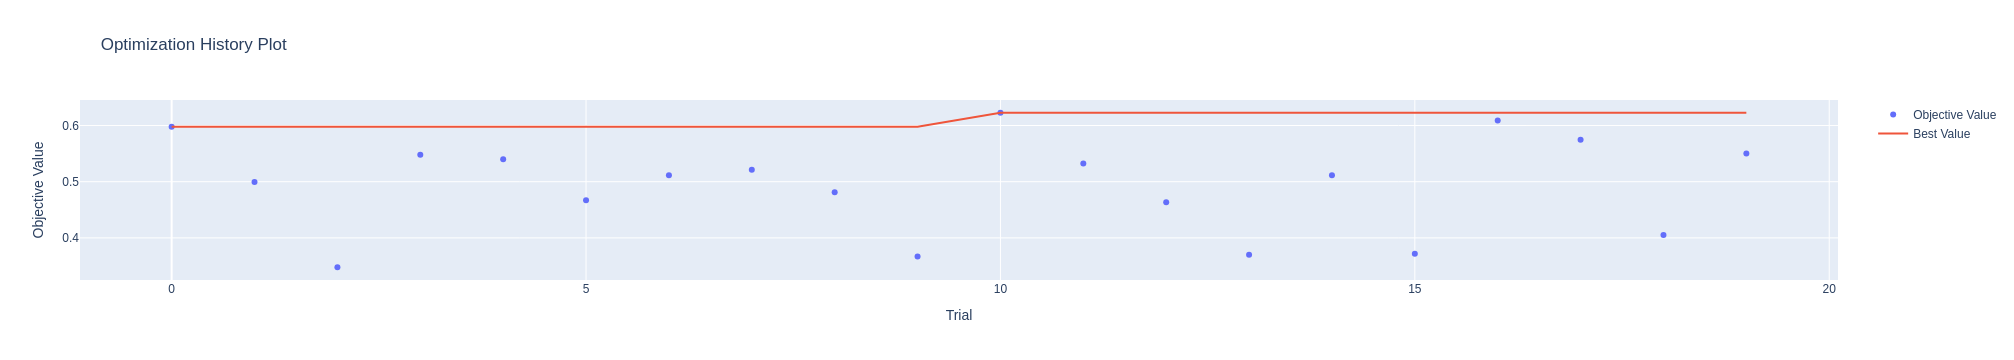

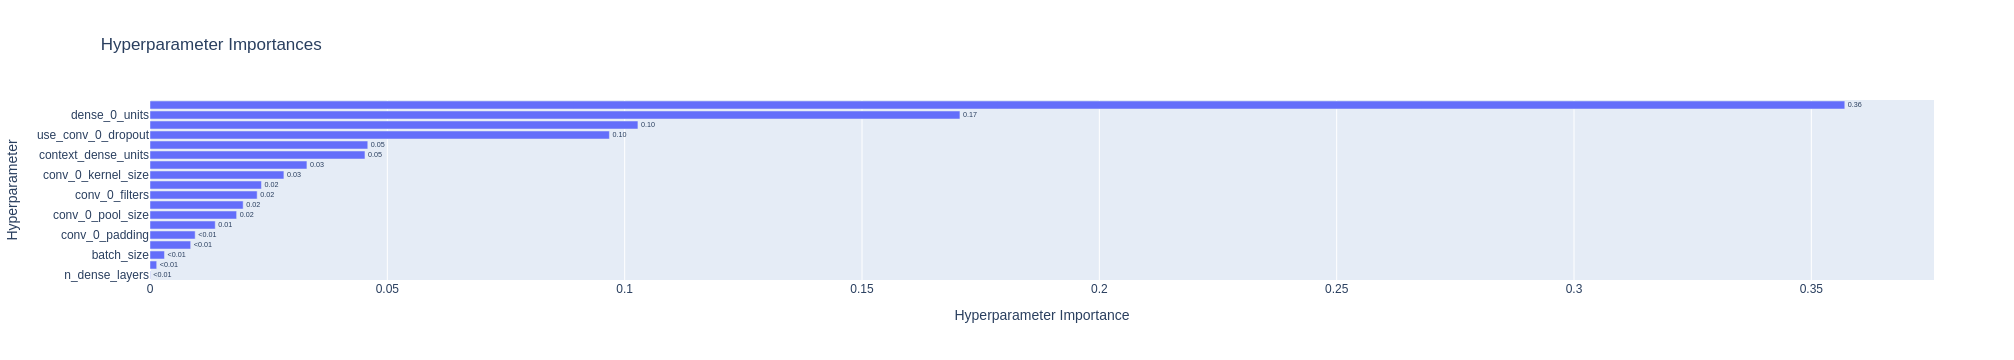

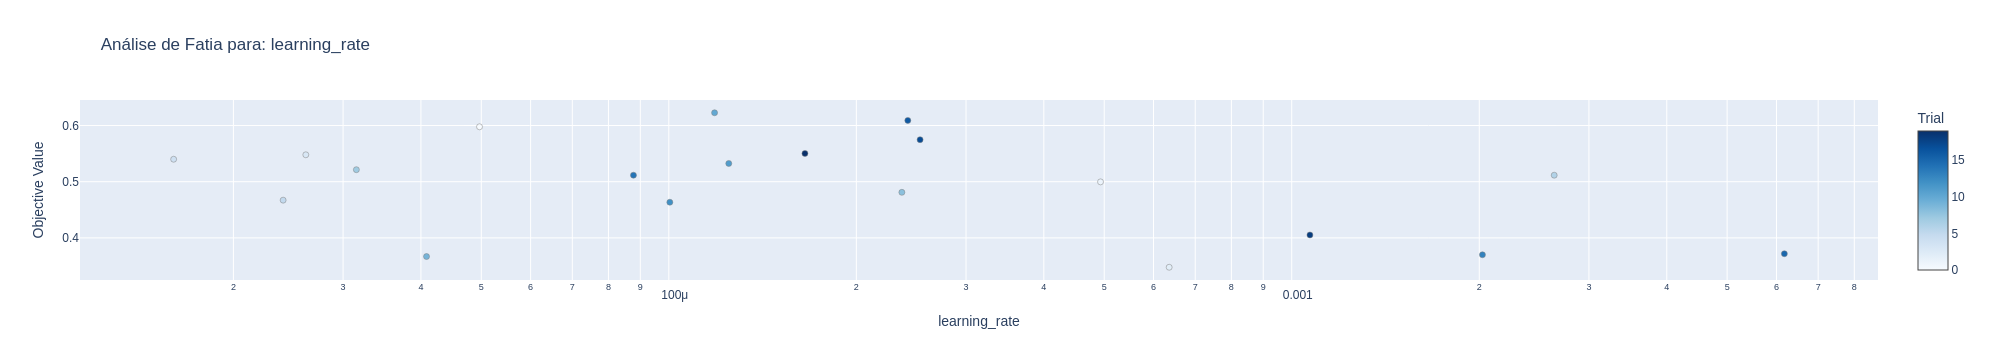

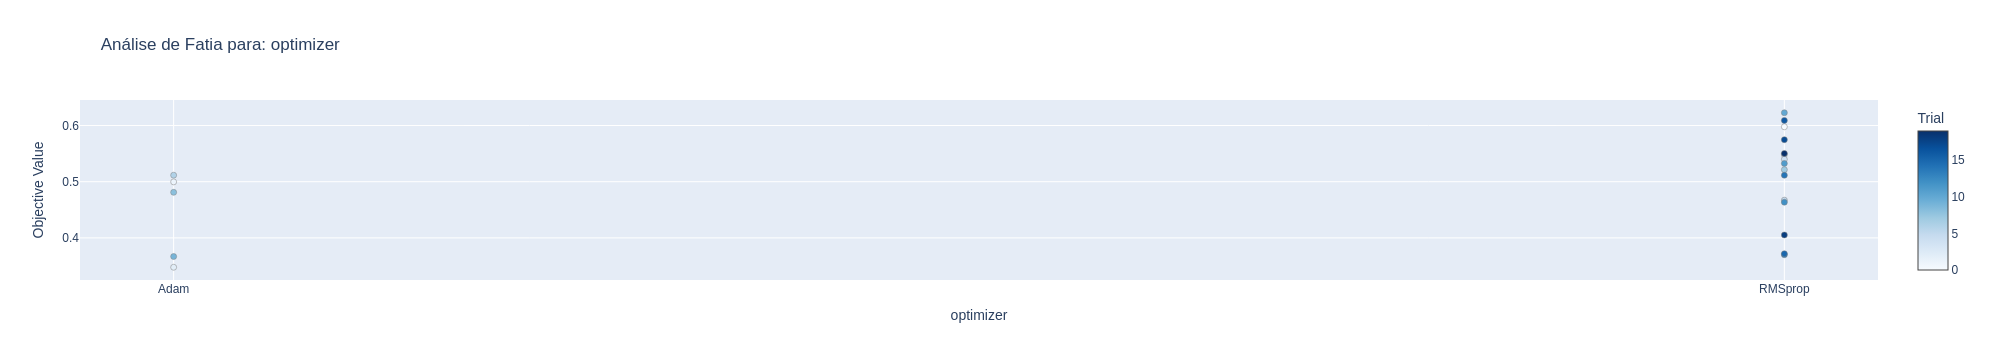

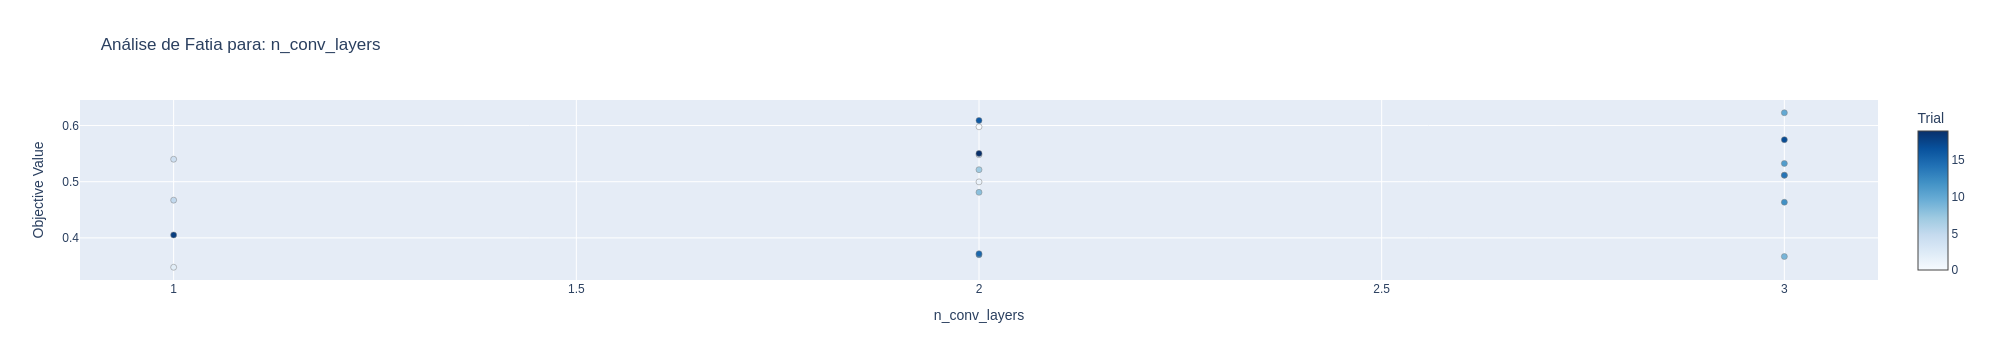

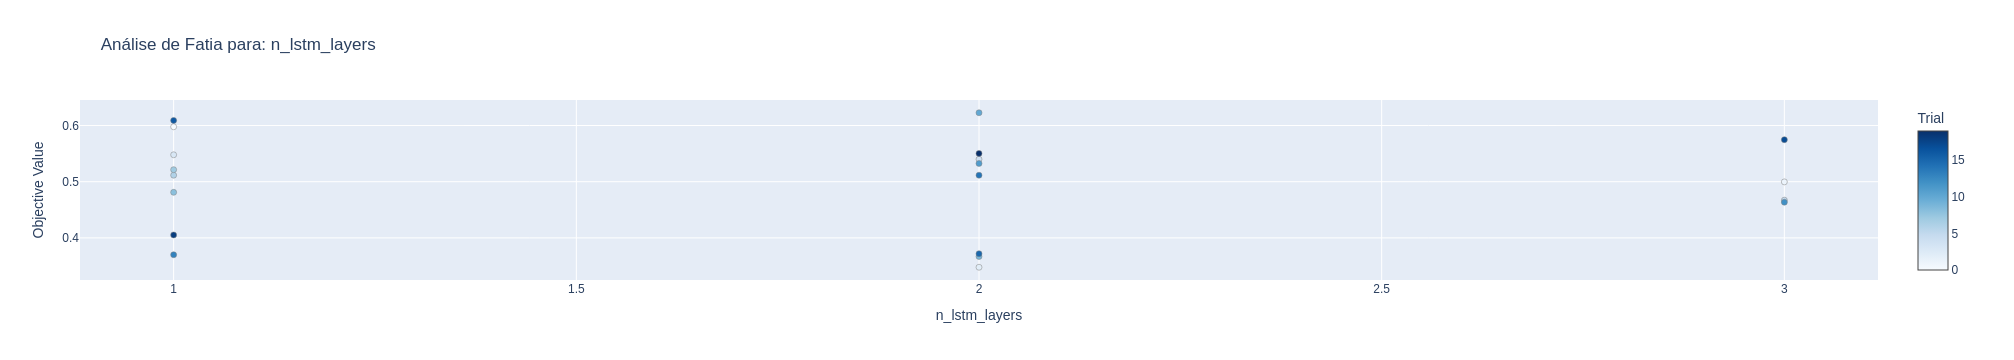

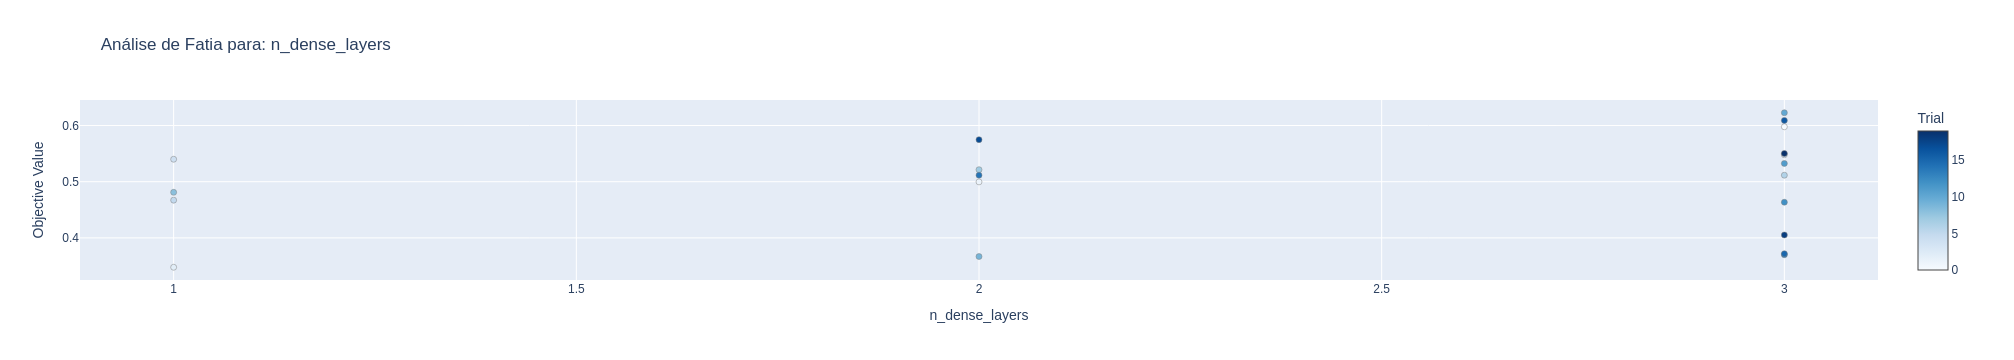

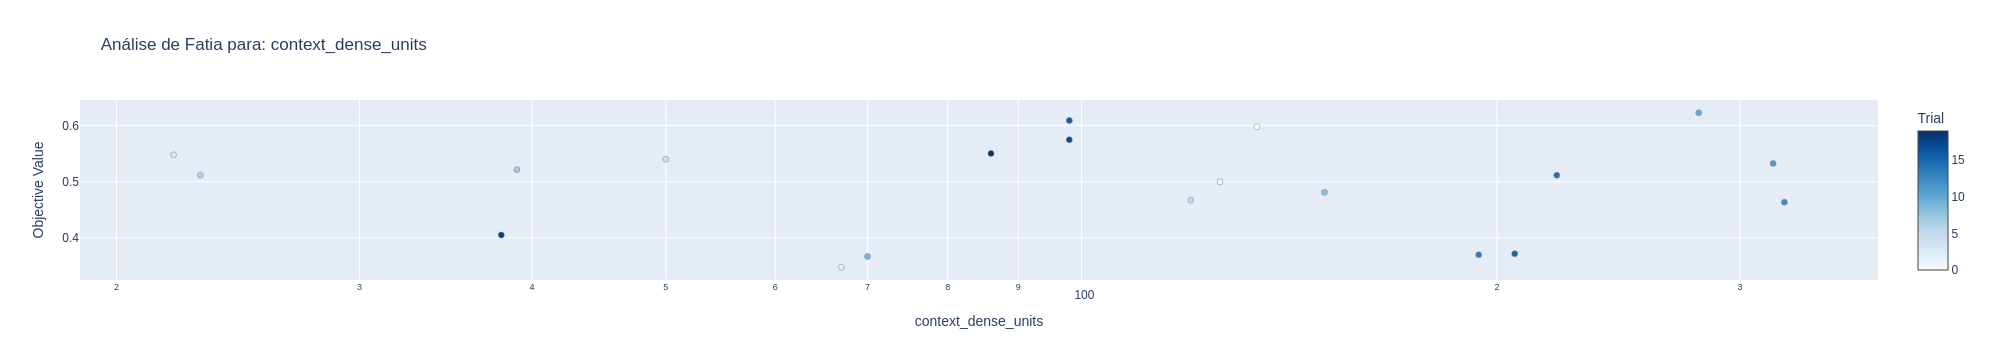

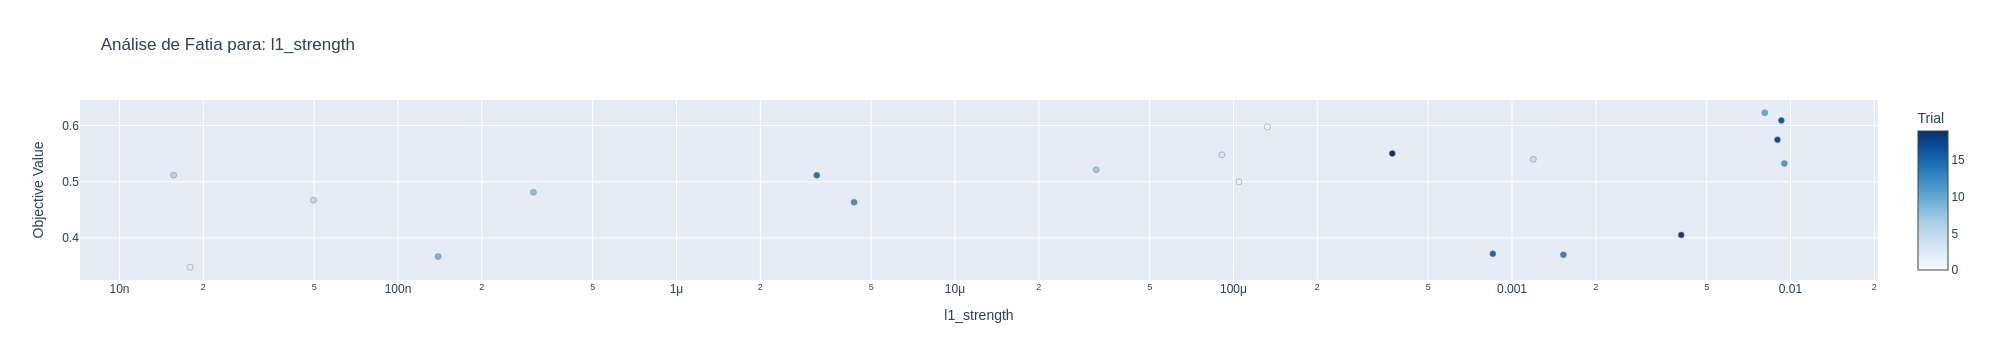

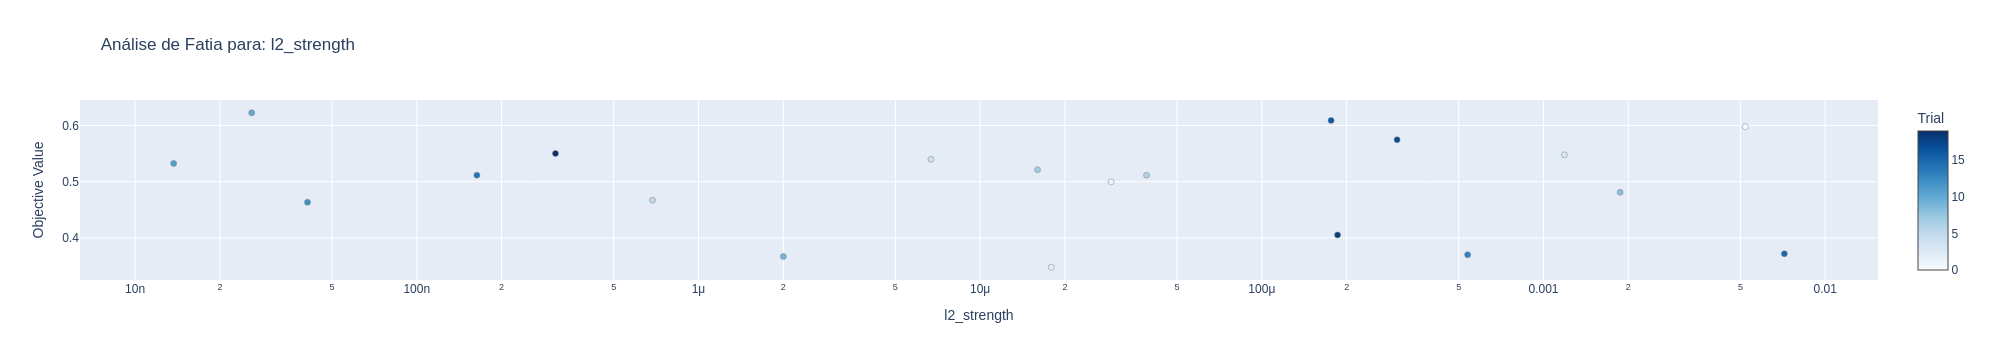

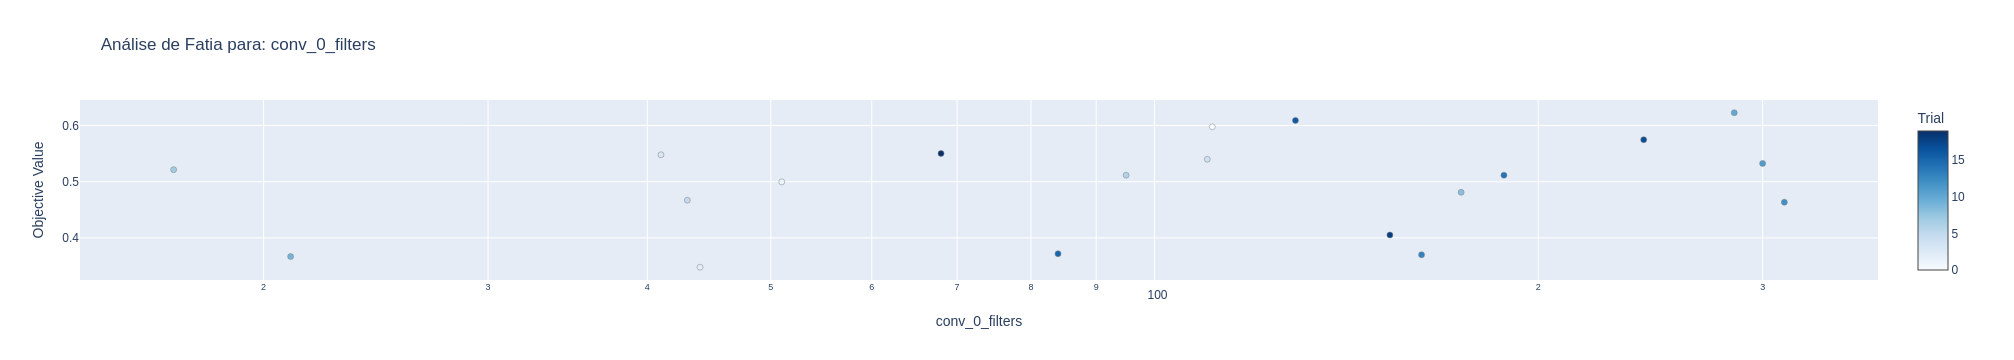

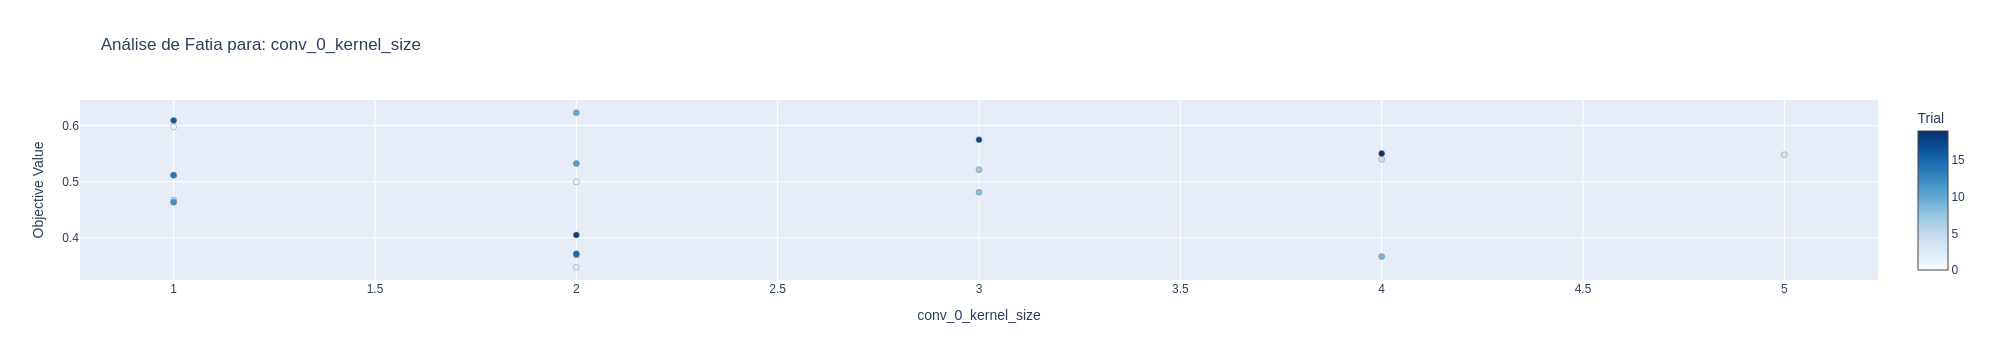

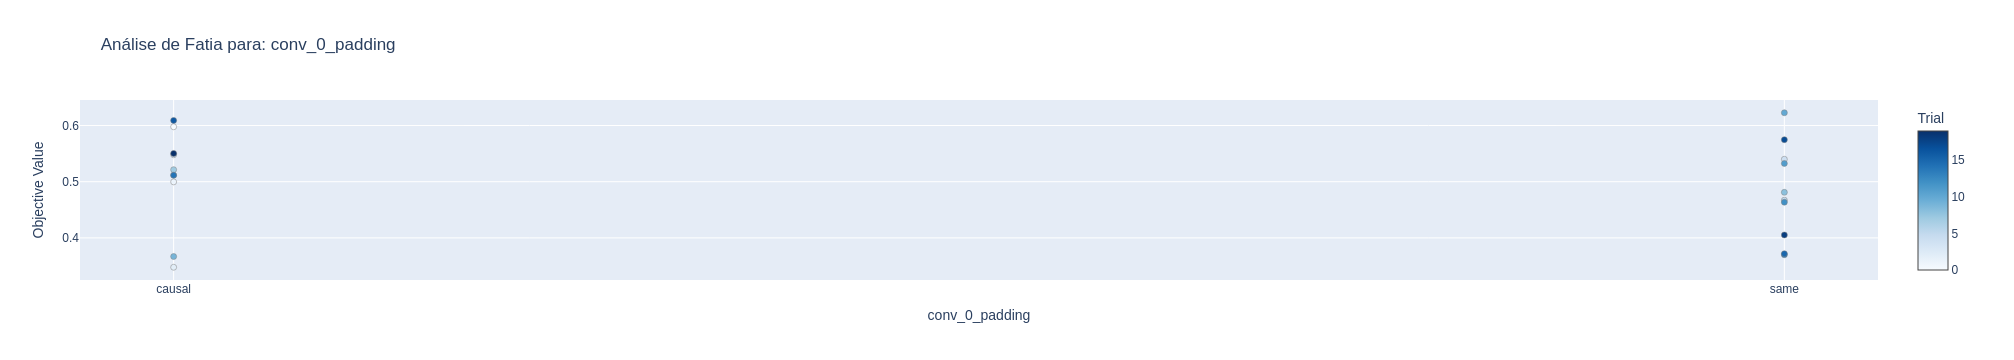

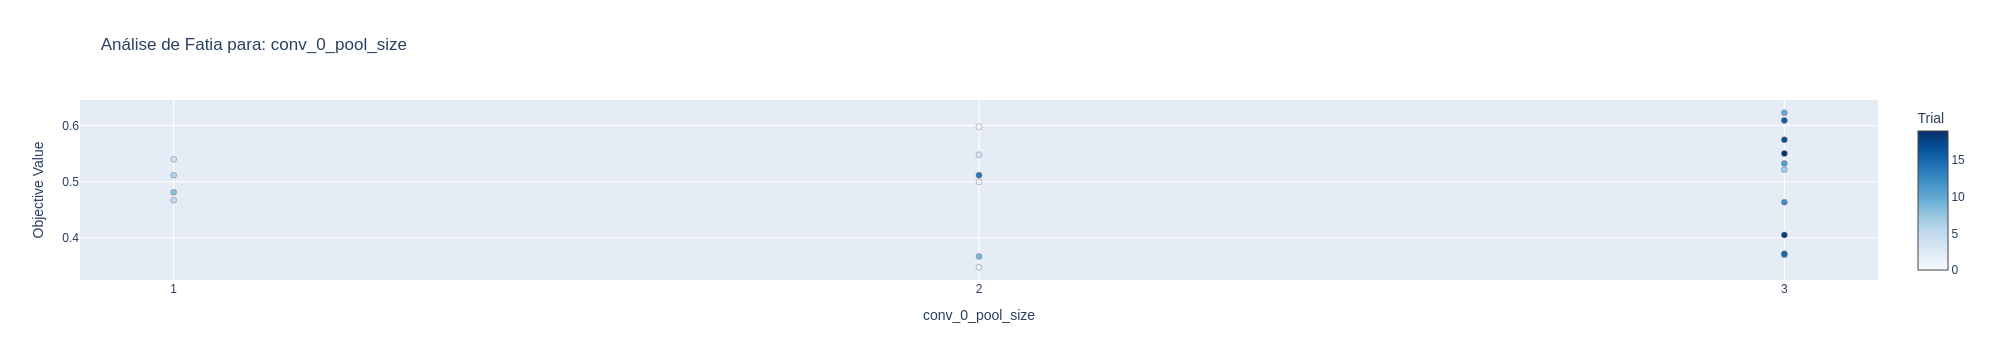

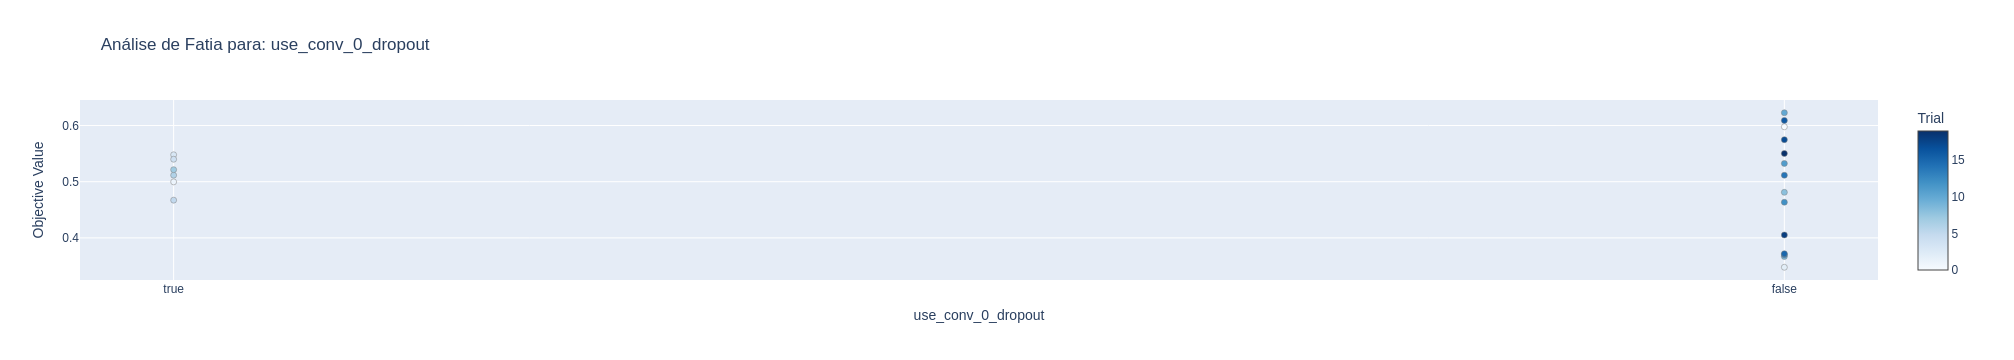

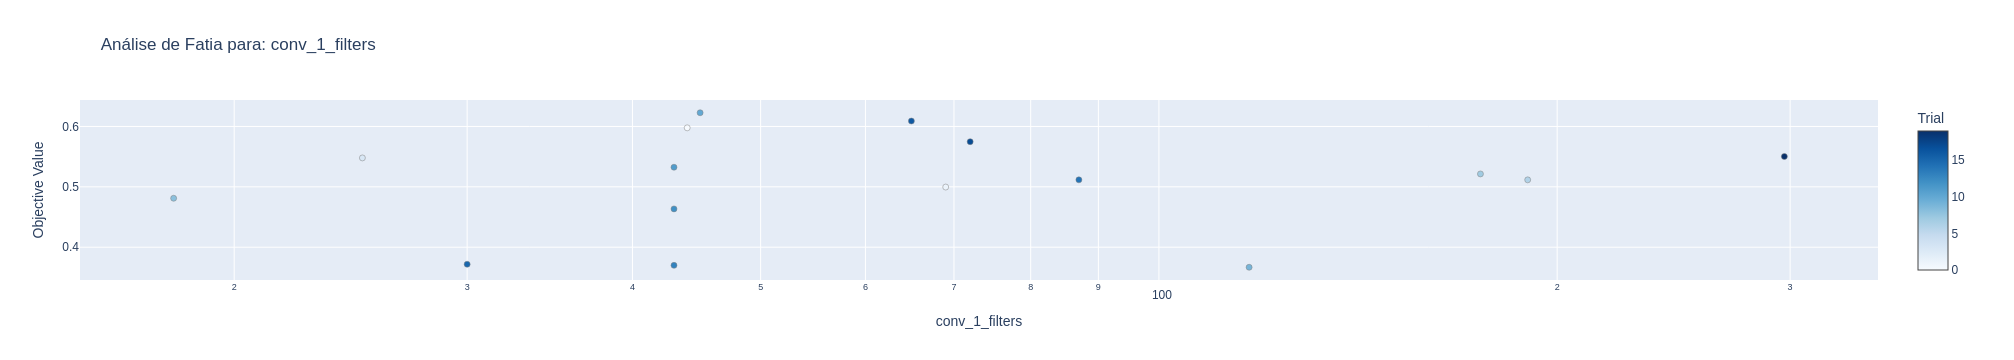

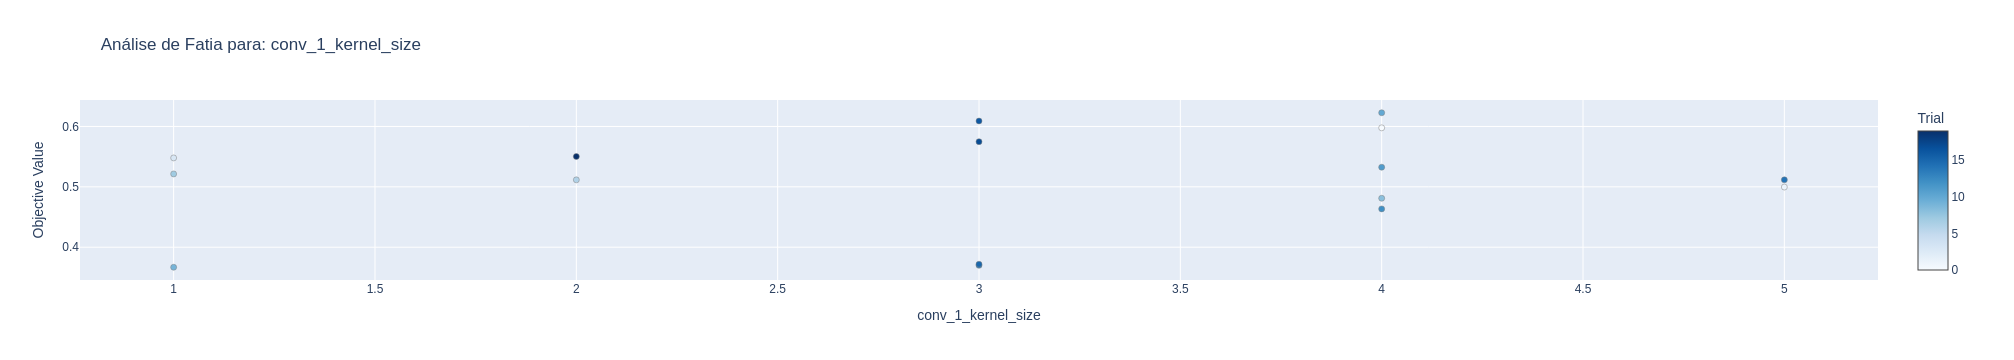

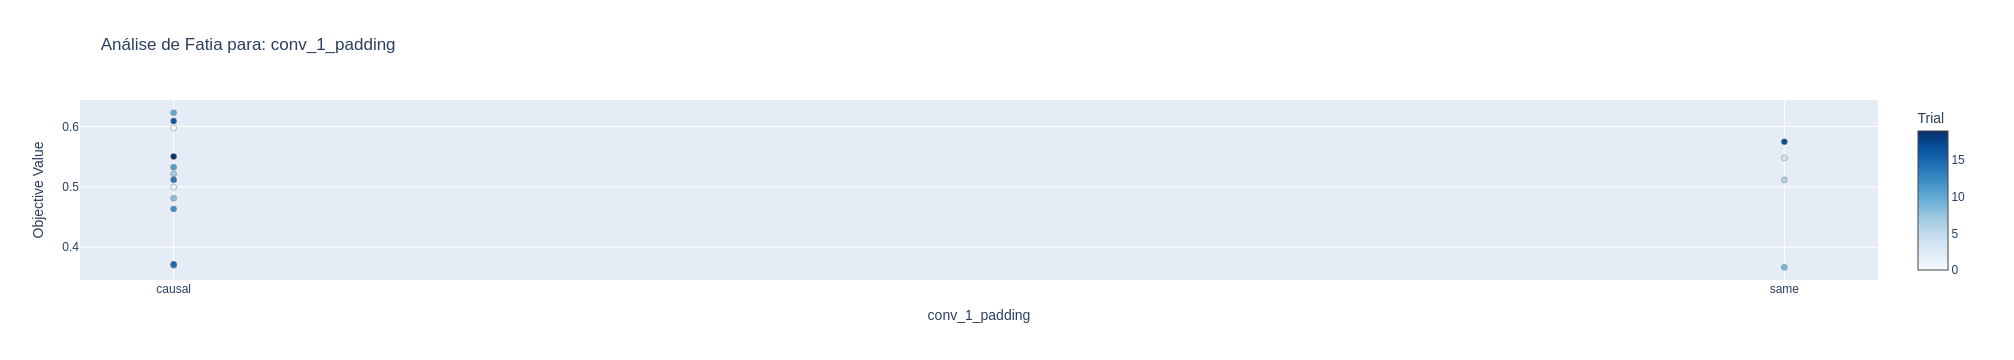

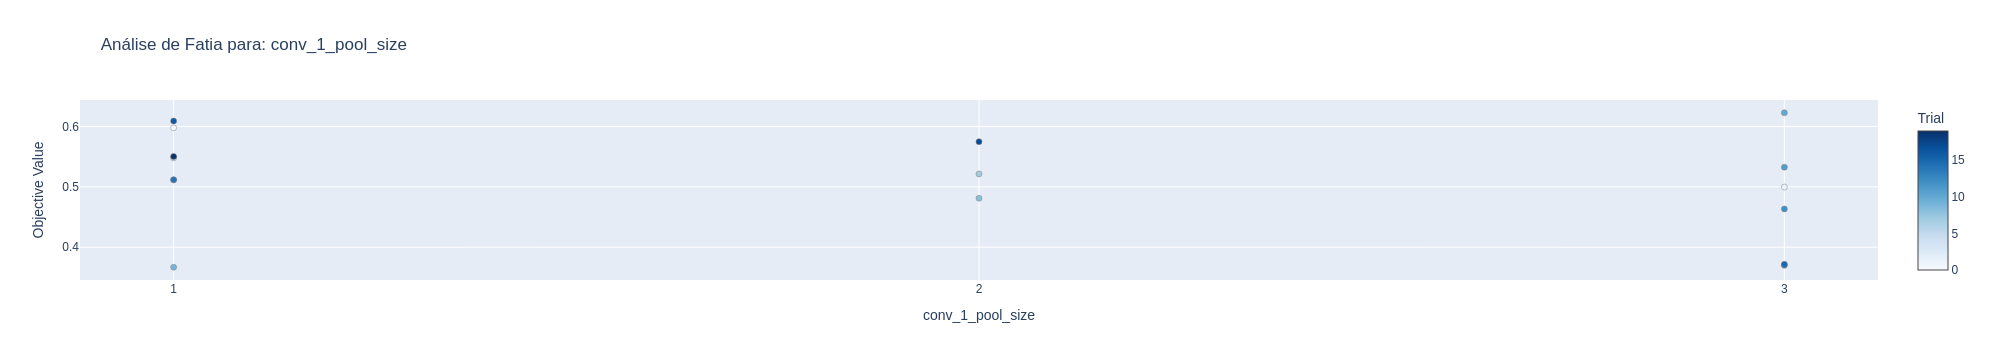

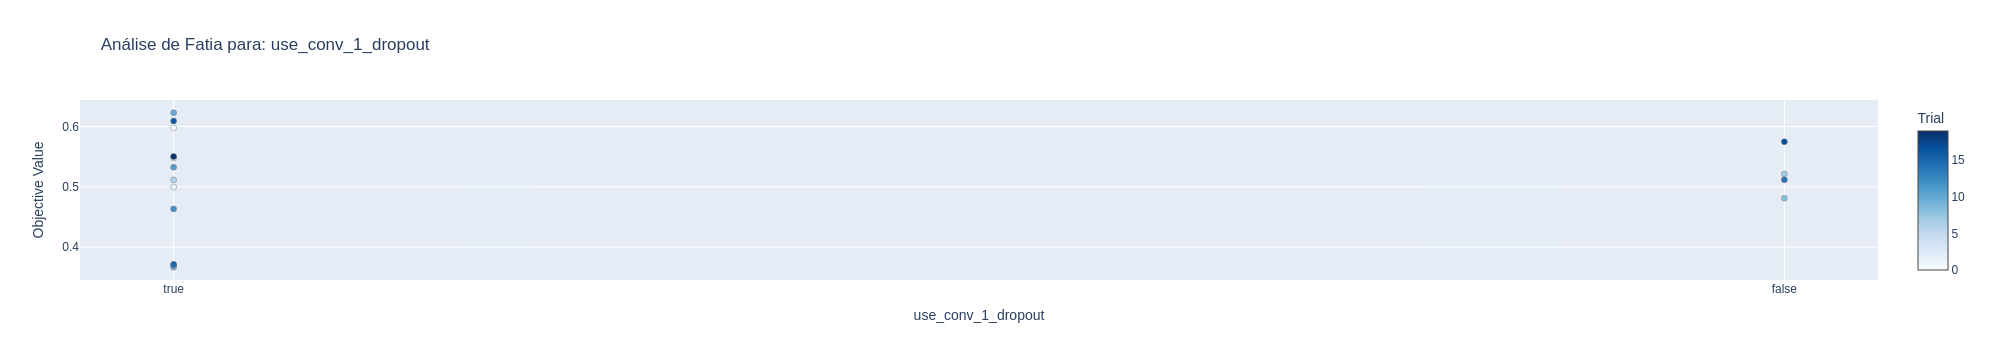

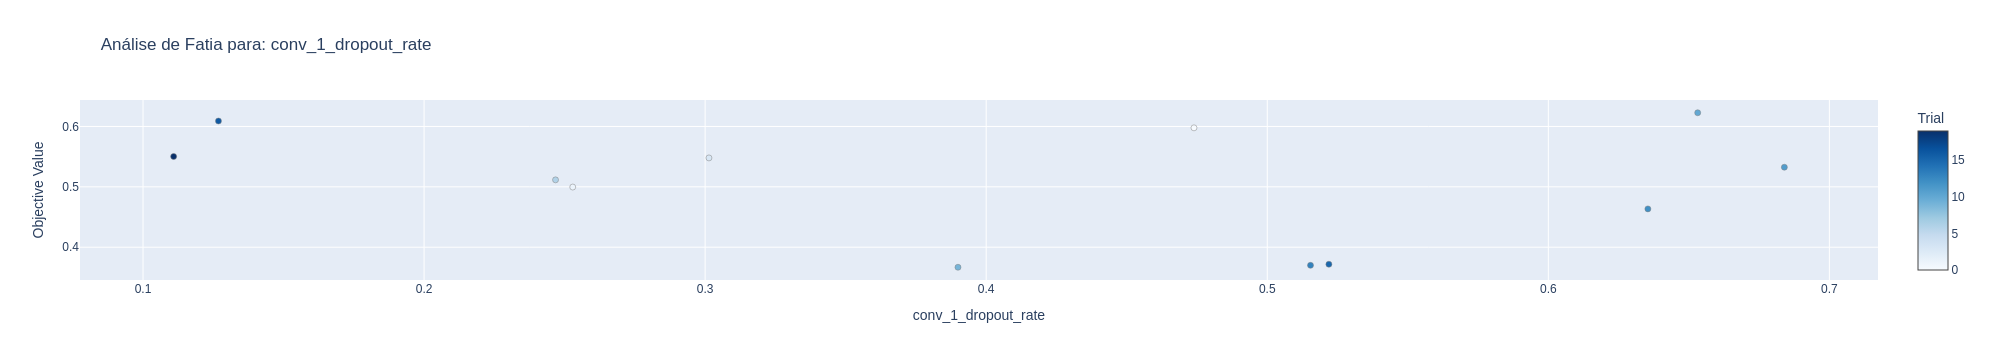

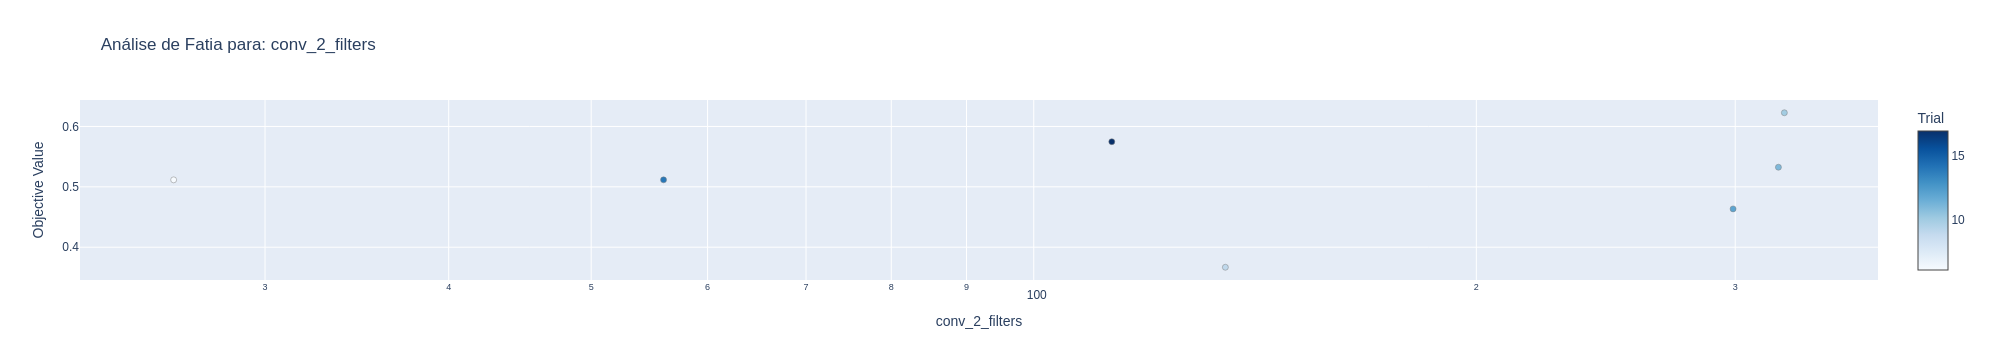

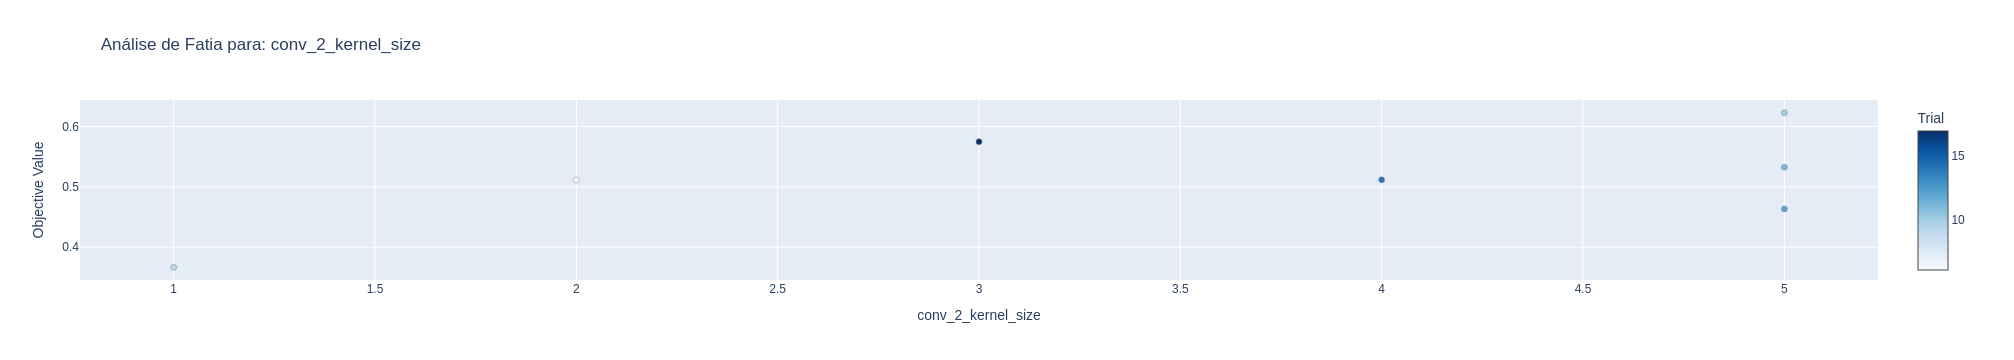

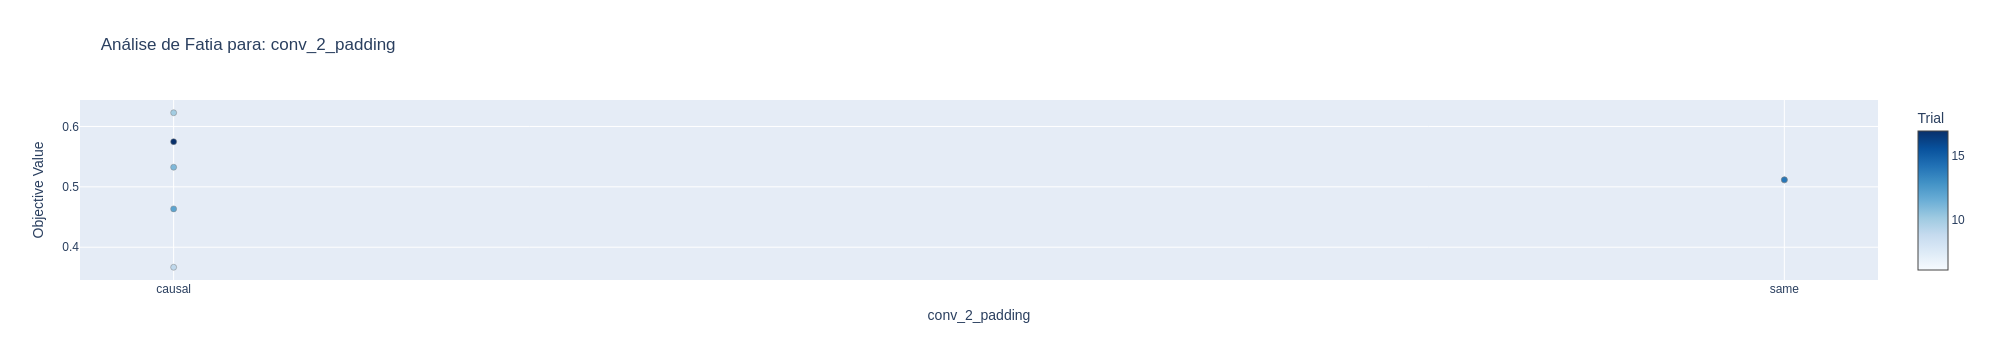

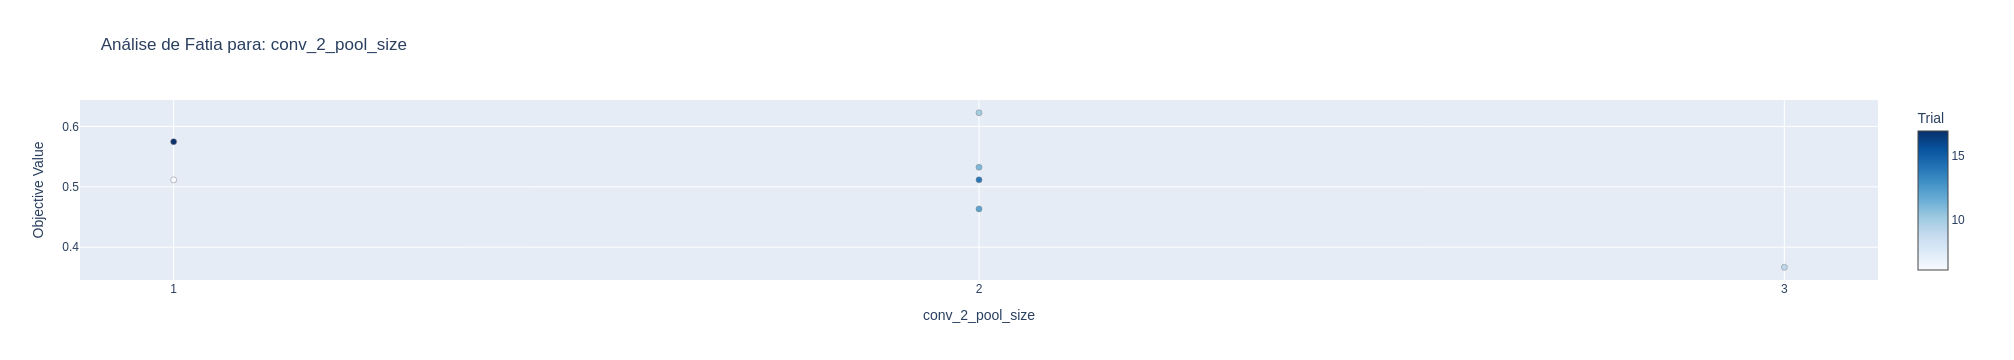

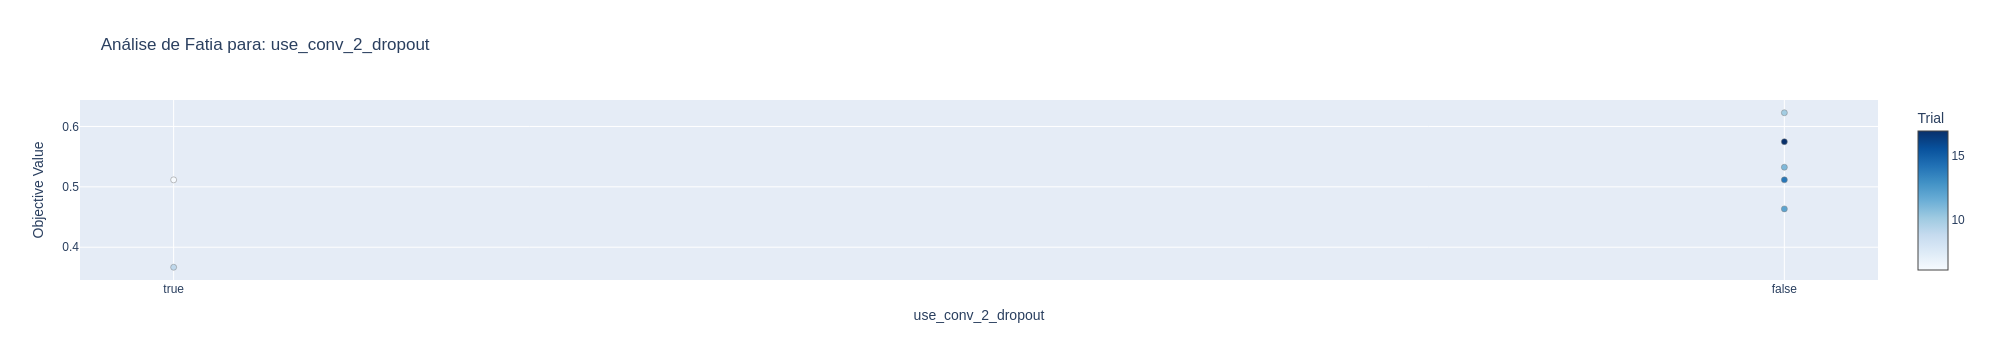

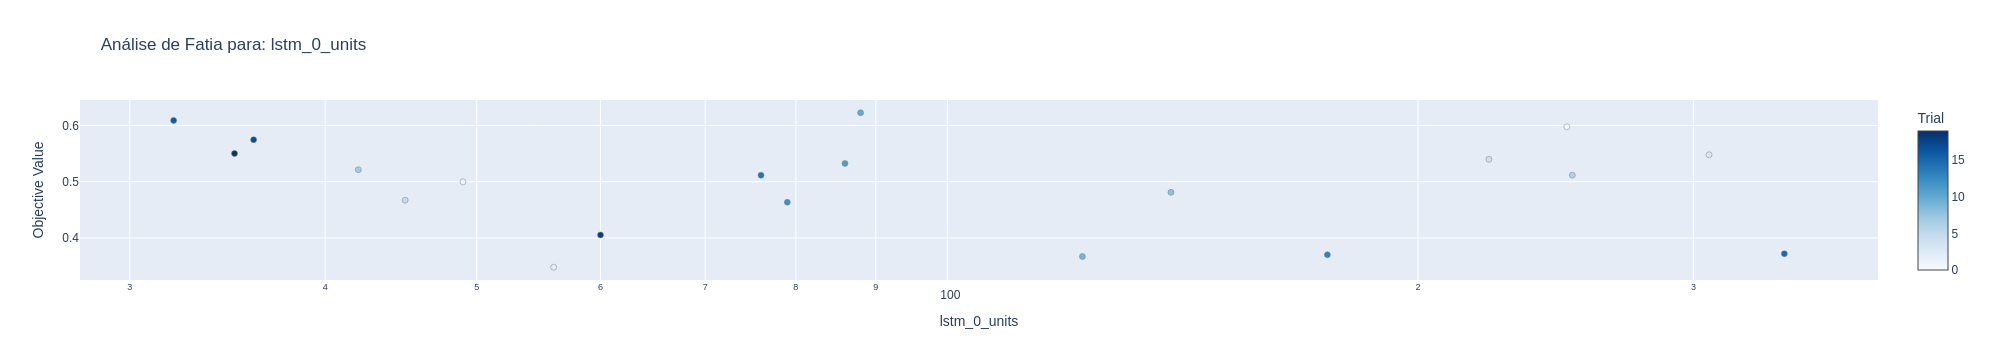

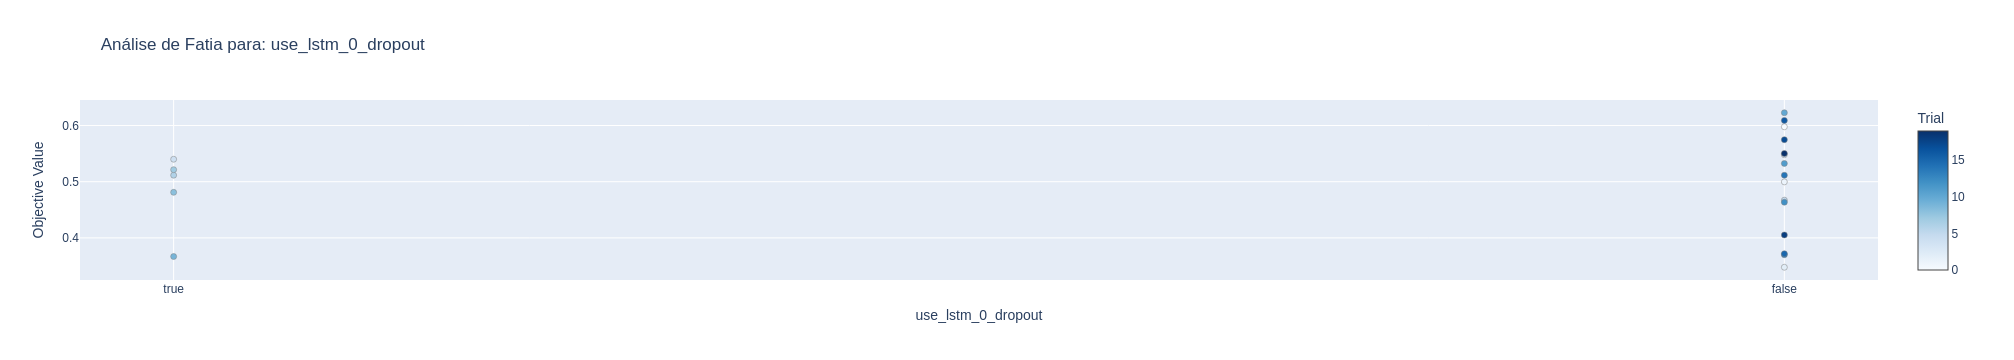

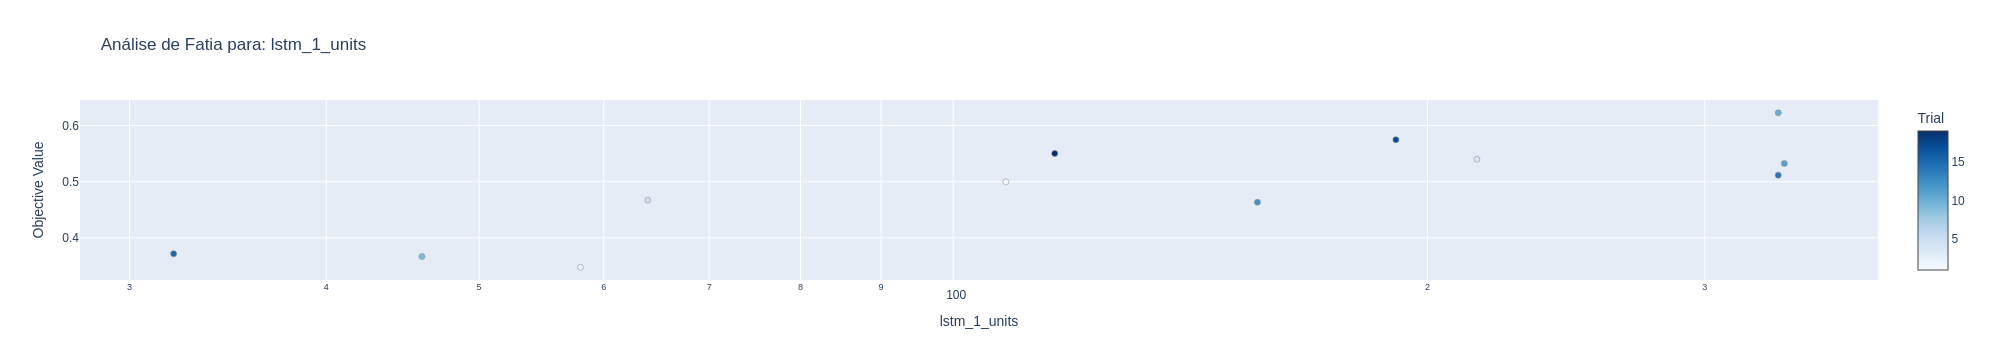

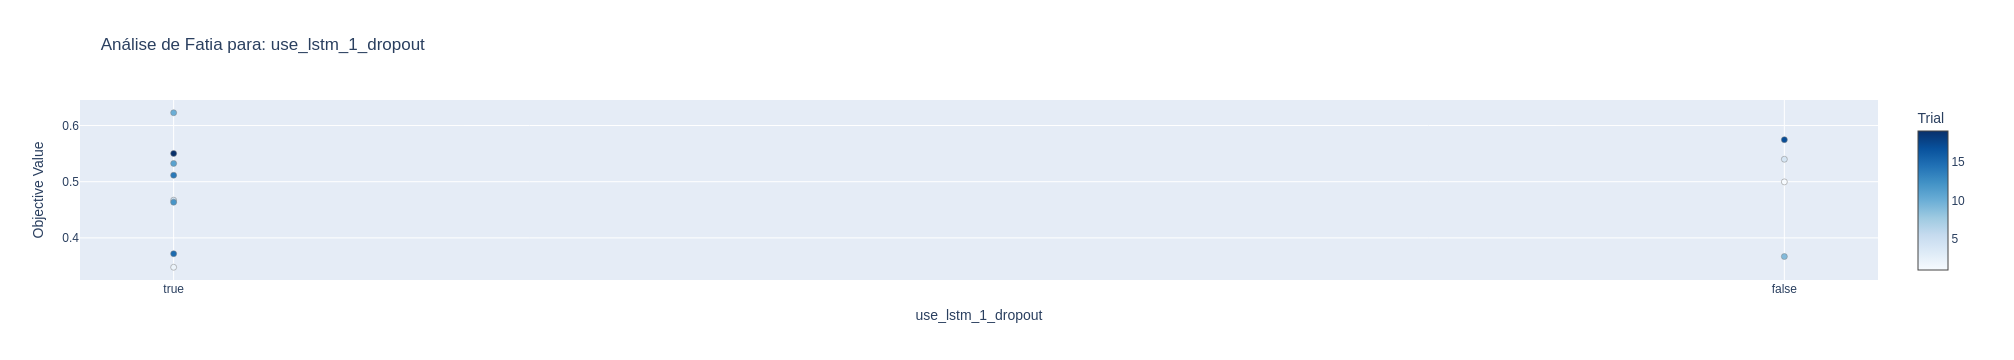

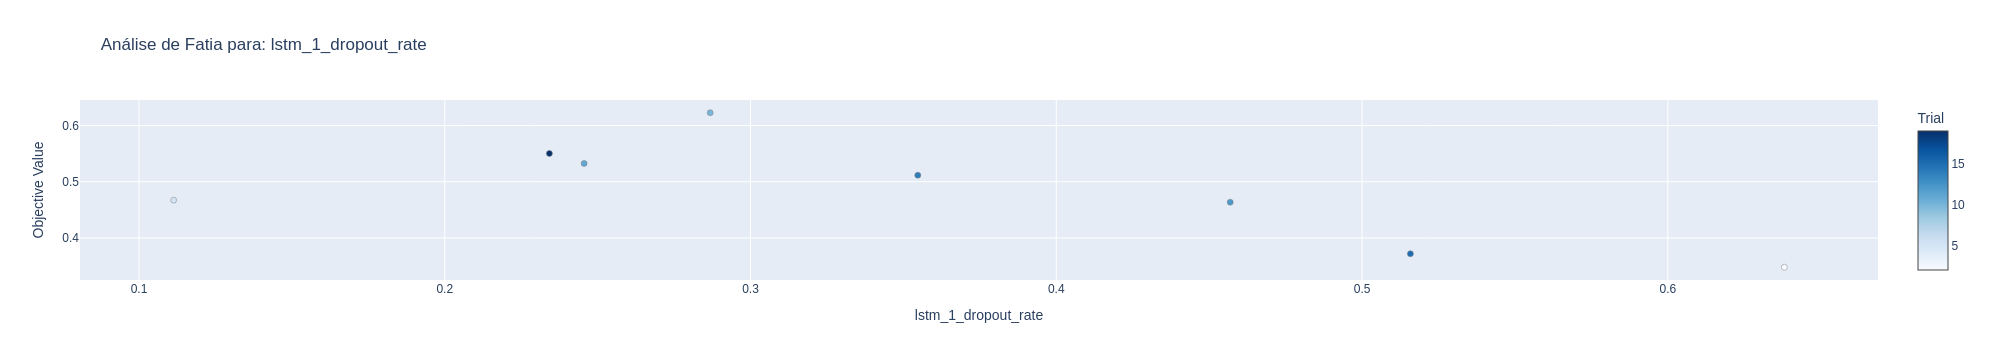

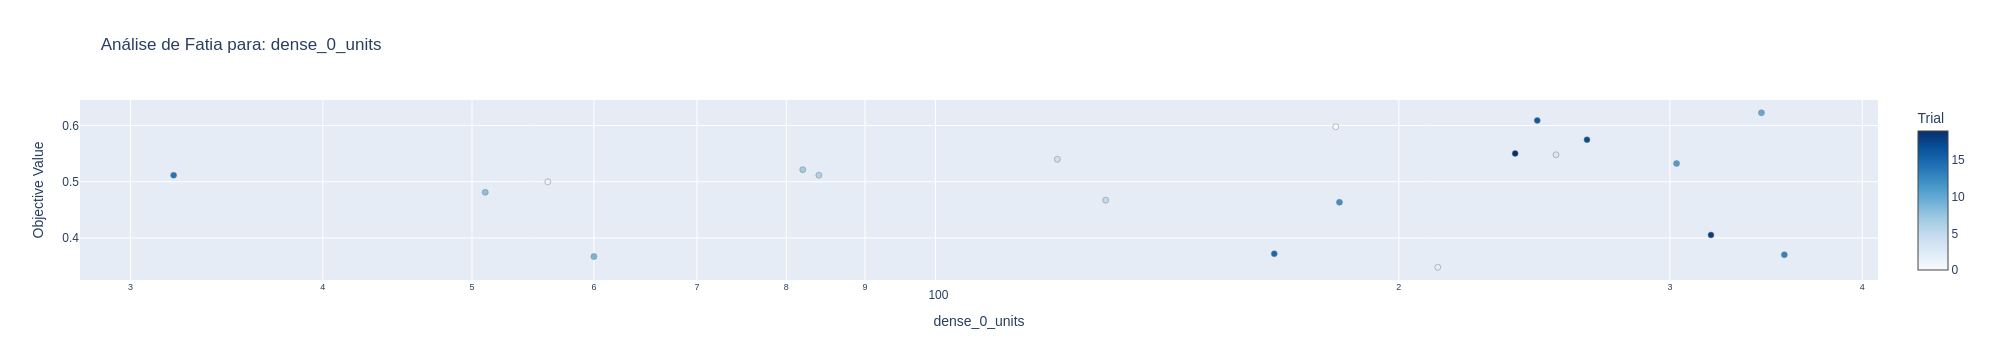

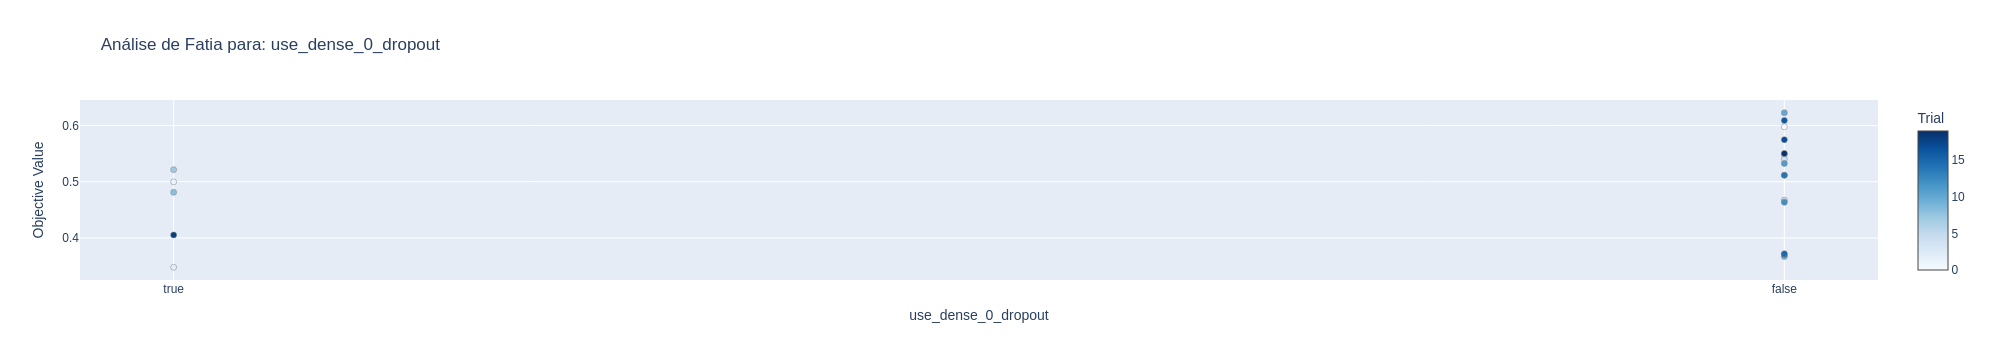

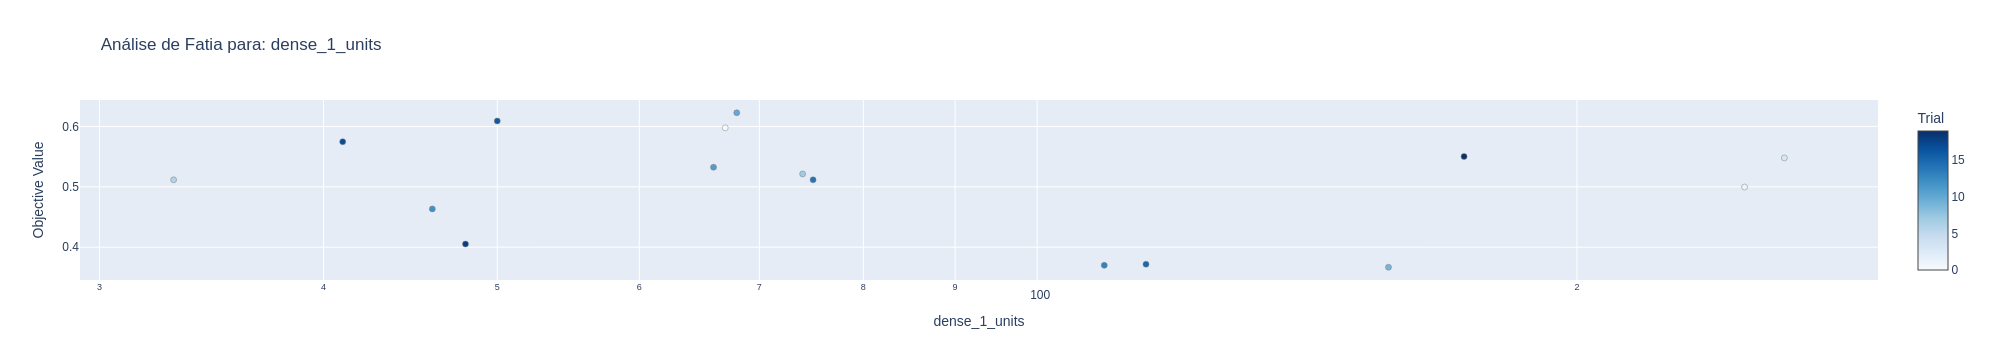

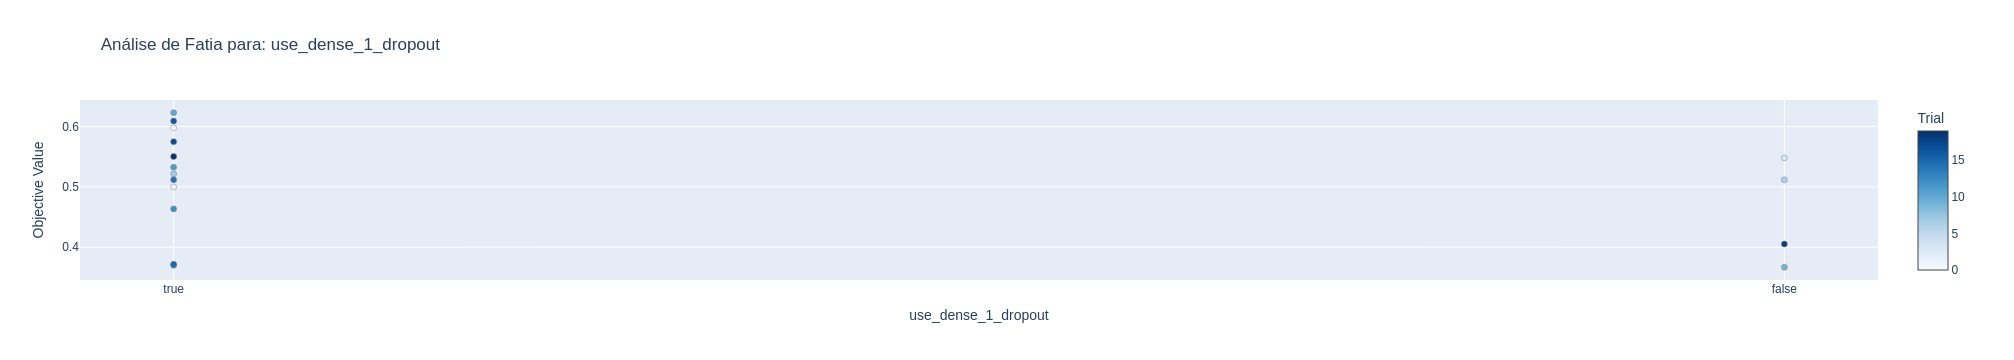

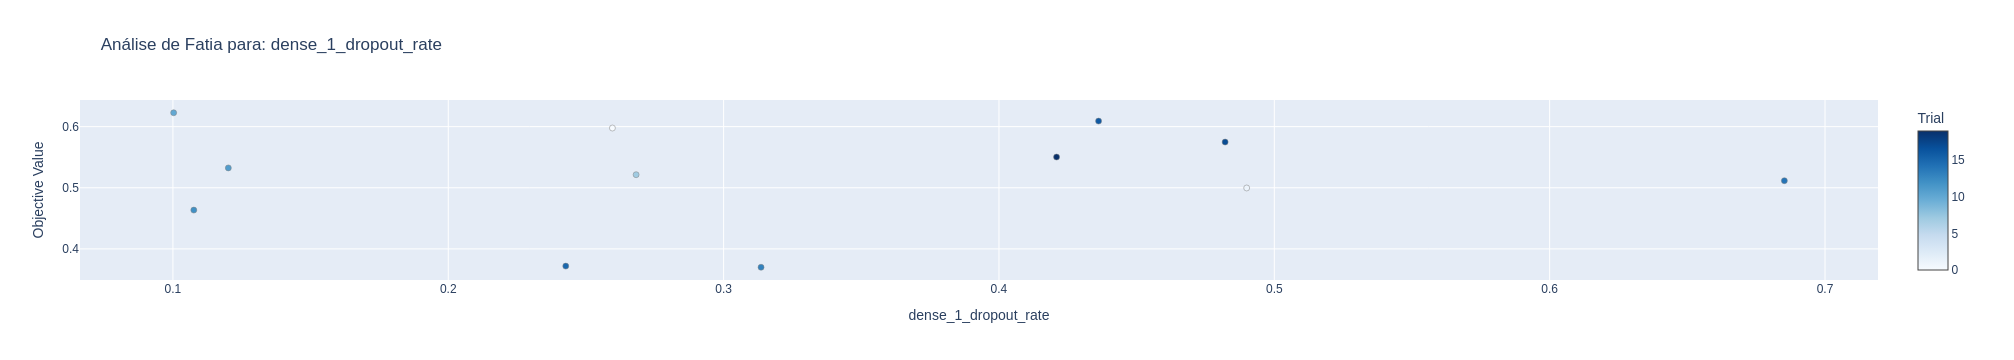

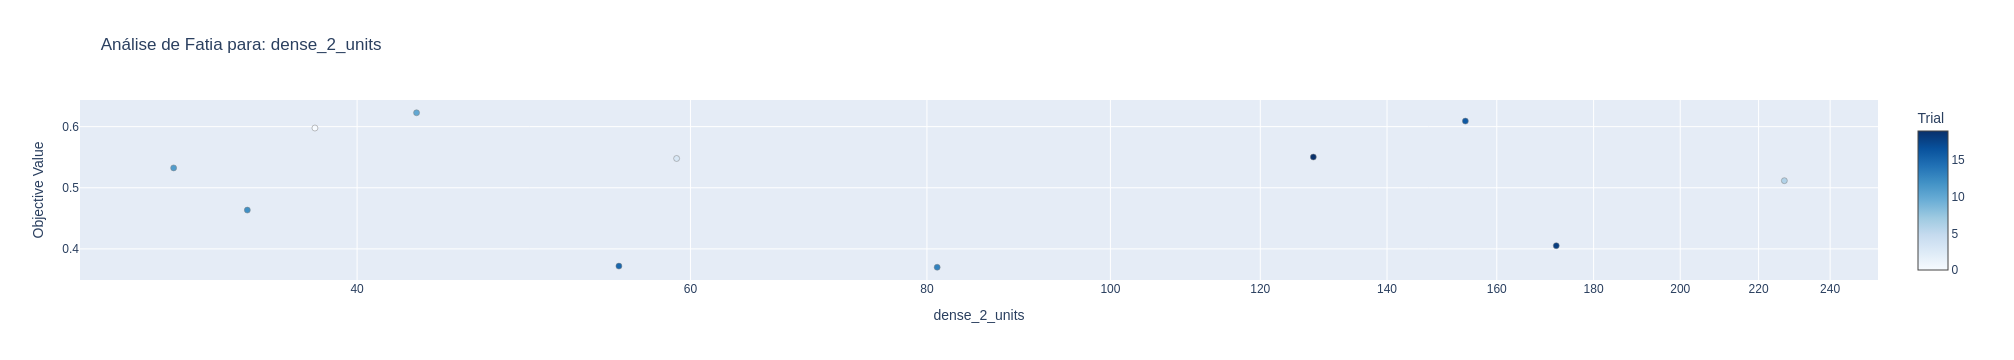

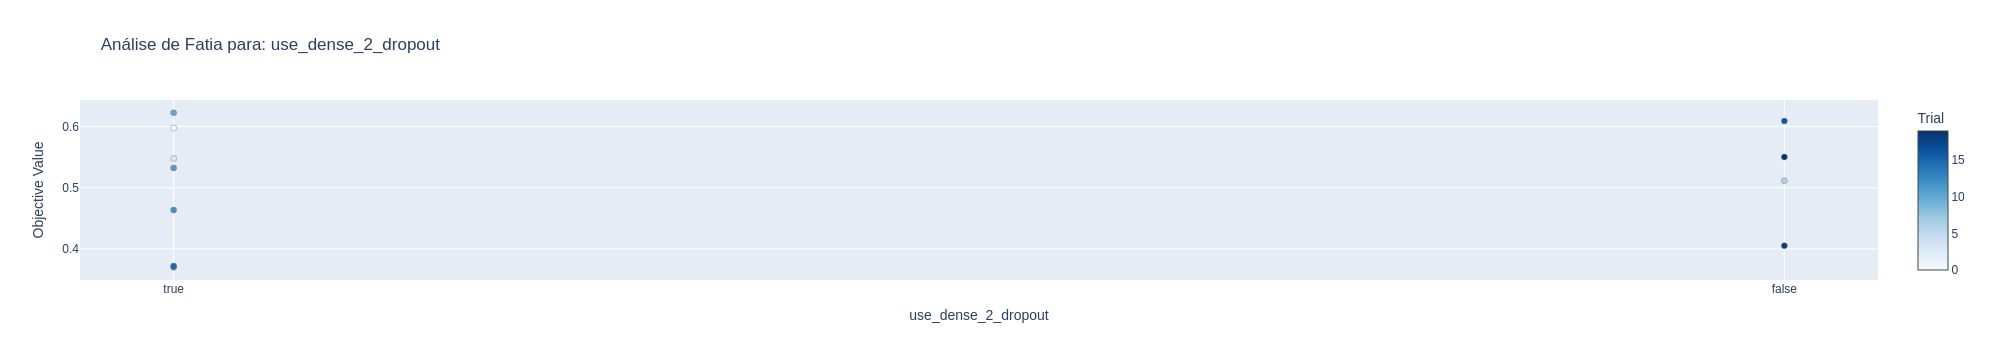

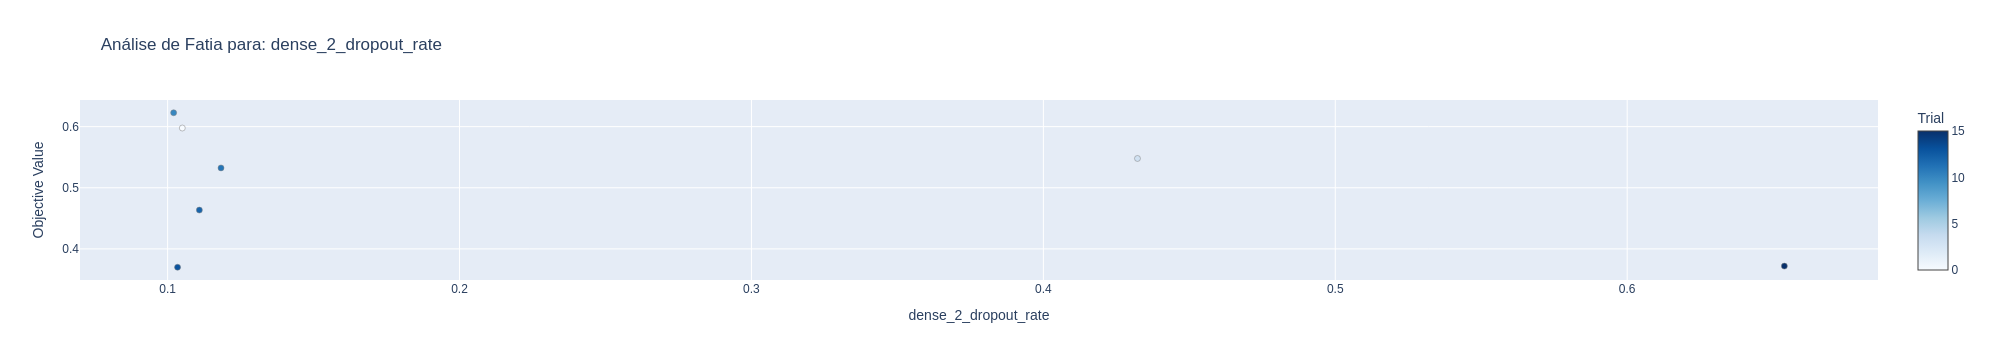

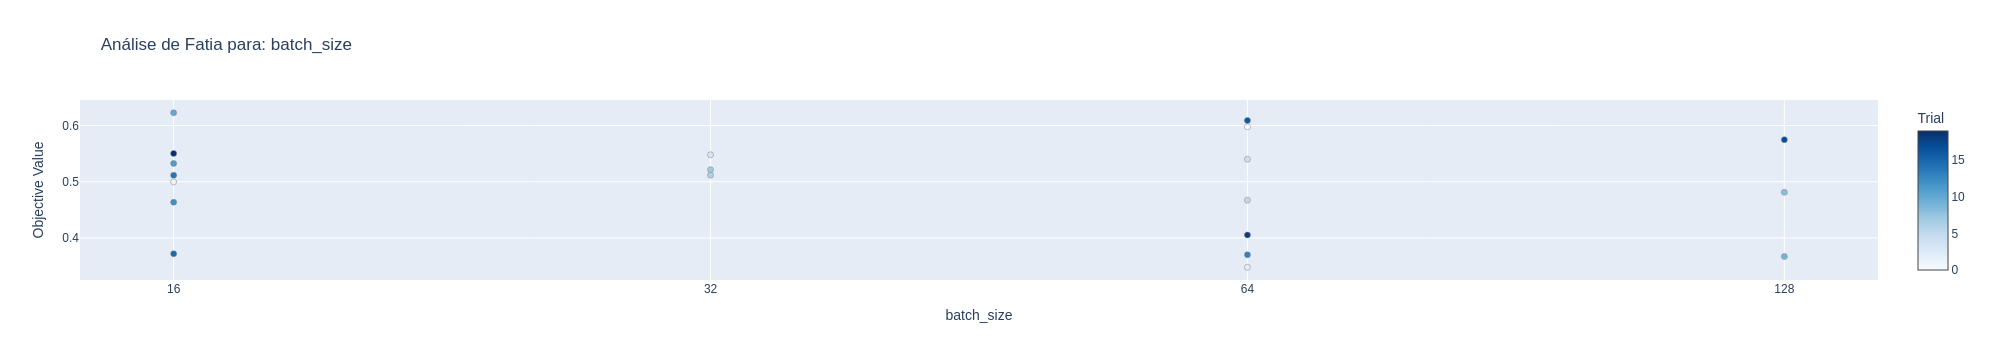


--- ETAPA 6: Treinando e avaliando o melhor modelo encontrado ---


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequencial    │ (None, 180, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 180, 285)  │      7,125 │ input_sequencial… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 285)  │      1,140 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 60, 285)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 60, 45)    │     51,345 │ max_pooling1d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 45)    │        180 │ conv1d_11[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 60, 45)    │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_6     │ (None, 20, 45)    │          0 │ dropout_15[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 20, 324)   │     73,224 │ max_pooling1d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 324)   │      1,296 │ conv1d_12[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_7     │ (None, 10, 324)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_10 (LSTM)      │ (None, 10, 88)    │    145,376 │ max_pooling1d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 88)    │        352 │ lstm_10[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_11 (LSTM)      │ (None, 334)       │    565,128 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 334)       │      1,336 │ lstm_11[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_contexto      │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 334)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 280)       │      2,800 │ input_contexto[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 614)       │          0 │ dropout_16[0][0]

 Total params: 1,087,333 (4.15 MB)

 Trainable params: 1,085,181 (4.14 MB)

 Non-trainable params: 2,152 (8.41 KB)

Epoch 1/5000
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5132 - loss: 190.4264
Epoch 2/5000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4737 - loss: 186.9062
Epoch 3/5000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5395 - loss: 184.2271
Epoch 4/5000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5000 - loss: 181.9094
Epoch 5/5000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4605 - loss: 179.7806
Epoch 6/5000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4474 - loss: 177.6154
Epoch 7/5000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4605 - loss: 175.5293
Epoch 8/5000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5395 - loss: 173.4560
Epoch 9/5000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5789 - loss: 171.3813
Epoch 10/5000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5526 - loss: 169.3228
Epoch 11/5000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4605 - loss: 167.3236
Epoch 12/5000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s

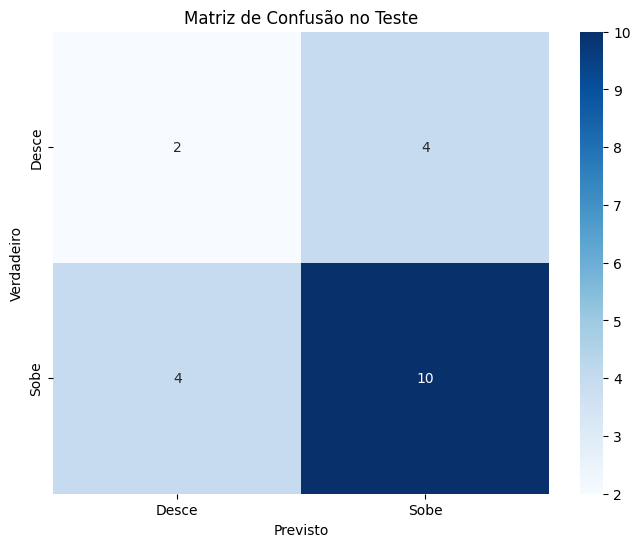

In [2]:
# =================================================================================
# OTIMIZAÇÃO DE CNN-LSTM PARA CLASSIFICAÇÃO BINÁRIA COM VALIDAÇÃO CRUZADA
# =================================================================================

# --- ETAPA 0: IMPORTAÇÕES ---
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import logging

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
logging.getLogger('tensorflow').setLevel(logging.ERROR)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization, concatenate
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
import re
from tensorflow.keras import regularizers
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_slice
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import train_test_split, TimeSeriesSplit

# --- ETAPA 1: CARREGAMENTO E PREPARAÇÃO DOS DADOS (ATUALIZADA) ---
print("--- ETAPA 1: Carregando e preparando os dados para Classificação Binária ---")
# ATUALIZAÇÃO: Carrega o novo dataset com o label binário.
NOME_ARQUIVO_DATASET = 'dataset_binario.csv'
NUM_TIMESTEPS = 180

try:
    df = pd.read_csv(NOME_ARQUIVO_DATASET, sep=';', index_col=0)
except FileNotFoundError:
    print(f"ERRO: Arquivo '{NOME_ARQUIVO_DATASET}' não foi encontrado.")
    exit()

# ATUALIZAÇÃO: O alvo (y) agora é a coluna 'label_binario', um vetor simples.
y = df['label_binario'].values
X_flat = df.drop(columns=['label_binario'])

# A separação das features (sequenciais e de contexto) permanece a mesma.
regex_sequencial = re.compile(r'_c\d+$')
context_feature_names = [col for col in X_flat.columns if not regex_sequencial.search(col)]
seq_feature_names = sorted(list(set([regex_sequencial.sub('', col) for col in X_flat.columns if regex_sequencial.search(col)])))
X_context = X_flat[context_feature_names].values
num_samples, num_seq_features = len(df), len(seq_feature_names)
X_seq = np.zeros((num_samples, NUM_TIMESTEPS, num_seq_features))
for i, feature_name in enumerate(seq_feature_names):
    cols = [f'{feature_name}_c{j}' for j in range(1, NUM_TIMESTEPS + 1)]
    X_seq[:, :, i] = X_flat[cols].values

print(f"Formato dos dados de Contexto (X_context): {X_context.shape}")
print(f"Formato dos dados Sequenciais (X_seq): {X_seq.shape}")

# A estratificação agora é feita diretamente no vetor y.
X_seq_train_val, X_seq_test, X_context_train_val, X_context_test, y_train_val, y_test = train_test_split(
    X_seq, X_context, y, test_size=0.2, shuffle=False
)
print("Divisão de dados concluída.")


# --- ETAPA 2: DEFINIÇÃO DA FUNÇÃO DE CRIAÇÃO DO MODELO (ATUALIZADA) ---
def create_binary_model(trial, input_shape_seq, input_shape_context):
    # A definição dos hiperparâmetros a serem otimizados permanece a mesma.
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop'])
    n_conv_layers = trial.suggest_int('n_conv_layers', 1, 3)
    n_lstm_layers = trial.suggest_int('n_lstm_layers', 1, 3)
    n_dense_layers = trial.suggest_int('n_dense_layers', 1, 3)
    context_dense_units = trial.suggest_int('context_dense_units', 16, 328, log=True)
    l1_strength = trial.suggest_float('l1_strength', 1e-8, 1e-2, log=True)
    l2_strength = trial.suggest_float('l2_strength', 1e-8, 1e-2, log=True)
    kernel_regularizer = regularizers.l1_l2(l1=l1_strength, l2=l2_strength)

    # A construção da arquitetura de múltiplas entradas é a mesma até a camada de saída.
    input_seq = Input(shape=input_shape_seq, name='input_sequencial')
    input_context = Input(shape=input_shape_context, name='input_contexto')
    
    current_seq = input_seq
    for i in range(n_conv_layers):
        filters = trial.suggest_int(f'conv_{i}_filters', 16, 328, log=True)
        kernel_size = trial.suggest_int(f'conv_{i}_kernel_size', 1, min(NUM_TIMESTEPS, 5))
        padding = trial.suggest_categorical(f'conv_{i}_padding', ['causal', 'same'])
        pool_size = trial.suggest_categorical(f'conv_{i}_pool_size', [1, 2, 3])
        
        current_seq = Conv1D(filters=filters, kernel_size=kernel_size, activation='relu', padding=padding, kernel_regularizer=kernel_regularizer)(current_seq)
        current_seq = BatchNormalization()(current_seq)
        if trial.suggest_categorical(f'use_conv_{i}_dropout', [True, False]):
            rate = trial.suggest_float(f'conv_{i}_dropout_rate', 0.1, 0.7)
            current_seq = Dropout(rate=rate)(current_seq)
        if current_seq.shape[1] > pool_size and pool_size > 1:
             current_seq = MaxPooling1D(pool_size=pool_size)(current_seq)
    
    for i in range(n_lstm_layers):
        units = trial.suggest_int(f'lstm_{i}_units', 32, 356, log=True)
        return_sequences = (i < n_lstm_layers - 1)
        current_seq = LSTM(units=units, return_sequences=return_sequences, kernel_regularizer=kernel_regularizer)(current_seq)
        current_seq = BatchNormalization()(current_seq)
        if trial.suggest_categorical(f'use_lstm_{i}_dropout', [True, False]):
            rate = trial.suggest_float(f'lstm_{i}_dropout_rate', 0.1, 0.7)
            current_seq = Dropout(rate=rate)(current_seq)

    x_context = Dense(units=context_dense_units, activation='relu', kernel_regularizer=kernel_regularizer)(input_context)
    x = concatenate([current_seq, x_context])
    
    for i in range(n_dense_layers):
        units = trial.suggest_int(f'dense_{i}_units', 32, 356, log=True)
        x = Dense(units=units, activation='relu', kernel_regularizer=kernel_regularizer)(x)
        if trial.suggest_categorical(f'use_dense_{i}_dropout', [True, False]):
            rate = trial.suggest_float(f'dense_{i}_dropout_rate', 0.1, 0.7)
            x = Dropout(rate=rate)(x)
            
    # ATUALIZAÇÃO: Camada de saída para classificação binária.
    # 1 neurônio com ativação 'sigmoid'.
    output = Dense(1, activation='sigmoid', name='output_binario')(x)
    
    model = Model(inputs=[input_seq, input_context], outputs=output)
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate) if optimizer_name == 'Adam' else tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    
    # ATUALIZAÇÃO: Compilação para classificação binária.
    # A função de perda é 'binary_crossentropy'.
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# --- ETAPA 3: DEFINIÇÃO DA FUNÇÃO OBJECTIVE COM VALIDAÇÃO CRUZADA (ATUALIZADA) ---
print("\n--- ETAPA 3: Definindo a função objective para Classificação Binária ---")
def objective(trial):
    tf.keras.backend.clear_session()
    f1_scores = []
    # Usa TimeSeriesSplit para a validação cruzada cronológica
    tscv = TimeSeriesSplit(n_splits=5)
    
    # A estratificação agora é feita diretamente no vetor y_train_val.
    for train_index, val_index in tscv.split(X_seq_train_val):
        X_seq_train_fold, X_seq_val_fold = X_seq_train_val[train_index], X_seq_train_val[val_index]
        X_context_train_fold, X_context_val_fold = X_context_train_val[train_index], X_context_train_val[val_index]
        y_train_fold, y_val_fold = y_train_val[train_index], y_train_val[val_index]
        
        scaler_seq = StandardScaler()
        scaler_seq.fit(X_seq_train_fold.reshape(-1, X_seq_train_fold.shape[-1]))
        scaler_context = StandardScaler()
        scaler_context.fit(X_context_train_fold)
        
        def scale_seq_data(data, scaler):
            return scaler.transform(data.reshape(-1, data.shape[-1])).reshape(data.shape)
            
        X_seq_train_fold_s = scale_seq_data(X_seq_train_fold, scaler_seq)
        X_seq_val_fold_s = scale_seq_data(X_seq_val_fold, scaler_seq)
        X_context_train_fold_s = scaler_context.transform(X_context_train_fold)
        X_context_val_fold_s = scaler_context.transform(X_context_val_fold)
        
        model = create_binary_model(trial, X_seq_train_fold_s.shape[1:], X_context_train_fold_s.shape[1:])
        batch_size = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
        
        model.fit(
            [X_seq_train_fold_s, X_context_train_fold_s], y_train_fold,
            validation_data=([X_seq_val_fold_s, X_context_val_fold_s], y_val_fold),
            epochs=5000,
            batch_size=batch_size,
            callbacks=[EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)],
            verbose=0
        )
        
        # Substitui a acurácia pelo F1-Score.
        
        # 1. Faz a previsão, que retorna probabilidades
        y_pred_probs = model.predict([X_seq_val_fold_s, X_context_val_fold_s])
        
        # 2. Converte as probabilidades para classes (0 ou 1)
        y_pred_classes = (y_pred_probs > 0.5).astype("int32")
        
        # 3. y_val_fold já está no formato correto (0s e 1s)
        y_true_classes = y_val_fold
        
        # 4. Calcula o F1-Score e o armazena.
        # Para classificação binária, 'average' pode ser 'binary' ou 'macro'/'weighted' (darão o mesmo resultado para a classe positiva).
        # Usar 'macro' é uma boa prática consistente.
        score = f1_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
        f1_scores.append(score)
        
    #  Retorna a média dos F1-Scores para o Optuna
    return np.mean(f1_scores)

# --- ETAPA 4: EXECUÇÃO DA OTIMIZAÇÃO ---
print("\n--- ETAPA 4: Executando a otimização com Optuna ---")
study = optuna.create_study(direction='maximize')
########################################
study.optimize(objective, n_trials=20)

# --- ETAPA 5: VISUALIZAÇÃO DOS RESULTADOS DA OTIMIZAÇÃO ---
print("\n--- ETAPA 5: Gerando gráficos de análise da otimização ---")
if not study.trials:
    print("AVISO: O estudo não possui trials concluídos.")
else:
    best_trial = study.best_trial
    print(f"Melhor Acurácia Média na Validação Cruzada: {best_trial.value:.4f}")
    print("Melhores Hiperparâmetros:", best_trial.params)
    plot_optimization_history(study).show()
    plot_param_importances(study).show()
    all_params = list(study.best_trial.params.keys())
    for param_name in all_params:
        fig_slice = plot_slice(study, params=[param_name])
        fig_slice.update_layout(title_text=f"Análise de Fatia para: {param_name}")
        fig_slice.show()

# --- ETAPA 6: TREINAMENTO E AVALIAÇÃO DO MELHOR MODELO (ATUALIZADA) ---
print("\n--- ETAPA 6: Treinando e avaliando o melhor modelo encontrado ---")
scaler_seq_final = StandardScaler()
scaler_seq_final.fit(X_seq_train_val.reshape(-1, X_seq_train_val.shape[-1]))
scaler_context_final = StandardScaler()
scaler_context_final.fit(X_context_train_val)
def scale_seq_data_final(data, scaler):
    return scaler.transform(data.reshape(-1, data.shape[-1])).reshape(data.shape)
X_seq_train_val_s = scale_seq_data_final(X_seq_train_val, scaler_seq_final)
X_context_train_val_s = scaler_context_final.transform(X_context_train_val)
X_seq_test_s = scale_seq_data_final(X_seq_test, scaler_seq_final)
X_context_test_s = scaler_context_final.transform(X_context_test)

final_model = create_binary_model(best_trial, X_seq_train_val_s.shape[1:], X_context_train_val_s.shape[1:])
final_model.summary()
history = final_model.fit(
    [X_seq_train_val_s, X_context_train_val_s], y_train_val,
    epochs=5000,
    batch_size=best_trial.params['batch_size'],
    callbacks=[EarlyStopping(monitor='loss', patience=50, restore_best_weights=True)],
    verbose=1
)

# --- ETAPA 7: AVALIAÇÃO FINAL NO CONJUNTO DE TESTE (ATUALIZADA) ---
print("\n--- ETAPA 7: Avaliação Final no Conjunto de Teste ---")
test_loss, test_accuracy = final_model.evaluate([X_seq_test_s, X_context_test_s], y_test)
print(f"Acurácia no Teste: {test_accuracy:.4f}")

# ATUALIZAÇÃO: Lógica de previsão para classificação binária.
# A saída do modelo é uma probabilidade. Arredondamos para obter a classe (0 ou 1).
y_pred_probs = final_model.predict([X_seq_test_s, X_context_test_s])
y_pred = (y_pred_probs > 0.5).astype("int32")
y_true = y_test # y_true já está no formato correto (0s e 1s).

print("\nRelatório de Classificação:")
# ATUALIZAÇÃO: Nomes das classes para o relatório.
class_names = ['Desce', 'Sobe']
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
print("\nMatriz de Confusão:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsto'); plt.ylabel('Verdadeiro'); plt.title('Matriz de Confusão no Teste'); plt.show()


## Com L1 e L2 exclusivos para cada camada
Este é um script completo e robusto para **encontrar a melhor arquitetura de um modelo híbrido CNN-LSTM e avaliá-la de forma justa** para um problema de **classificação binária** (prever se o preço vai subir ou descer).

O fluxo de trabalho é o seguinte:

1.  **Preparação de Dados para Múltiplas Entradas:**
    *   O código carrega um dataset com um label binário (0 para "Desce", 1 para "Sobe").
    *   Ele reconstrói as features "achatadas" em duas entradas distintas para o modelo:
        *   `X_seq`: Um tensor 3D com os dados sequenciais (indicadores de cada vela), destinado às camadas CNN e LSTM.
        *   `X_context`: Um tensor 2D com os dados de contexto (indicadores diários, etc.), destinado a uma camada Densa.

2.  **Divisão Cronológica em Dois Níveis (Metodologia Correta):**
    *   **Nível 1 (Divisão Estratégica):** O dataset é dividido cronologicamente (`shuffle=False`) em um grande conjunto de **Treino/Validação (80%)** e um conjunto de **Teste Final (20%)**. O conjunto de teste é "trancado" e não é usado até a avaliação final, garantindo uma avaliação imparcial.
    *   **Nível 2 (Validação Cruzada Cronológica):** Dentro da otimização do Optuna, o conjunto de Treino/Validação é repetidamente dividido em 5 "folds" usando `TimeSeriesSplit`. Isso garante que o modelo seja sempre treinado com dados do passado para prever o futuro, fornecendo uma avaliação robusta e realista para cada `trial`.

3.  **Otimização Inteligente com Optuna (Métrica Robusta e Regularização Granular):**
    *   O Optuna testa várias combinações (`n_trials`) de arquiteturas de CNN-LSTM.
    *   Para cada teste, ele varia a estrutura completa da rede, incluindo a regularização L1/L2 de forma **separada para cada tipo de camada** (CNN, LSTM, etc.), permitindo uma busca por regularização extremamente flexível.
    *   **Ponto Chave:** A métrica que o Optuna tenta maximizar é o **Macro Average F1-Score**. Esta é a escolha ideal, pois avalia o equilíbrio da performance do modelo entre as classes "Sobe" e "Desce", sendo muito mais confiável que a acurácia.

4.  **Treinamento e Avaliação Final:**
    *   Após o Optuna eleger a melhor combinação de hiperparâmetros (aquela com o maior F1-Score médio), um novo modelo é construído com essa arquitetura.
    *   Este modelo final é treinado no conjunto de **Treino/Validação original (os 80% completos)** para aprender com o máximo de dados possível.
    *   Finalmente, o modelo treinado é avaliado **uma única vez** no conjunto de **Teste Final (os 20% intocados)**. Os resultados (Acurácia, F1-Score, Relatório de Classificação e Matriz de Confusão) representam uma estimativa honesta de como o modelo se comportaria em dados novos.

5.  **Visualização:**
    *   Ao final, são exibidos gráficos do Optuna que mostram o histórico da otimização e a importância de cada hiperparâmetro, permitindo entender quais decisões de arquitetura mais impactaram o resultado.


[I 2026-03-18 11:25:03,574] A new study created in memory with name: no-name-720ce9ce-a032-47bd-9766-dc3bcf3ad0dc


--- ETAPA 1: Carregando e preparando os dados para Classificação Binária ---
Formato dos dados de Contexto (X_context): (97, 9)
Formato dos dados Sequenciais (X_seq): (97, 120, 12)
Divisão de dados concluída.

--- ETAPA 3: Definindo a função objective para Classificação Binária ---

--- ETAPA 4: Executando a otimização com Optuna ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


[I 2026-03-18 11:28:53,436] Trial 0 finished with value: 0.5492354214413038 and parameters: {'learning_rate': 0.00023822380477000937, 'optimizer': 'RMSprop', 'n_conv_layers': 2, 'n_lstm_layers': 2, 'n_dense_layers': 2, 'context_dense_units': 95, 'l1_conv': 8.301289440068486e-08, 'l2_conv': 8.305497466915049e-08, 'l1_lstm': 0.003750137829676101, 'l2_lstm': 6.28302633804512e-06, 'l1_context': 0.0007000635305590236, 'l2_context': 8.239456489031339e-06, 'l1_dense': 2.599806839835068e-06, 'l2_dense': 3.572969211560478e-08, 'conv_0_filters': 219, 'conv_0_kernel_size': 5, 'conv_0_padding': 'same', 'conv_0_pool_size': 3, 'use_conv_0_dropout': False, 'conv_1_filters': 172, 'conv_1_kernel_size': 4, 'conv_1_padding': 'same', 'conv_1_pool_size': 3, 'use_conv_1_dropout': False, 'lstm_0_units': 280, 'use_lstm_0_dropout': False, 'lstm_1_units': 86, 'use_lstm_1_dropout': False, 'dense_0_units': 131, 'use_dense_0_dropout': False, 'dense_1_units': 251, 'use_dense_1_dropout': True, 'dense_1_dropout_rate'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step


[I 2026-03-18 11:31:50,507] Trial 1 finished with value: 0.4434168308471714 and parameters: {'learning_rate': 1.0342433697155104e-05, 'optimizer': 'RMSprop', 'n_conv_layers': 2, 'n_lstm_layers': 3, 'n_dense_layers': 3, 'context_dense_units': 36, 'l1_conv': 3.881078174733299e-06, 'l2_conv': 1.415831785706088e-07, 'l1_lstm': 8.166792151053228e-07, 'l2_lstm': 2.393877795558273e-08, 'l1_context': 1.1355090223911049e-05, 'l2_context': 0.00010933256061063749, 'l1_dense': 1.5433182692886826e-08, 'l2_dense': 5.068322981241498e-05, 'conv_0_filters': 38, 'conv_0_kernel_size': 2, 'conv_0_padding': 'same', 'conv_0_pool_size': 1, 'use_conv_0_dropout': True, 'conv_0_dropout_rate': 0.37520706650961977, 'conv_1_filters': 153, 'conv_1_kernel_size': 3, 'conv_1_padding': 'causal', 'conv_1_pool_size': 3, 'use_conv_1_dropout': True, 'conv_1_dropout_rate': 0.2442727035157924, 'lstm_0_units': 108, 'use_lstm_0_dropout': True, 'lstm_0_dropout_rate': 0.6966203400670389, 'lstm_1_units': 66, 'use_lstm_1_dropout':

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


[I 2026-03-18 12:32:22,939] Trial 18 finished with value: 0.5412523080634535 and parameters: {'learning_rate': 0.0006801391416802023, 'optimizer': 'RMSprop', 'n_conv_layers': 1, 'n_lstm_layers': 1, 'n_dense_layers': 1, 'context_dense_units': 59, 'l1_conv': 1.8850671826554889e-06, 'l2_conv': 2.1456137086721423e-06, 'l1_lstm': 0.00018337705907266774, 'l2_lstm': 5.889542585210181e-07, 'l1_context': 3.929692709814407e-08, 'l2_context': 2.3305144131772657e-05, 'l1_dense': 0.0001701156746473332, 'l2_dense': 1.630293766942255e-06, 'conv_0_filters': 326, 'conv_0_kernel_size': 4, 'conv_0_padding': 'causal', 'conv_0_pool_size': 3, 'use_conv_0_dropout': True, 'conv_0_dropout_rate': 0.10414134011171433, 'lstm_0_units': 74, 'use_lstm_0_dropout': False, 'dense_0_units': 56, 'use_dense_0_dropout': True, 'dense_0_dropout_rate': 0.13699096805578231, 'batch_size': 16}. Best is trial 11 with value: 0.6500874289109584.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


[I 2026-03-18 12:41:07,600] Trial 19 finished with value: 0.4838095238095238 and parameters: {'learning_rate': 0.00010674314488581593, 'optimizer': 'RMSprop', 'n_conv_layers': 2, 'n_lstm_layers': 2, 'n_dense_layers': 2, 'context_dense_units': 197, 'l1_conv': 3.541025514120243e-05, 'l2_conv': 5.29667090322818e-05, 'l1_lstm': 0.009717035240097129, 'l2_lstm': 0.0023594818111117304, 'l1_context': 1.4952402981934896e-06, 'l2_context': 3.0518424503904444e-07, 'l1_dense': 0.0030861190015781404, 'l2_dense': 1.0875679144617565e-07, 'conv_0_filters': 82, 'conv_0_kernel_size': 5, 'conv_0_padding': 'same', 'conv_0_pool_size': 3, 'use_conv_0_dropout': False, 'conv_1_filters': 24, 'conv_1_kernel_size': 1, 'conv_1_padding': 'causal', 'conv_1_pool_size': 2, 'use_conv_1_dropout': False, 'lstm_0_units': 332, 'use_lstm_0_dropout': False, 'lstm_1_units': 410, 'use_lstm_1_dropout': True, 'lstm_1_dropout_rate': 0.674156885094005, 'dense_0_units': 98, 'use_dense_0_dropout': False, 'dense_1_units': 438, 'use_


--- ETAPA 5: Gerando gráficos de análise da otimização ---
Melhor Acurácia Média na Validação Cruzada: 0.6501
Melhores Hiperparâmetros: {'learning_rate': 0.0003789983342426549, 'optimizer': 'RMSprop', 'n_conv_layers': 1, 'n_lstm_layers': 1, 'n_dense_layers': 1, 'context_dense_units': 123, 'l1_conv': 4.1207479375984475e-07, 'l2_conv': 1.1460235325592753e-08, 'l1_lstm': 0.005865254297039629, 'l2_lstm': 0.005154301251460302, 'l1_context': 6.02323074984713e-08, 'l2_context': 2.3152299919775306e-06, 'l1_dense': 0.007300562895003238, 'l2_dense': 6.735278655115255e-07, 'conv_0_filters': 121, 'conv_0_kernel_size': 5, 'conv_0_padding': 'same', 'conv_0_pool_size': 3, 'use_conv_0_dropout': False, 'lstm_0_units': 233, 'use_lstm_0_dropout': False, 'dense_0_units': 74, 'use_dense_0_dropout': False, 'batch_size': 64}


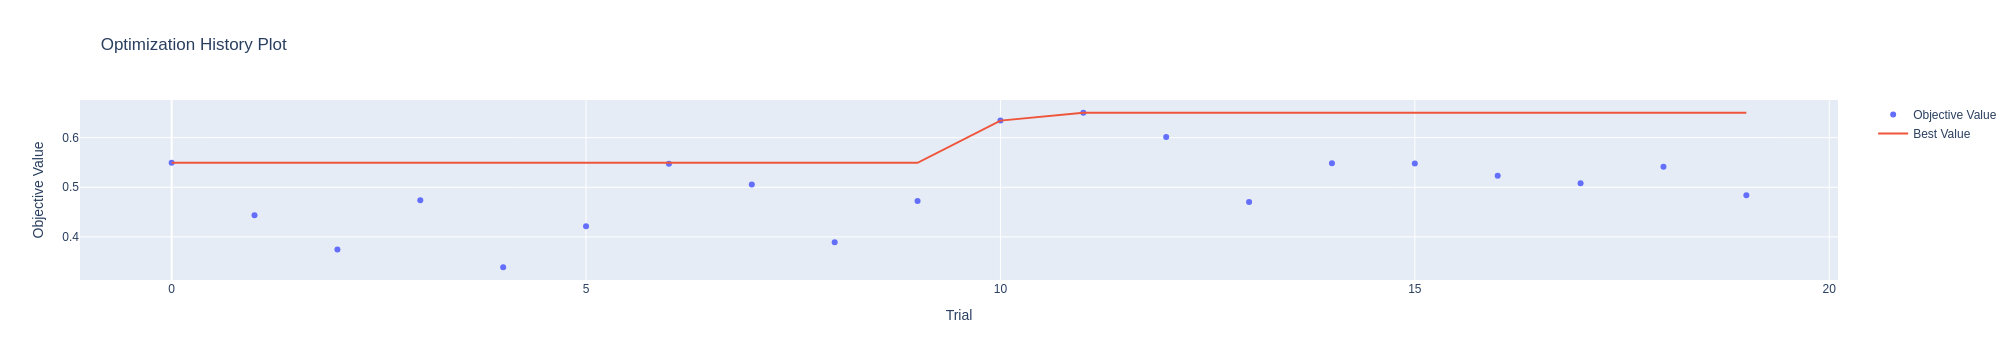

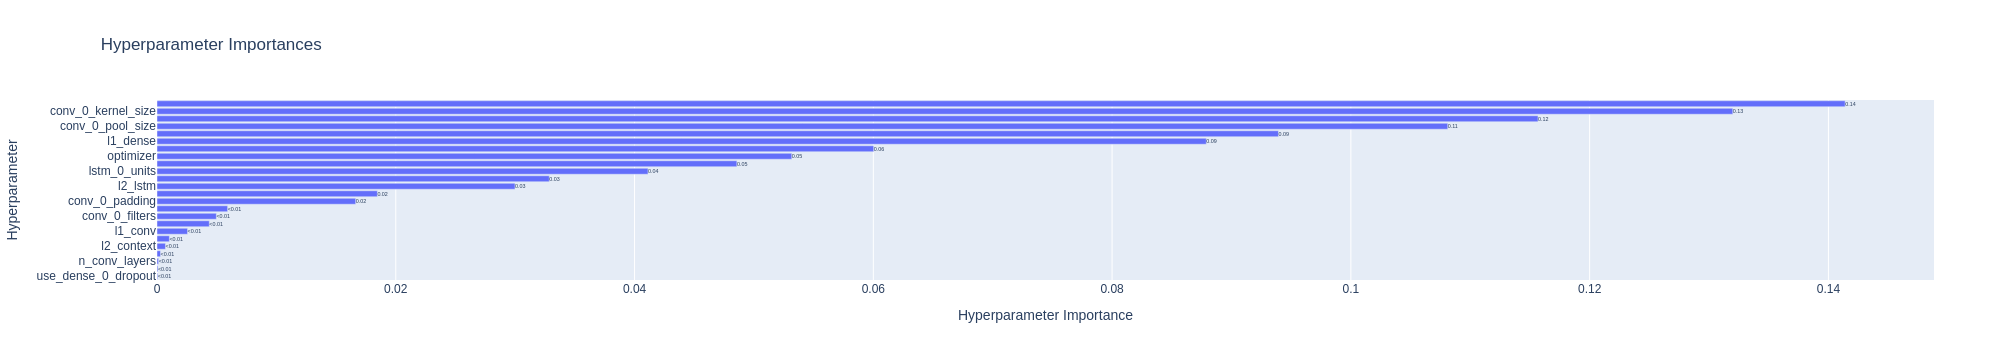

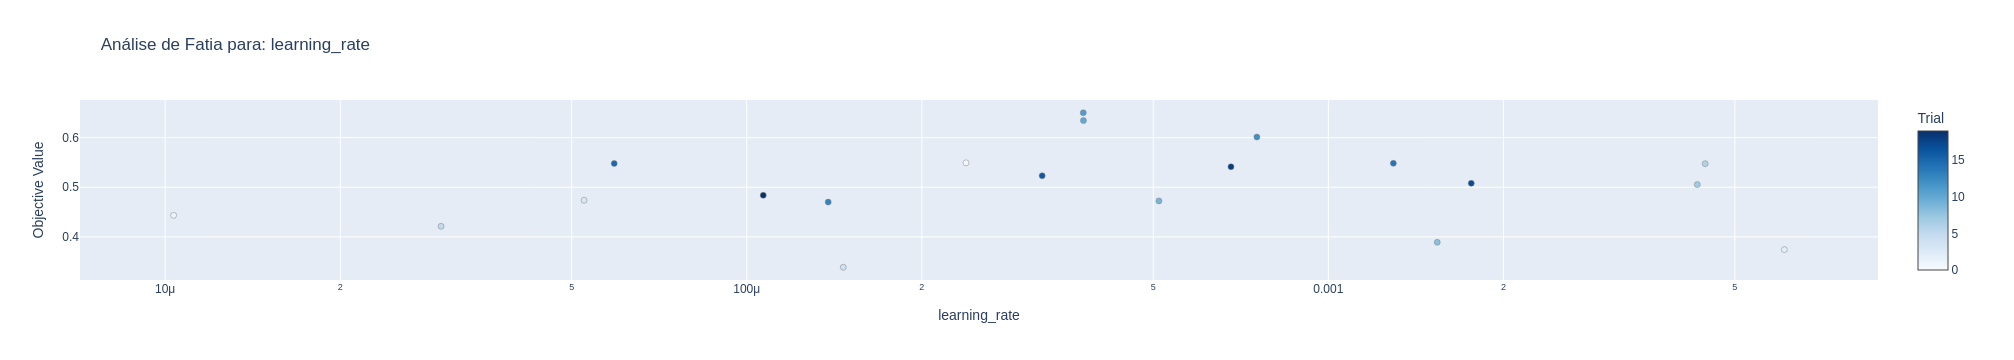

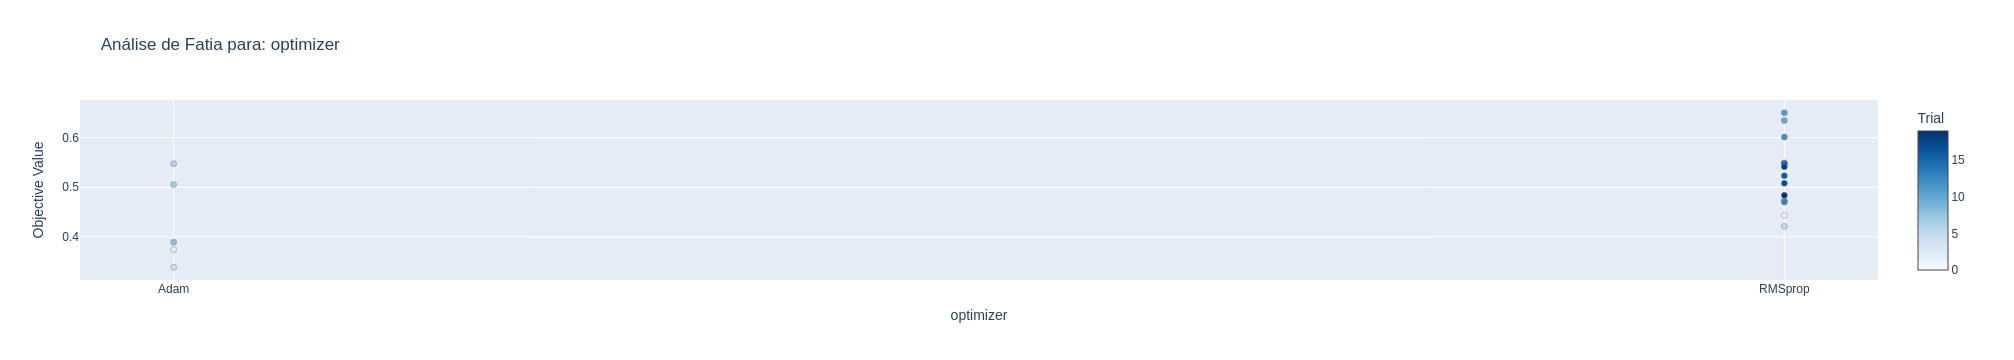

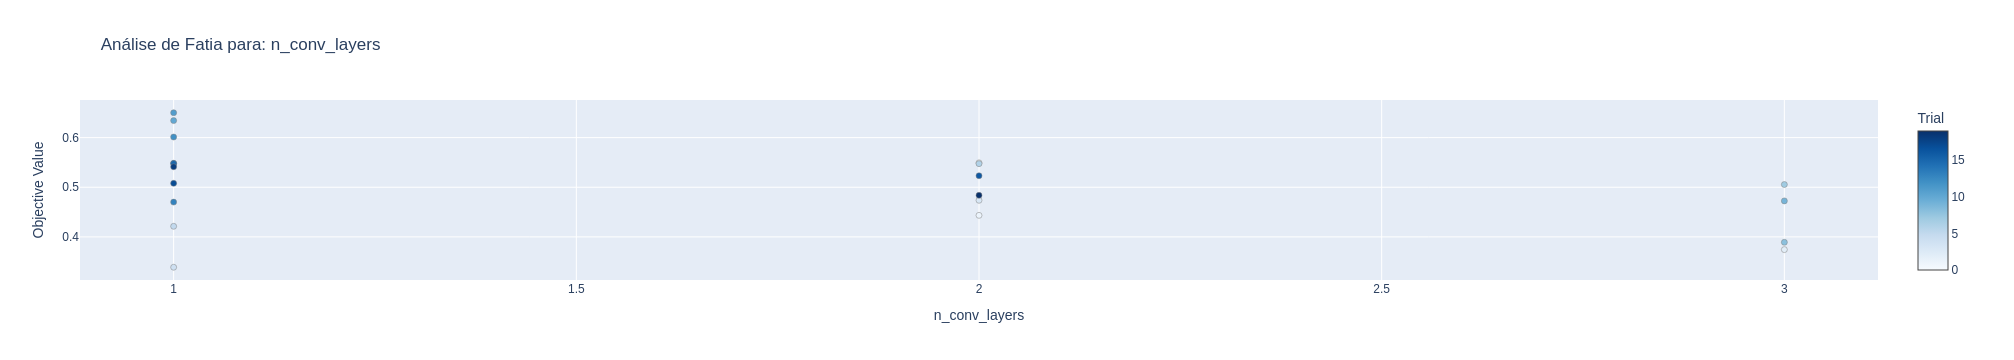

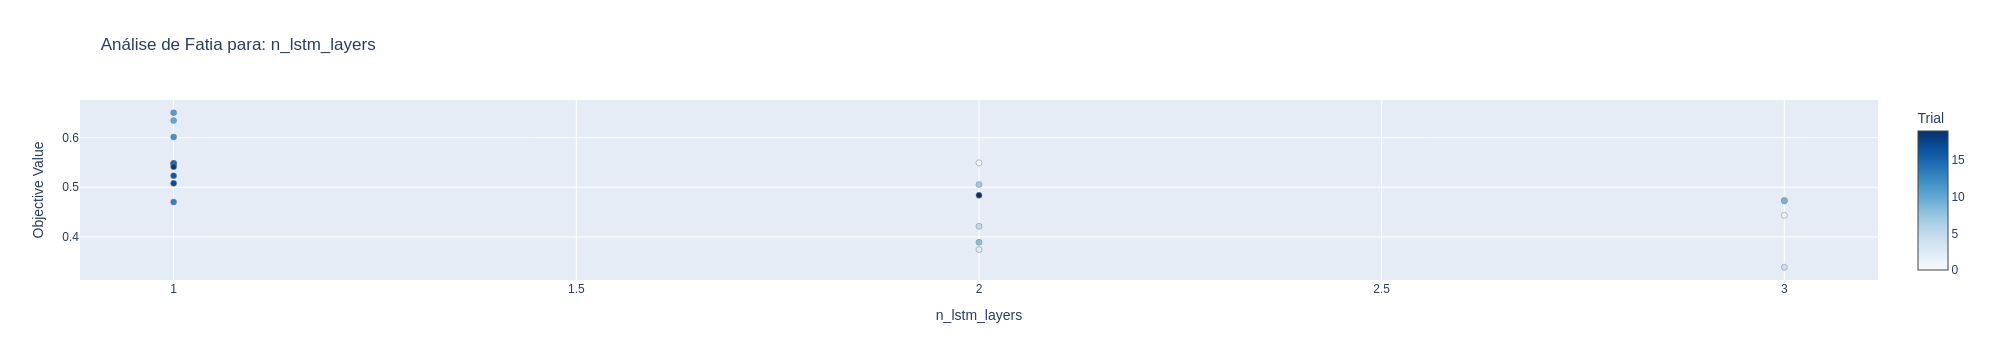

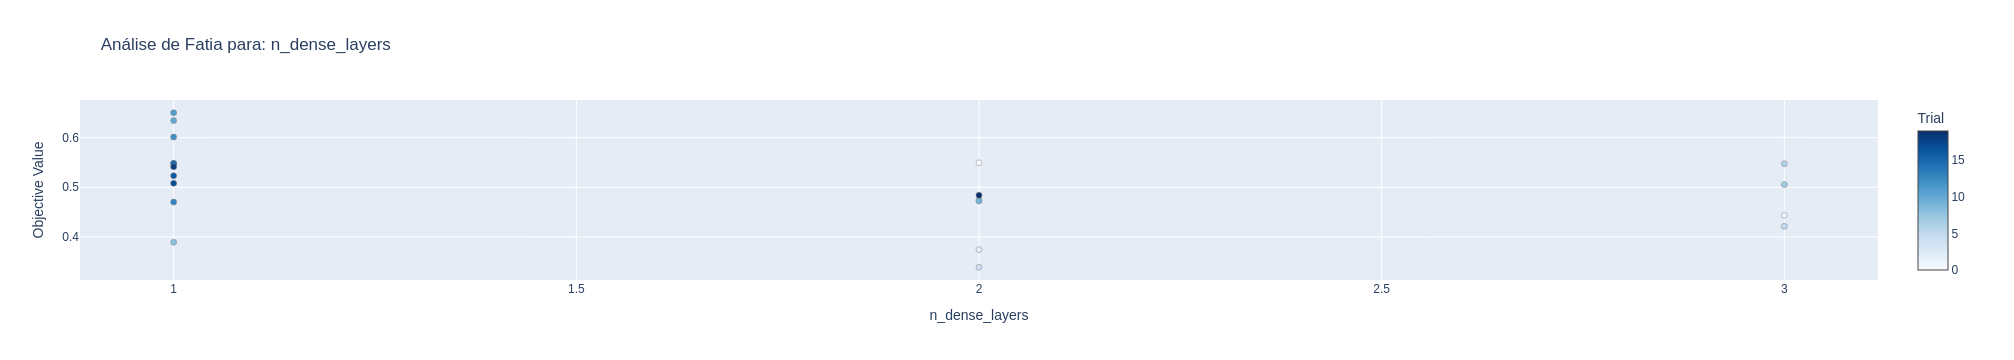

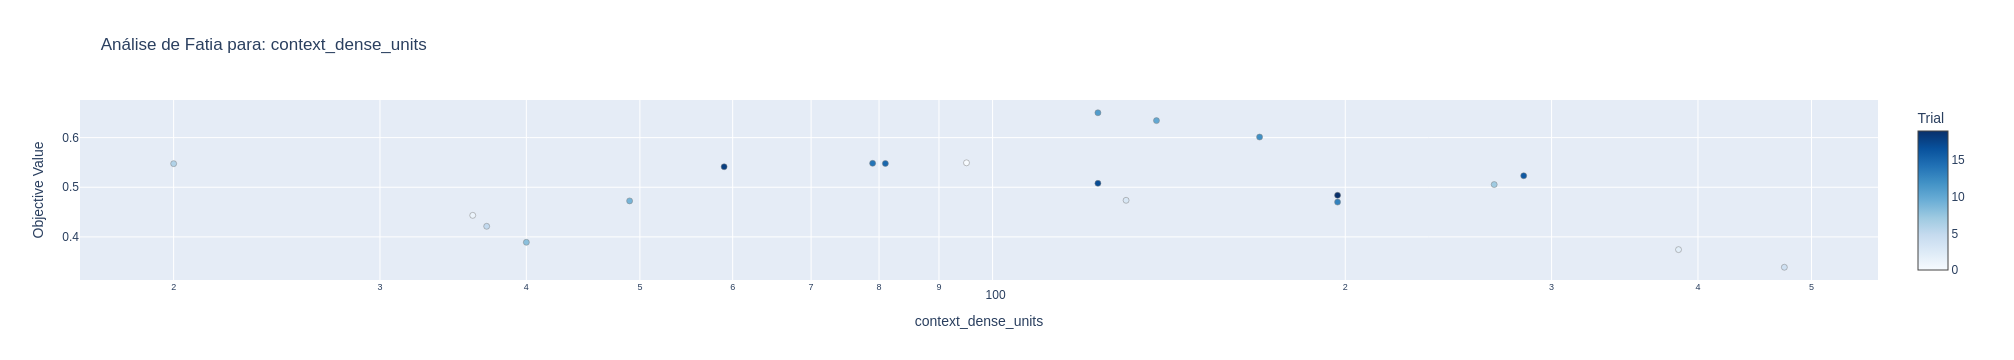

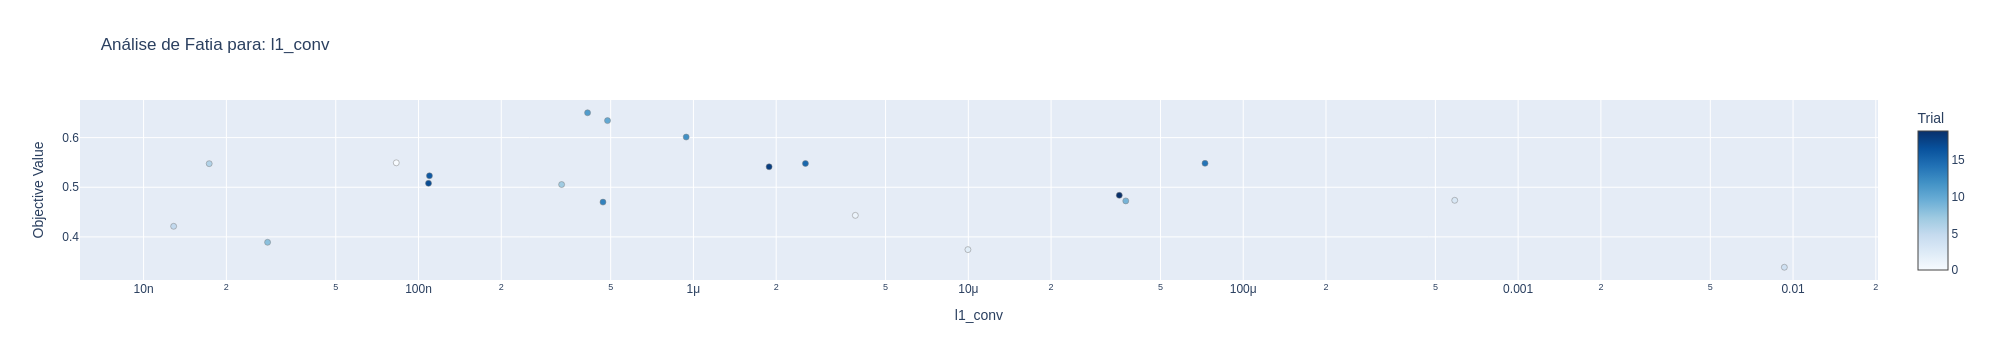

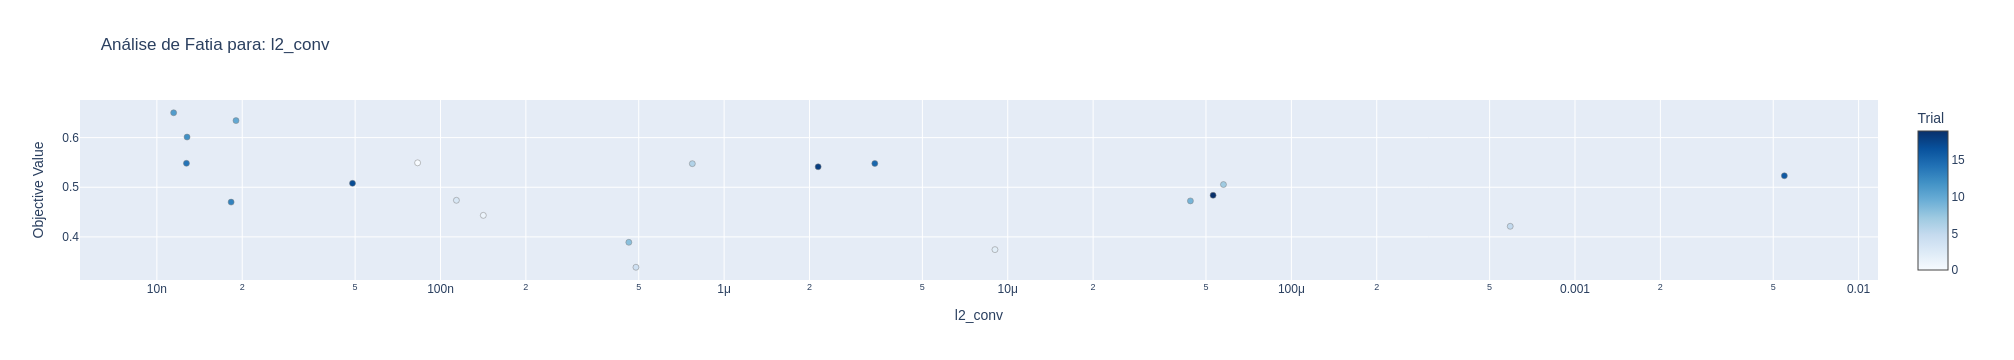

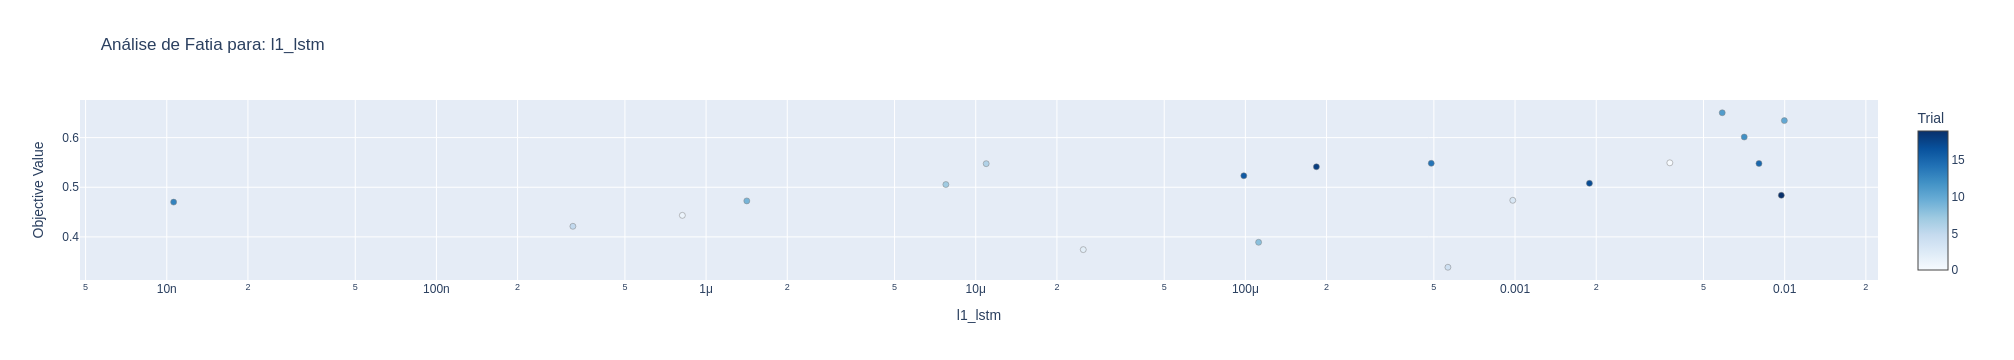

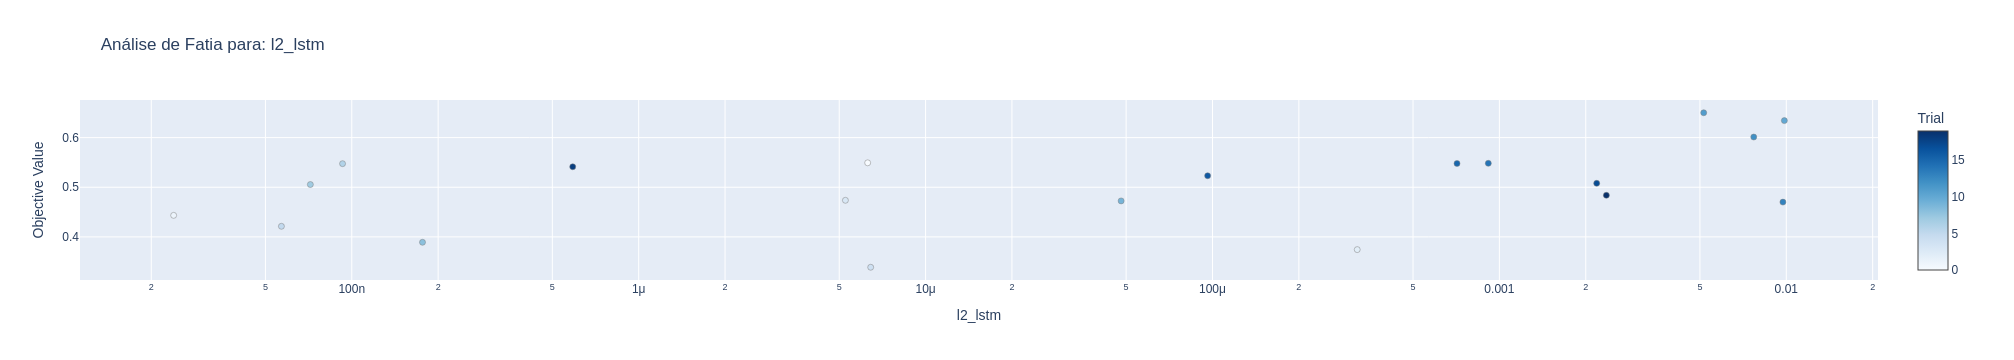

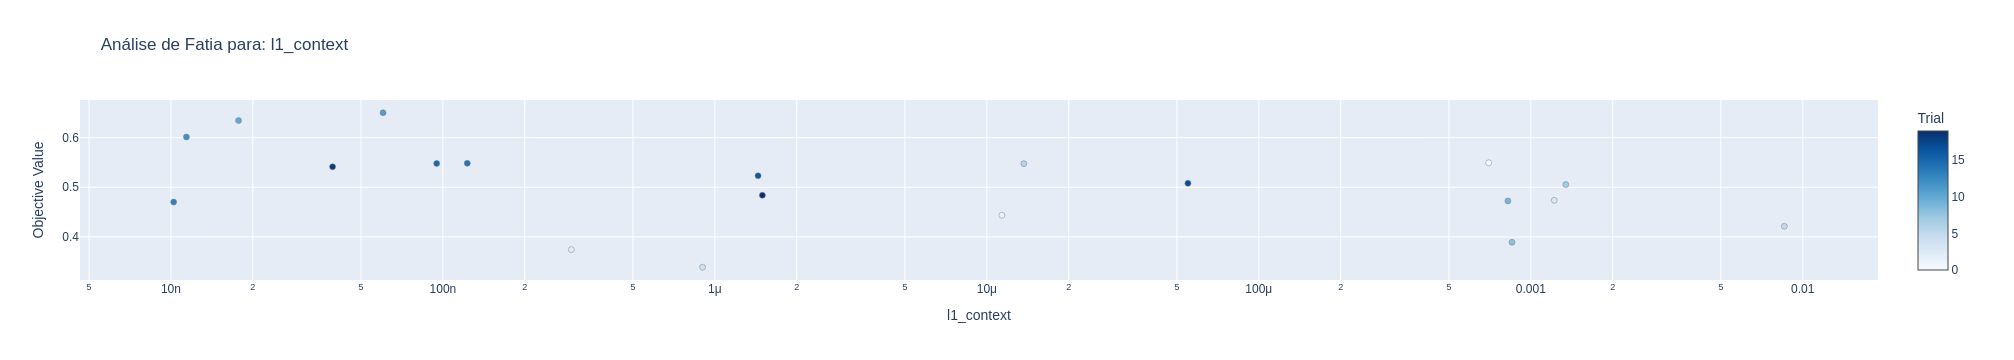

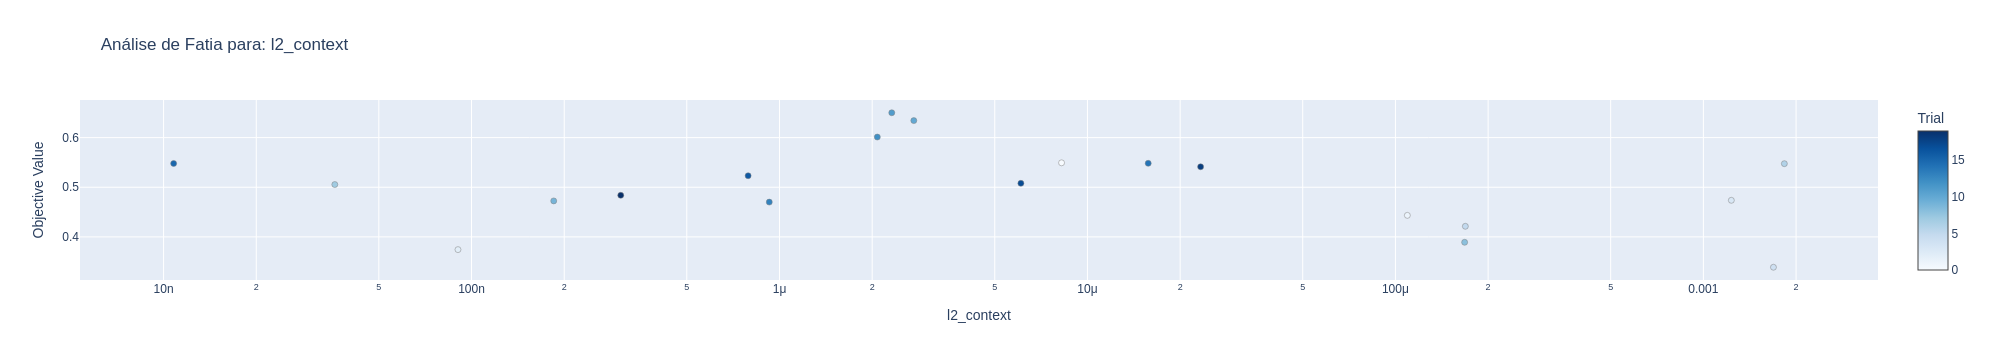

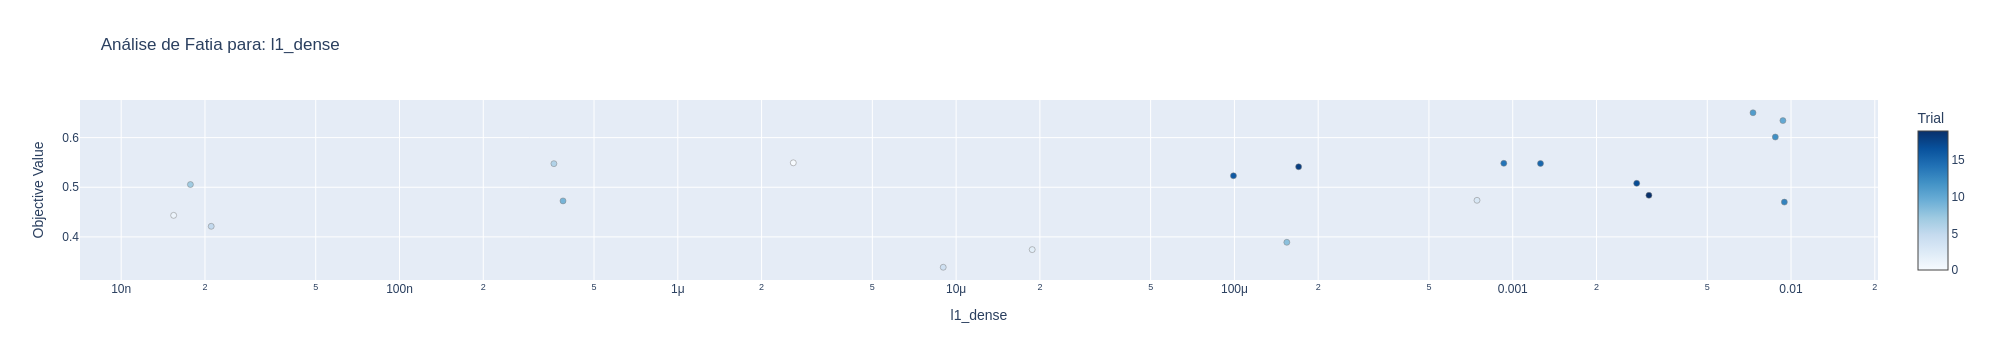

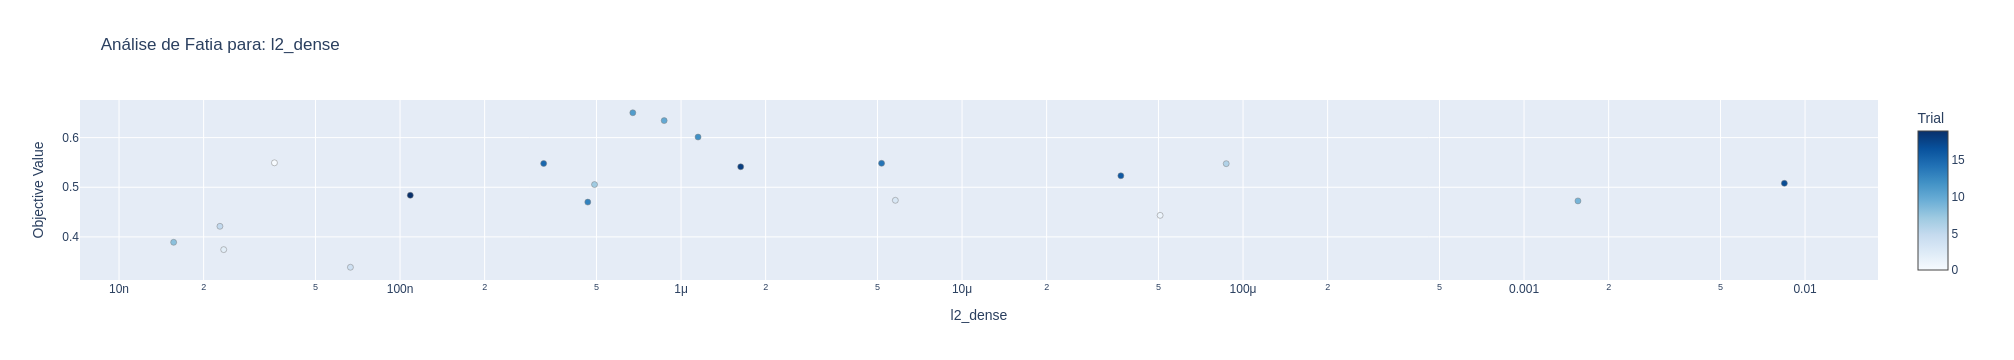

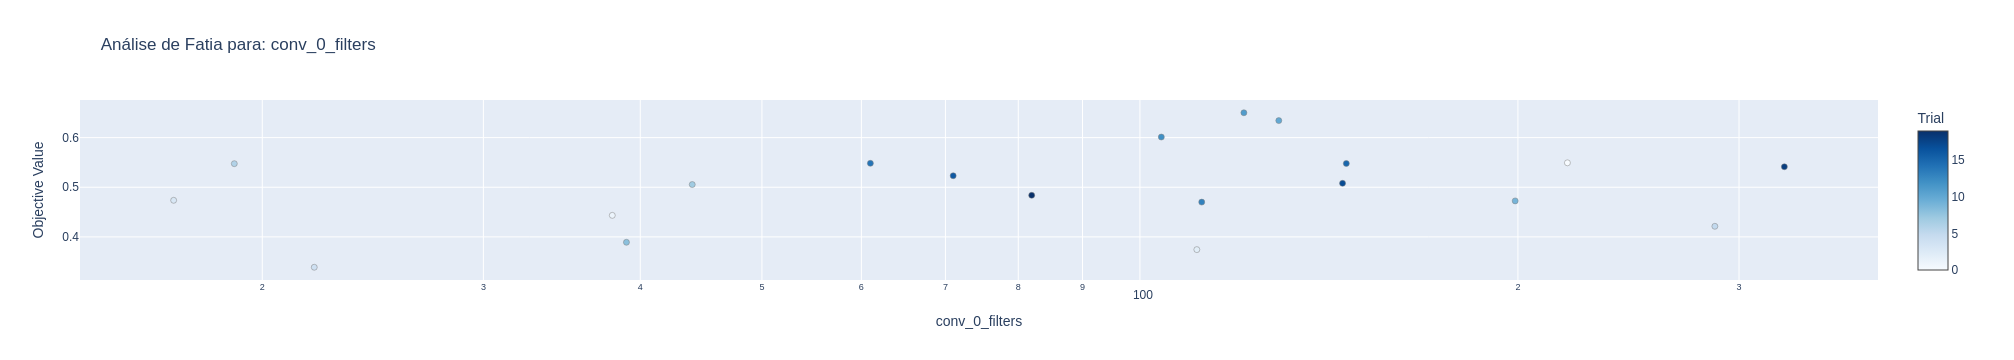

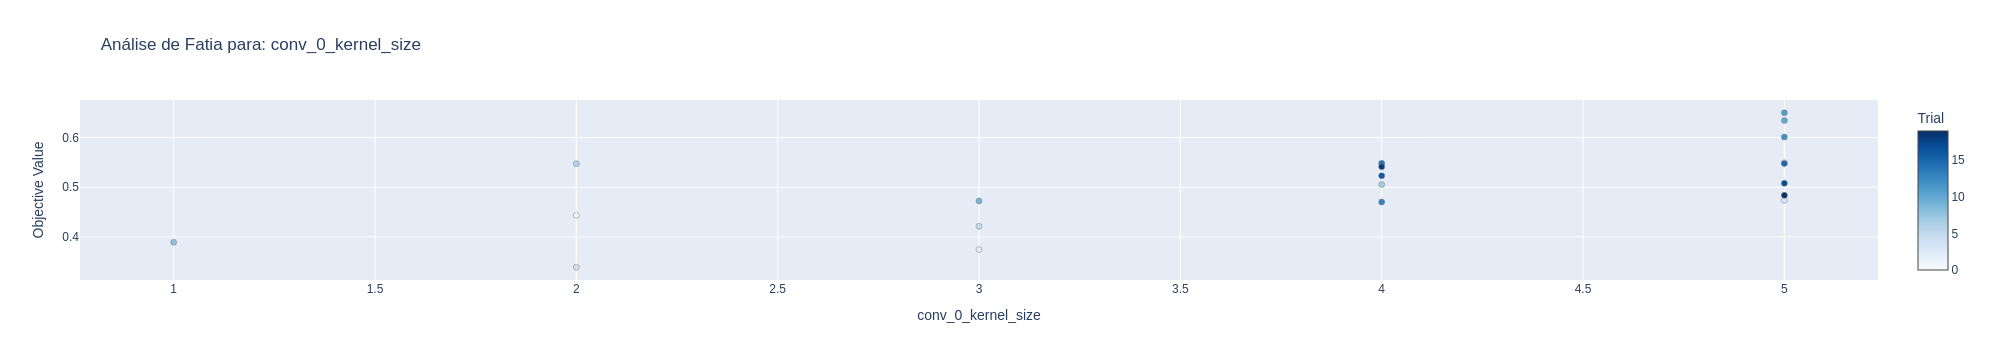

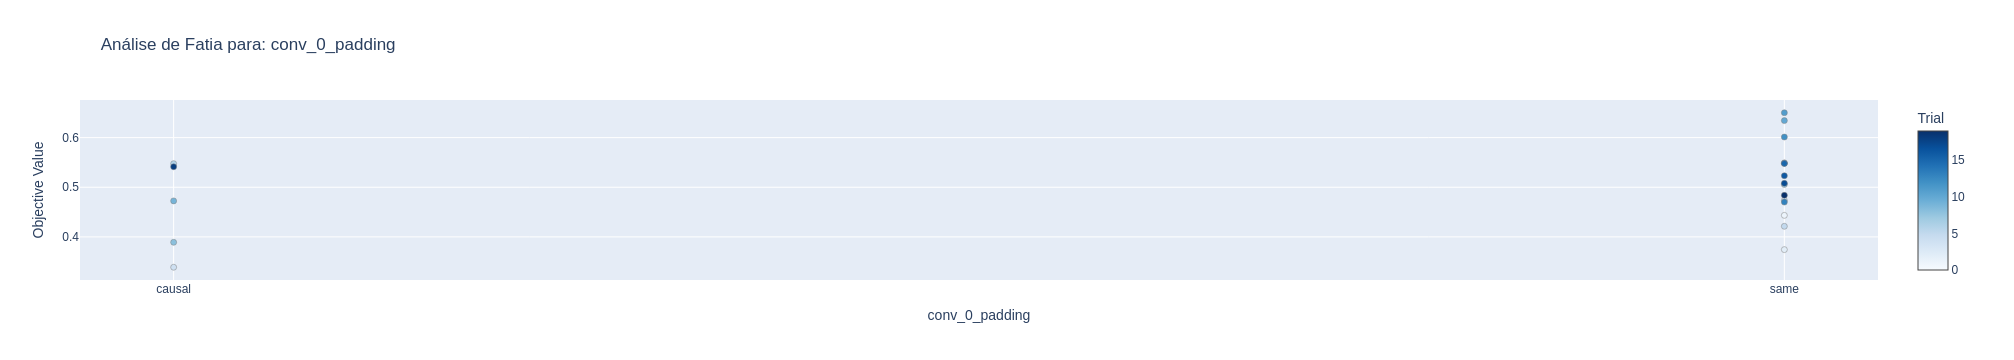

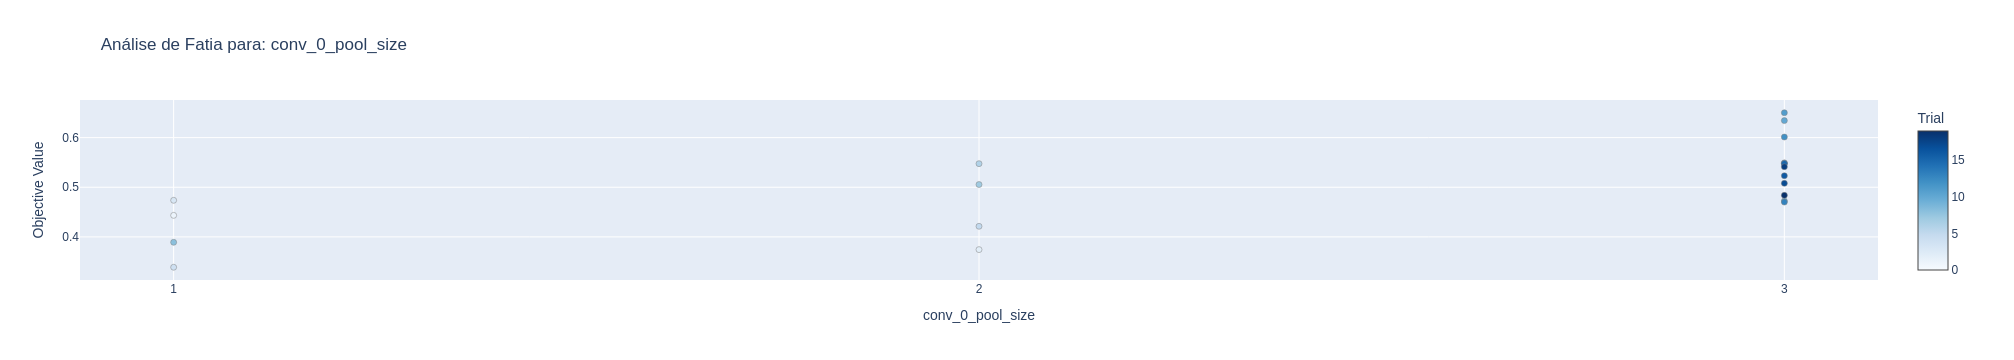

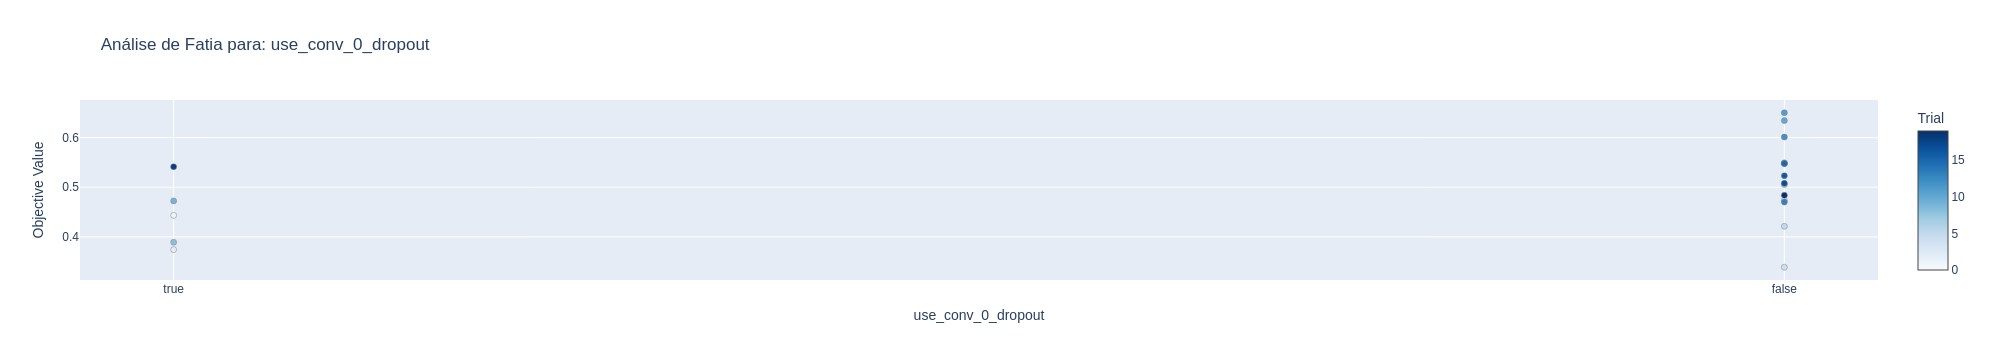

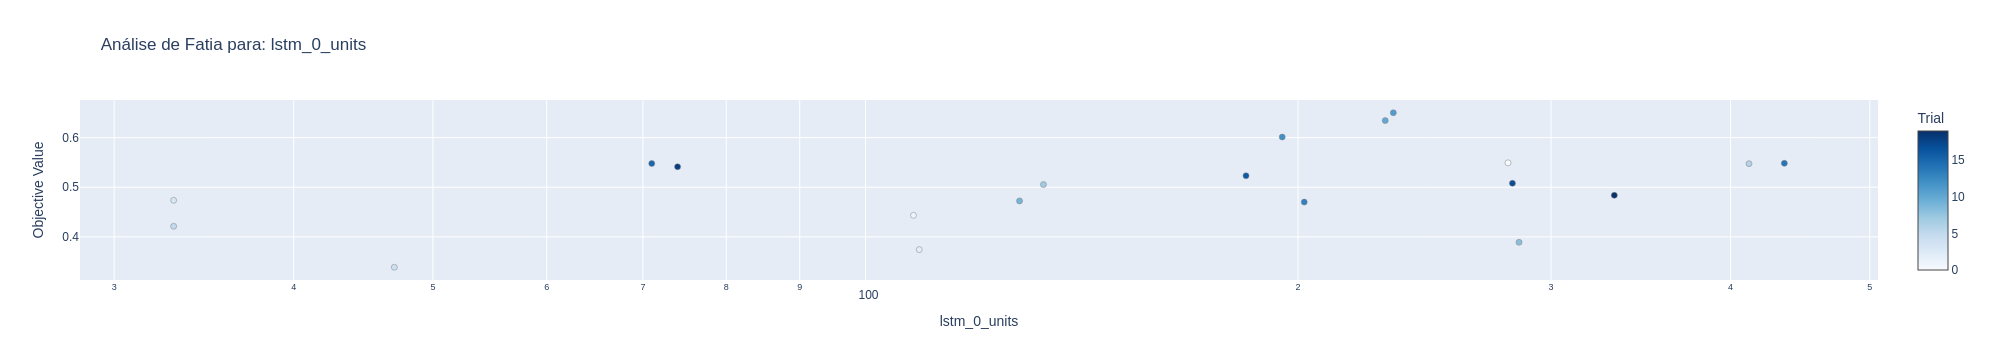

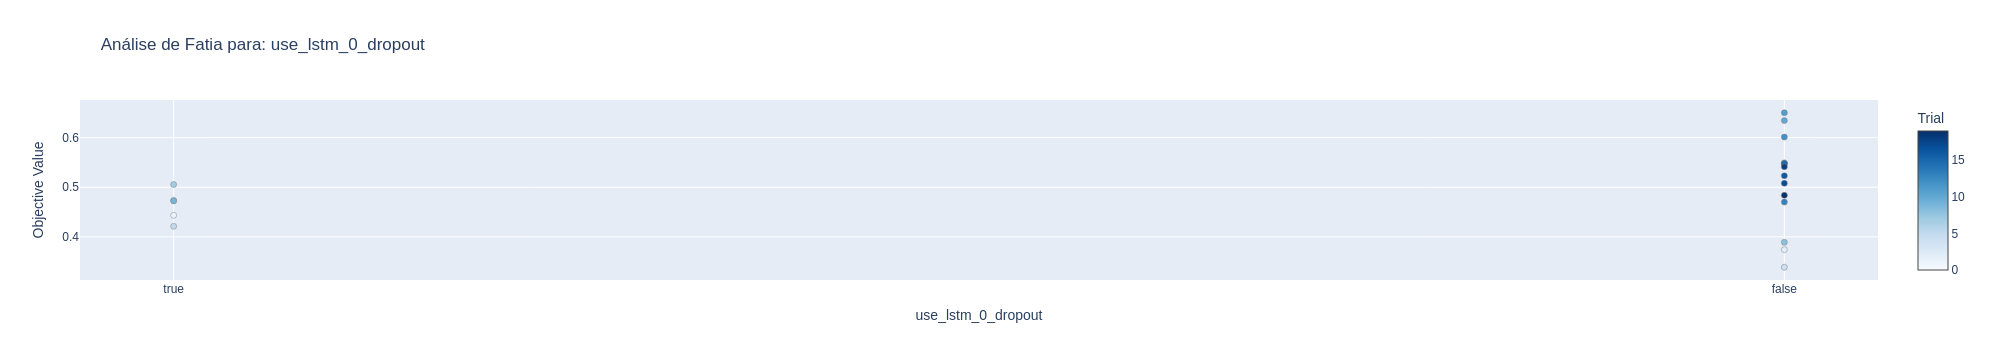

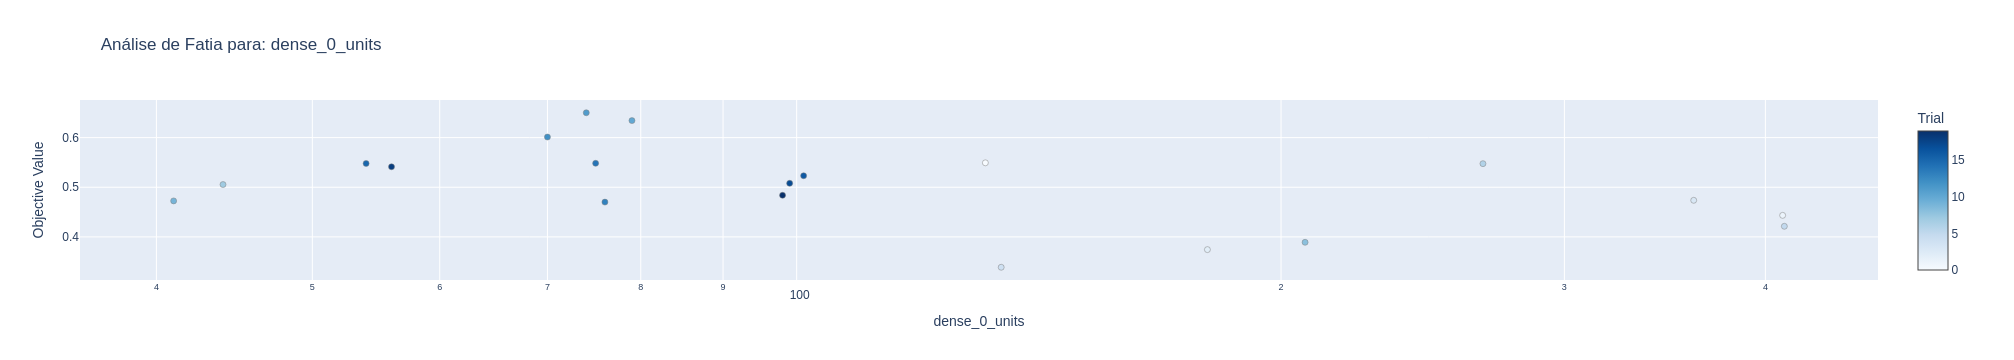

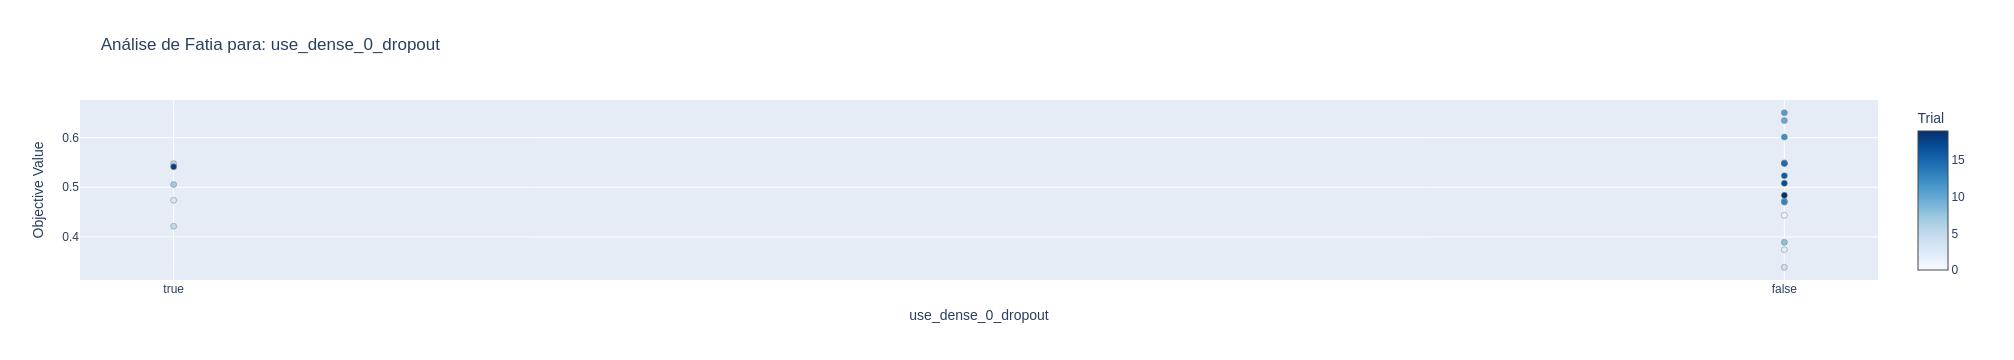

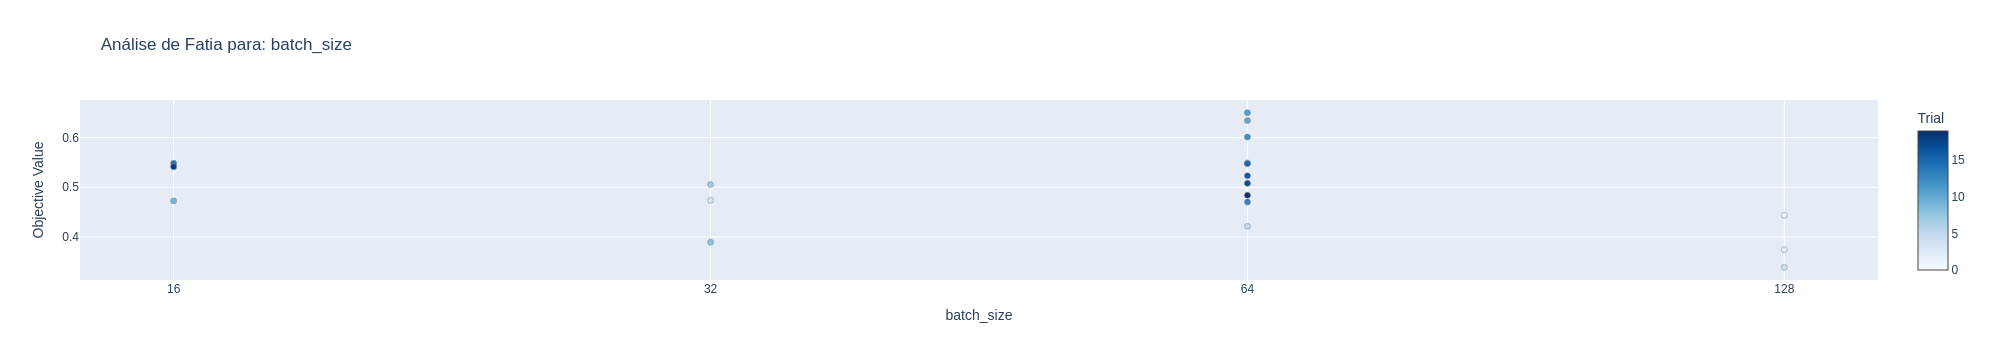


--- ETAPA 6: Treinando e avaliando o melhor modelo encontrado ---


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequencial    │ (None, 120, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 120, 121)  │      7,381 │ input_sequencial… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 121)  │        484 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_10    │ (None, 40, 121)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_10 (LSTM)      │ (None, 233)       │    330,860 │ max_pooling1d_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_contexto      │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 233)       │        932 │ lstm_10[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 123)       │      1,230 │ input_contexto[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 356)       │          0 │ batch_normalizat… │
│ (Concatenate)       │                   │            │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 74)        │     26,418 │ concatenate_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_binario      │ (None, 1)         │         75 │ dense_16[0][0]    │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 367,380 (1.40 MB)

 Trainable params: 366,672 (1.40 MB)

 Non-trainable params: 708 (2.77 KB)

Epoch 1/5000
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6104 - loss: 38.0814
Epoch 2/5000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8312 - loss: 36.4362
Epoch 3/5000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8571 - loss: 35.4469
Epoch 4/5000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9481 - loss: 34.5895
Epoch 5/5000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9221 - loss: 33.8914
Epoch 6/5000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9870 - loss: 33.1935
Epoch 7/5000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 32.5557
Epoch 8/5000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 31.9343
Epoch 9/5000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 31.3587
Epoch 10/5000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9740 - loss: 30.7813
Epoch 11/5000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 30.2156
Epoch 12/5000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step 

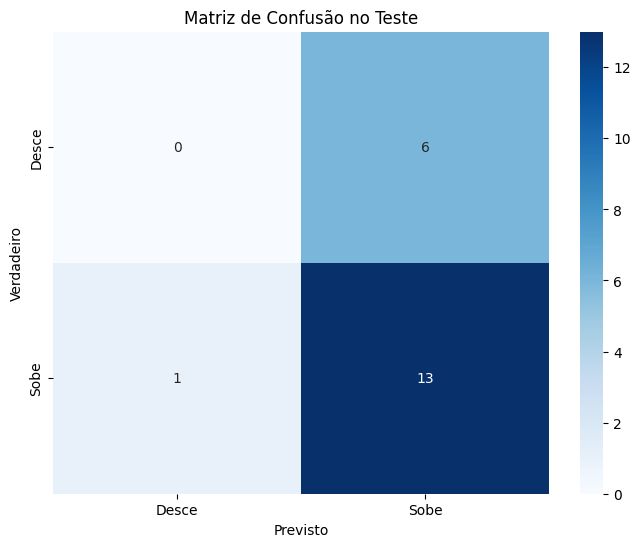

In [3]:
# =================================================================================
# OTIMIZAÇÃO DE CNN-LSTM PARA CLASSIFICAÇÃO BINÁRIA COM VALIDAÇÃO CRUZADA
# =================================================================================

# --- ETAPA 0: IMPORTAÇÕES ---
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import logging

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
logging.getLogger('tensorflow').setLevel(logging.ERROR)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization, concatenate
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
import re
from tensorflow.keras import regularizers
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_slice
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import train_test_split, TimeSeriesSplit

# --- ETAPA 1: CARREGAMENTO E PREPARAÇÃO DOS DADOS (ATUALIZADA) ---
print("--- ETAPA 1: Carregando e preparando os dados para Classificação Binária ---")
# ATUALIZAÇÃO: Carrega o novo dataset com o label binário.
NOME_ARQUIVO_DATASET = 'dataset_binario.csv'
NUM_TIMESTEPS = 120

try:
    df = pd.read_csv(NOME_ARQUIVO_DATASET, sep=';', index_col=0)
except FileNotFoundError:
    print(f"ERRO: Arquivo '{NOME_ARQUIVO_DATASET}' não foi encontrado.")
    exit()

# ATUALIZAÇÃO: O alvo (y) agora é a coluna 'label_binario', um vetor simples.
y = df['label_binario'].values
X_flat = df.drop(columns=['label_binario'])

# A separação das features (sequenciais e de contexto) permanece a mesma.
regex_sequencial = re.compile(r'_c\d+$')
context_feature_names = [col for col in X_flat.columns if not regex_sequencial.search(col)]
seq_feature_names = sorted(list(set([regex_sequencial.sub('', col) for col in X_flat.columns if regex_sequencial.search(col)])))
X_context = X_flat[context_feature_names].values
num_samples, num_seq_features = len(df), len(seq_feature_names)
X_seq = np.zeros((num_samples, NUM_TIMESTEPS, num_seq_features))
for i, feature_name in enumerate(seq_feature_names):
    cols = [f'{feature_name}_c{j}' for j in range(1, NUM_TIMESTEPS + 1)]
    X_seq[:, :, i] = X_flat[cols].values

print(f"Formato dos dados de Contexto (X_context): {X_context.shape}")
print(f"Formato dos dados Sequenciais (X_seq): {X_seq.shape}")

# ATUALIZAÇÃO: Divisão estritamente cronológica.
X_seq_train_val, X_seq_test, X_context_train_val, X_context_test, y_train_val, y_test = train_test_split(
    X_seq, X_context, y, test_size=0.2, shuffle=False
)
print("Divisão de dados concluída.")


# --- ETAPA 2: DEFINIÇÃO DA FUNÇÃO DE CRIAÇÃO DO MODELO (ATUALIZADA) ---
def create_binary_model(trial, input_shape_seq, input_shape_context):
    # A definição dos hiperparâmetros a serem otimizados permanece a mesma.
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop'])
    n_conv_layers = trial.suggest_int('n_conv_layers', 1, 3)
    n_lstm_layers = trial.suggest_int('n_lstm_layers', 1, 3)
    n_dense_layers = trial.suggest_int('n_dense_layers', 1, 3)
    context_dense_units = trial.suggest_int('context_dense_units', 16, 528, log=True)
   
    # Sorteia valores para as camadas convolucionais
    l1_conv = trial.suggest_float('l1_conv', 1e-8, 1e-2, log=True)
    l2_conv = trial.suggest_float('l2_conv', 1e-8, 1e-2, log=True)
    conv_regularizer = regularizers.l1_l2(l1=l1_conv, l2=l2_conv)
    
    # Sorteia valores para as camadas LSTM
    l1_lstm = trial.suggest_float('l1_lstm', 1e-8, 1e-2, log=True)
    l2_lstm = trial.suggest_float('l2_lstm', 1e-8, 1e-2, log=True)
    lstm_regularizer = regularizers.l1_l2(l1=l1_lstm, l2=l2_lstm)

    # Sorteia valores para a camada de contexto
    l1_context = trial.suggest_float('l1_context', 1e-8, 1e-2, log=True)
    l2_context = trial.suggest_float('l2_context', 1e-8, 1e-2, log=True)
    context_regularizer = regularizers.l1_l2(l1=l1_context, l2=l2_context)
    
    
    # Sorteia valores para as camadas densas
    l1_dense = trial.suggest_float('l1_dense', 1e-8, 1e-2, log=True)
    l2_dense = trial.suggest_float('l2_dense', 1e-8, 1e-2, log=True)
    dense_regularizer = regularizers.l1_l2(l1=l1_dense, l2=l2_dense)

    # A construção da arquitetura de múltiplas entradas é a mesma até a camada de saída.
    input_seq = Input(shape=input_shape_seq, name='input_sequencial')
    input_context = Input(shape=input_shape_context, name='input_contexto')
    
    current_seq = input_seq
    for i in range(n_conv_layers):
        filters = trial.suggest_int(f'conv_{i}_filters', 16, 328, log=True)
        kernel_size = trial.suggest_int(f'conv_{i}_kernel_size', 1, min(NUM_TIMESTEPS, 5))
        padding = trial.suggest_categorical(f'conv_{i}_padding', ['causal', 'same'])
        pool_size = trial.suggest_categorical(f'conv_{i}_pool_size', [1, 2, 3])
        
        current_seq = Conv1D(filters=filters, kernel_size=kernel_size, activation='relu', padding=padding, kernel_regularizer=conv_regularizer)(current_seq)
        current_seq = BatchNormalization()(current_seq)
        if trial.suggest_categorical(f'use_conv_{i}_dropout', [True, False]):
            rate = trial.suggest_float(f'conv_{i}_dropout_rate', 0.1, 0.7)
            current_seq = Dropout(rate=rate)(current_seq)
        if current_seq.shape[1] > pool_size and pool_size > 1:
             current_seq = MaxPooling1D(pool_size=pool_size)(current_seq)
    
    for i in range(n_lstm_layers):
        units = trial.suggest_int(f'lstm_{i}_units', 32, 456, log=True)
        return_sequences = (i < n_lstm_layers - 1)
        current_seq = LSTM(units=units, return_sequences=return_sequences, kernel_regularizer=lstm_regularizer)(current_seq)
        current_seq = BatchNormalization()(current_seq)
        if trial.suggest_categorical(f'use_lstm_{i}_dropout', [True, False]):
            rate = trial.suggest_float(f'lstm_{i}_dropout_rate', 0.1, 0.7)
            current_seq = Dropout(rate=rate)(current_seq)

    x_context = Dense(units=context_dense_units, activation='relu', kernel_regularizer=context_regularizer)(input_context)
    x = concatenate([current_seq, x_context])
    
    for i in range(n_dense_layers):
        units = trial.suggest_int(f'dense_{i}_units', 32, 456, log=True)
        x = Dense(units=units, activation='relu', kernel_regularizer=dense_regularizer)(x)
        if trial.suggest_categorical(f'use_dense_{i}_dropout', [True, False]):
            rate = trial.suggest_float(f'dense_{i}_dropout_rate', 0.1, 0.7)
            x = Dropout(rate=rate)(x)
            
    # ATUALIZAÇÃO: Camada de saída para classificação binária.
    # 1 neurônio com ativação 'sigmoid'.
    output = Dense(1, activation='sigmoid', name='output_binario')(x)
    
    model = Model(inputs=[input_seq, input_context], outputs=output)
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate) if optimizer_name == 'Adam' else tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    
    # ATUALIZAÇÃO: Compilação para classificação binária.
    # A função de perda é 'binary_crossentropy'.
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# --- ETAPA 3: DEFINIÇÃO DA FUNÇÃO OBJECTIVE COM VALIDAÇÃO CRUZADA (ATUALIZADA) ---
print("\n--- ETAPA 3: Definindo a função objective para Classificação Binária ---")
def objective(trial):
    tf.keras.backend.clear_session()
    f1_scores = []
    tscv = TimeSeriesSplit(n_splits=5)
    
    for train_index, val_index in tscv.split(X_seq_train_val):
        X_seq_train_fold, X_seq_val_fold = X_seq_train_val[train_index], X_seq_train_val[val_index]
        X_context_train_fold, X_context_val_fold = X_context_train_val[train_index], X_context_train_val[val_index]
        y_train_fold, y_val_fold = y_train_val[train_index], y_train_val[val_index]
        
        scaler_seq = StandardScaler()
        scaler_seq.fit(X_seq_train_fold.reshape(-1, X_seq_train_fold.shape[-1]))
        scaler_context = StandardScaler()
        scaler_context.fit(X_context_train_fold)
        
        def scale_seq_data(data, scaler):
            return scaler.transform(data.reshape(-1, data.shape[-1])).reshape(data.shape)
            
        X_seq_train_fold_s = scale_seq_data(X_seq_train_fold, scaler_seq)
        X_seq_val_fold_s = scale_seq_data(X_seq_val_fold, scaler_seq)
        X_context_train_fold_s = scaler_context.transform(X_context_train_fold)
        X_context_val_fold_s = scaler_context.transform(X_context_val_fold)
        
        model = create_binary_model(trial, X_seq_train_fold_s.shape[1:], X_context_train_fold_s.shape[1:])
        batch_size = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
        
        model.fit(
            [X_seq_train_fold_s, X_context_train_fold_s], y_train_fold,
            validation_data=([X_seq_val_fold_s, X_context_val_fold_s], y_val_fold),
            epochs=5000,
            batch_size=batch_size,
            callbacks=[EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)],
            verbose=0
        )
        
        # Substitui a acurácia pelo F1-Score.
        
        # 1. Faz a previsão, que retorna probabilidades
        y_pred_probs = model.predict([X_seq_val_fold_s, X_context_val_fold_s])
        
        # 2. Converte as probabilidades para classes (0 ou 1)
        y_pred_classes = (y_pred_probs > 0.5).astype("int32")
        
        # 3. y_val_fold já está no formato correto (0s e 1s)
        y_true_classes = y_val_fold
        
        # 4. Calcula o F1-Score e o armazena.
        score = f1_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
        f1_scores.append(score)
        
    # ATUALIZAÇÃO: Retorna a média dos F1-Scores para o Optuna
    return np.mean(f1_scores)

# --- ETAPA 4: EXECUÇÃO DA OTIMIZAÇÃO ---
print("\n--- ETAPA 4: Executando a otimização com Optuna ---")
study = optuna.create_study(direction='maximize')
########################################
study.optimize(objective, n_trials=20)

# --- ETAPA 5: VISUALIZAÇÃO DOS RESULTADOS DA OTIMIZAÇÃO ---
print("\n--- ETAPA 5: Gerando gráficos de análise da otimização ---")
if not study.trials:
    print("AVISO: O estudo não possui trials concluídos.")
else:
    best_trial = study.best_trial
    print(f"Melhor Acurácia Média na Validação Cruzada: {best_trial.value:.4f}")
    print("Melhores Hiperparâmetros:", best_trial.params)
    plot_optimization_history(study).show()
    plot_param_importances(study).show()
    all_params = list(study.best_trial.params.keys())
    for param_name in all_params:
        fig_slice = plot_slice(study, params=[param_name])
        fig_slice.update_layout(title_text=f"Análise de Fatia para: {param_name}")
        fig_slice.show()

# --- ETAPA 6: TREINAMENTO E AVALIAÇÃO DO MELHOR MODELO (ATUALIZADA) ---
print("\n--- ETAPA 6: Treinando e avaliando o melhor modelo encontrado ---")
scaler_seq_final = StandardScaler()
scaler_seq_final.fit(X_seq_train_val.reshape(-1, X_seq_train_val.shape[-1]))
scaler_context_final = StandardScaler()
scaler_context_final.fit(X_context_train_val)
def scale_seq_data_final(data, scaler):
    return scaler.transform(data.reshape(-1, data.shape[-1])).reshape(data.shape)
X_seq_train_val_s = scale_seq_data_final(X_seq_train_val, scaler_seq_final)
X_context_train_val_s = scaler_context_final.transform(X_context_train_val)
X_seq_test_s = scale_seq_data_final(X_seq_test, scaler_seq_final)
X_context_test_s = scaler_context_final.transform(X_context_test)

final_model = create_binary_model(best_trial, X_seq_train_val_s.shape[1:], X_context_train_val_s.shape[1:])
final_model.summary()
history = final_model.fit(
    [X_seq_train_val_s, X_context_train_val_s], y_train_val,
    epochs=5000,
    batch_size=best_trial.params['batch_size'],
    callbacks=[EarlyStopping(monitor='loss', patience=100, restore_best_weights=True)],
    verbose=1
)

# --- ETAPA 7: AVALIAÇÃO FINAL NO CONJUNTO DE TESTE (ATUALIZADA) ---
print("\n--- ETAPA 7: Avaliação Final no Conjunto de Teste ---")
test_loss, test_accuracy = final_model.evaluate([X_seq_test_s, X_context_test_s], y_test)
print(f"Acurácia no Teste: {test_accuracy:.4f}")

# ATUALIZAÇÃO: Lógica de previsão para classificação binária.
# A saída do modelo é uma probabilidade. Arredondamos para obter a classe (0 ou 1).
y_pred_probs = final_model.predict([X_seq_test_s, X_context_test_s])
y_pred = (y_pred_probs > 0.5).astype("int32")
y_true = y_test # y_true já está no formato correto (0s e 1s).

print("\nRelatório de Classificação:")
# ATUALIZAÇÃO: Nomes das classes para o relatório.
class_names = ['Desce', 'Sobe']
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
print("\nMatriz de Confusão:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsto'); plt.ylabel('Verdadeiro'); plt.title('Matriz de Confusão no Teste'); plt.show()
